-------------------------------------------------------------
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 4 : classifiez automatiquement des informations
-------------------------------------------------------------

## Etape préalable

In [116]:
# Contrôle présence venv uv 
import sys
print(sys.executable)

/mnt/projects/ai_engineer_projects/P04/.venv/bin/python3


In [117]:
# Contrôle version python
sys.version

'3.11.15 (main, Mar 10 2026, 18:16:52) [Clang 21.1.4 ]'

In [118]:
# Contrôle présence des bibliothèques installées dans le venv uv
import importlib.metadata as md

packages = [
    "imbalanced-learn", "ipykernel", "jupyterlab",
    "matplotlib", "missingno", "numpy", "pandas", 
    "plotly", "psycopg2-binary", "pyarrow" , "scikit-learn",
    "scipy", "seaborn", "shap", "sqlalchemy", "statsmodels"
]

for p in packages:
    try:
        print(p, md.version(p))
    except:
        print(p, "missing")

imbalanced-learn 0.14.1
ipykernel 7.2.0
jupyterlab 4.5.6
matplotlib 3.10.8
missingno 0.5.2
numpy 2.4.3
pandas 3.0.1
plotly 6.6.0
psycopg2-binary 2.9.11
pyarrow 23.0.1
scikit-learn 1.8.0
scipy 1.17.1
seaborn 0.13.2
shap 0.51.0
sqlalchemy 2.0.48
statsmodels 0.14.6


## Etape 1 : Effectuer une analyse exploratoire des fichiers de données

### Etape 1-1 : EDA du dataframe df_sirh avant jointure

In [119]:
# Chargement en dataframes pandas des 3 fichiers sources sirh, évaluation et sondage  
import pandas as pd

In [120]:
df_sirh = pd.read_csv("../data/raw/extrait_sirh.csv")

In [121]:
df_sirh.head(3)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


In [122]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 191.1 KB


In [123]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sirh.rename(columns={
    "id_employee": "id_salarie",
    "nombre_heures_travailless": "nombre_heures_travaillees",
    "annee_experience_totale" : "nombre_total_annees_experience",
    "annees_dans_l_entreprise" : "nombre_total_annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel" : "nombre_total_annees_dans_le_poste_actuel"  
}, inplace=True)

In [124]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [125]:
# identification des colonnes numériques
int_cols_sirh = df_sirh.select_dtypes(include="int64").columns
print(int_cols_sirh)

Index(['id_salarie', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travaillees', 'nombre_total_annees_experience',
       'nombre_total_annees_dans_l_entreprise',
       'nombre_total_annees_dans_le_poste_actuel'],
      dtype='str')


In [126]:
# Vérification absence de decimales sur les valeurs au format int64
for col in int_cols_sirh:
    a_decimales = (df_sirh[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

id_salarie a décimales ? False
age a décimales ? False
revenu_mensuel a décimales ? False
nombre_experiences_precedentes a décimales ? False
nombre_heures_travaillees a décimales ? False
nombre_total_annees_experience a décimales ? False
nombre_total_annees_dans_l_entreprise a décimales ? False
nombre_total_annees_dans_le_poste_actuel a décimales ? False


In [127]:
# Identification des colonnes type chaînes de caractères
string_cols_sirh = df_sirh.select_dtypes(include="str").columns
print(string_cols_sirh)

Index(['genre', 'statut_marital', 'departement', 'poste'], dtype='str')


In [128]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
<ArrowStringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
<ArrowStringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str


In [129]:
# Retirer les majuscules, espaces, accents et parenthèses
import unicodedata

df_sirh[string_cols_sirh] = df_sirh[string_cols_sirh].apply(
    lambda string_cols_sirh: string_cols_sirh.astype(str)
    .str.lower()
    .str.replace(r"[()]", "", regex=True)  
    .str.replace(" ", "_")
    .str.strip("_") 
    .map(lambda x: unicodedata.normalize("NFKD", x)
         .encode("ascii", errors="ignore")
         .decode("utf-8"))
)

In [130]:
# Réafficher les colonnes types chaînes de caractères mises en forme
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['f', 'm']
Length: 2, dtype: str
<ArrowStringArray>
['celibataire', 'mariee', 'divorcee']
Length: 3, dtype: str
<ArrowStringArray>
['commercial', 'consulting', 'ressources_humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'cadre_commercial',  'assistant_de_direction',
              'consultant',               'tech_lead',
                 'manager',          'senior_manager',
 'representant_commercial',     'directeur_technique',
     'ressources_humaines']
Length: 9, dtype: str


In [131]:
# Recherche de valeurs manquantes 
df_sirh.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

id_salarie                                  0
age                                         0
genre                                       0
revenu_mensuel                              0
statut_marital                              0
departement                                 0
poste                                       0
nombre_experiences_precedentes              0
nombre_heures_travaillees                   0
nombre_total_annees_experience              0
nombre_total_annees_dans_l_entreprise       0
nombre_total_annees_dans_le_poste_actuel    0
dtype: int64

In [132]:
# Contrôle présence de doublons sur la colonne id_salarie
df_sirh["id_salarie"].duplicated().any()

np.False_

In [133]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [134]:
# Statistiques descriptives du dataframe df_sirh
df_sirh.describe().T

,count,mean,std,min,25%,50%,75%,max
id_salarie,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travaillees,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0


#### premiere analyse des statistiques descriptives
* anomalies du nombre d'heures travaillées car tous les salariés sont à 80h soit plus de deux fois 35h => cette colonne est peu informative et pourra donc être ignorée
*  la moyenne d'âge des salariés est de 36 ans
*  la distribution des âges des salariés est équilibrée car moyenne = médiane
*  le nombre d'années moyen passées dans l'entreprise est autour de **7 ans**

In [135]:
# suppression de la colonne nombre d'heures travaillées
df_sirh.drop(columns=["nombre_heures_travaillees"], inplace=True)

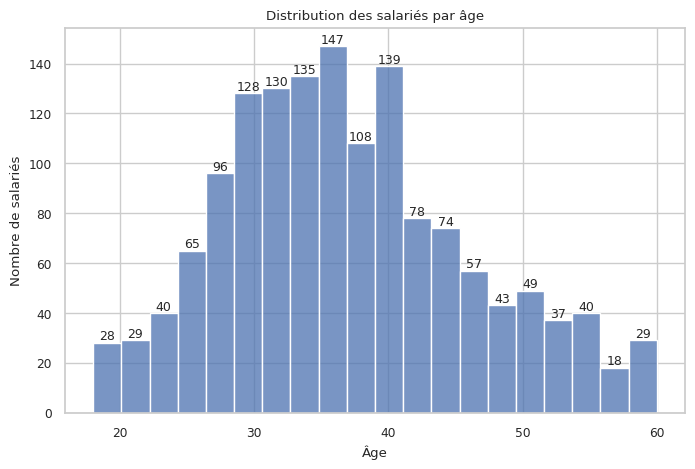

In [136]:
# distribution des âges des salariés

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["age"], bins=20)

plt.title("Distribution des salariés par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

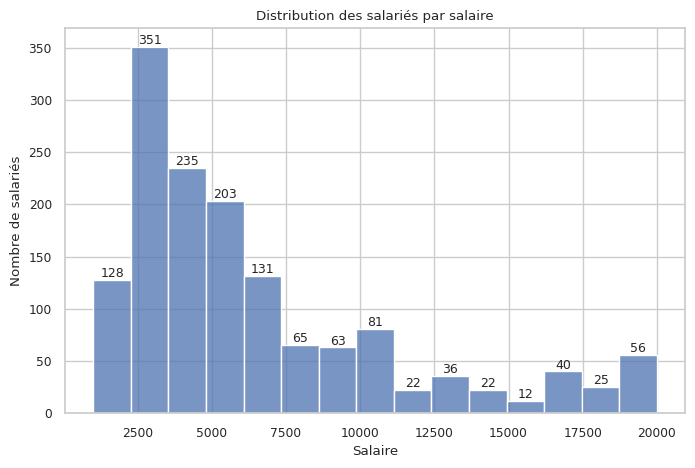

In [137]:
# distribution des revenus mensuels
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["revenu_mensuel"], bins=15)

plt.title("Distribution des salariés par salaire")
plt.xlabel("Salaire")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

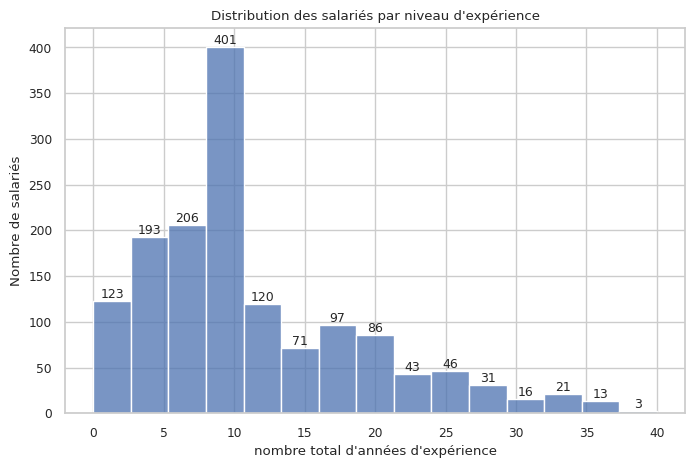

In [138]:
#  Distribution du nombre total d'annees d'experience 
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_experience"], bins=15)

plt.title("Distribution des salariés par niveau d'expérience")
plt.xlabel("nombre total d'années d'expérience")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

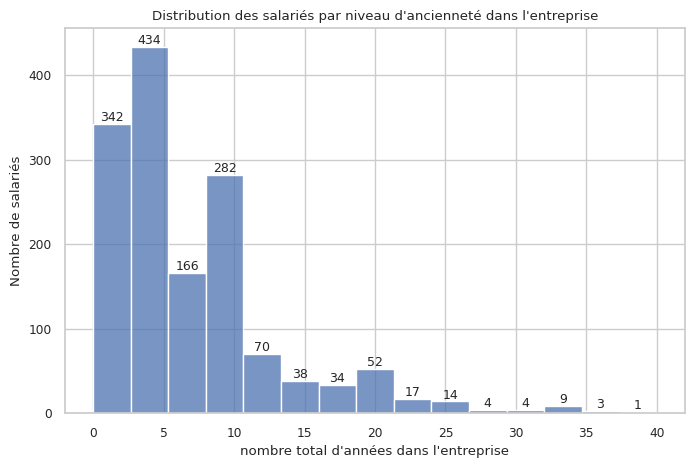

In [139]:
# Distribution du niveau d'ancienneté dans l'entreprise
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_dans_l_entreprise"], bins=15)

plt.title("Distribution des salariés par niveau d'ancienneté dans l'entreprise")
plt.xlabel("nombre total d'années dans l'entreprise")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

#### observations
* le salaire médian de 4 900 € représente le cœur de la population salariale
* la majorité des salariés quittent avant 10 ans
* peu de salariés atteignent donc les niveaux d’ancienneté élevés
* cela peut limiter la progression salariale globale et **potentiellement influencer le turnover**

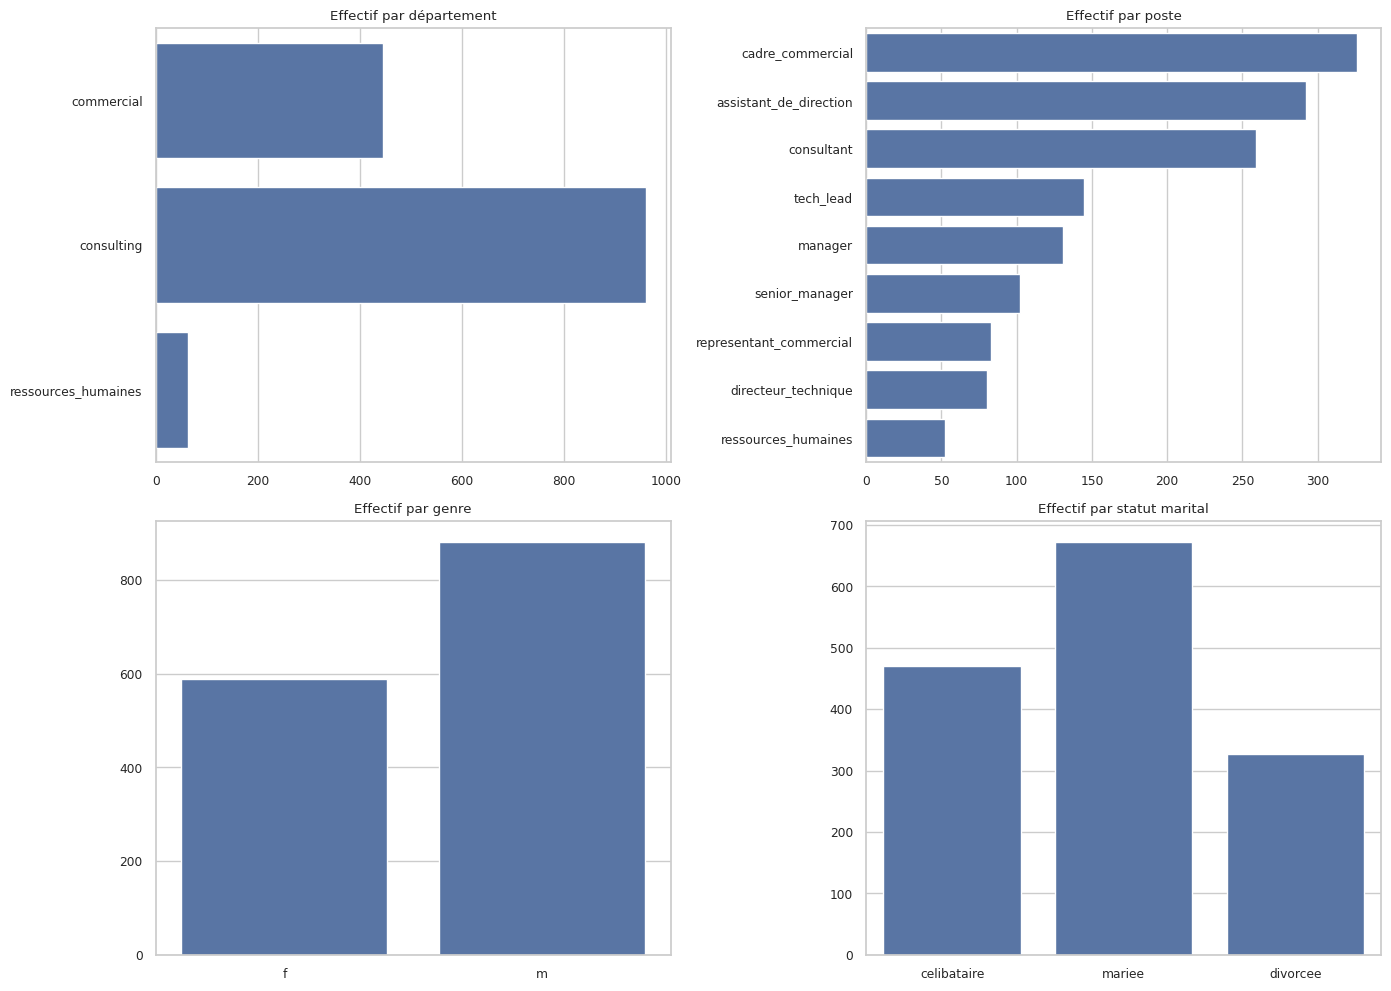

In [140]:
# Distribution par département, poste, genre et statut marital

import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    ("departement", "Effectif par département", "y"),
    ("poste", "Effectif par poste", "y"),
    ("genre", "Effectif par genre", "x"),
    ("statut_marital", "Effectif par statut marital", "x")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title, orient) in enumerate(cols):
    
    if orient == "y":
        sns.countplot(y=df_sirh[col], ax=axes[i])
    else:
        sns.countplot(x=df_sirh[col], ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

#### observations
* les postes de cadre commercial, assistant de direction et de consultant sont les plus représentés
* il n'y a pas de déséquilibre profond entre hommes et femmes bien que ces dernières soient à 25% moins représentées que les hommes

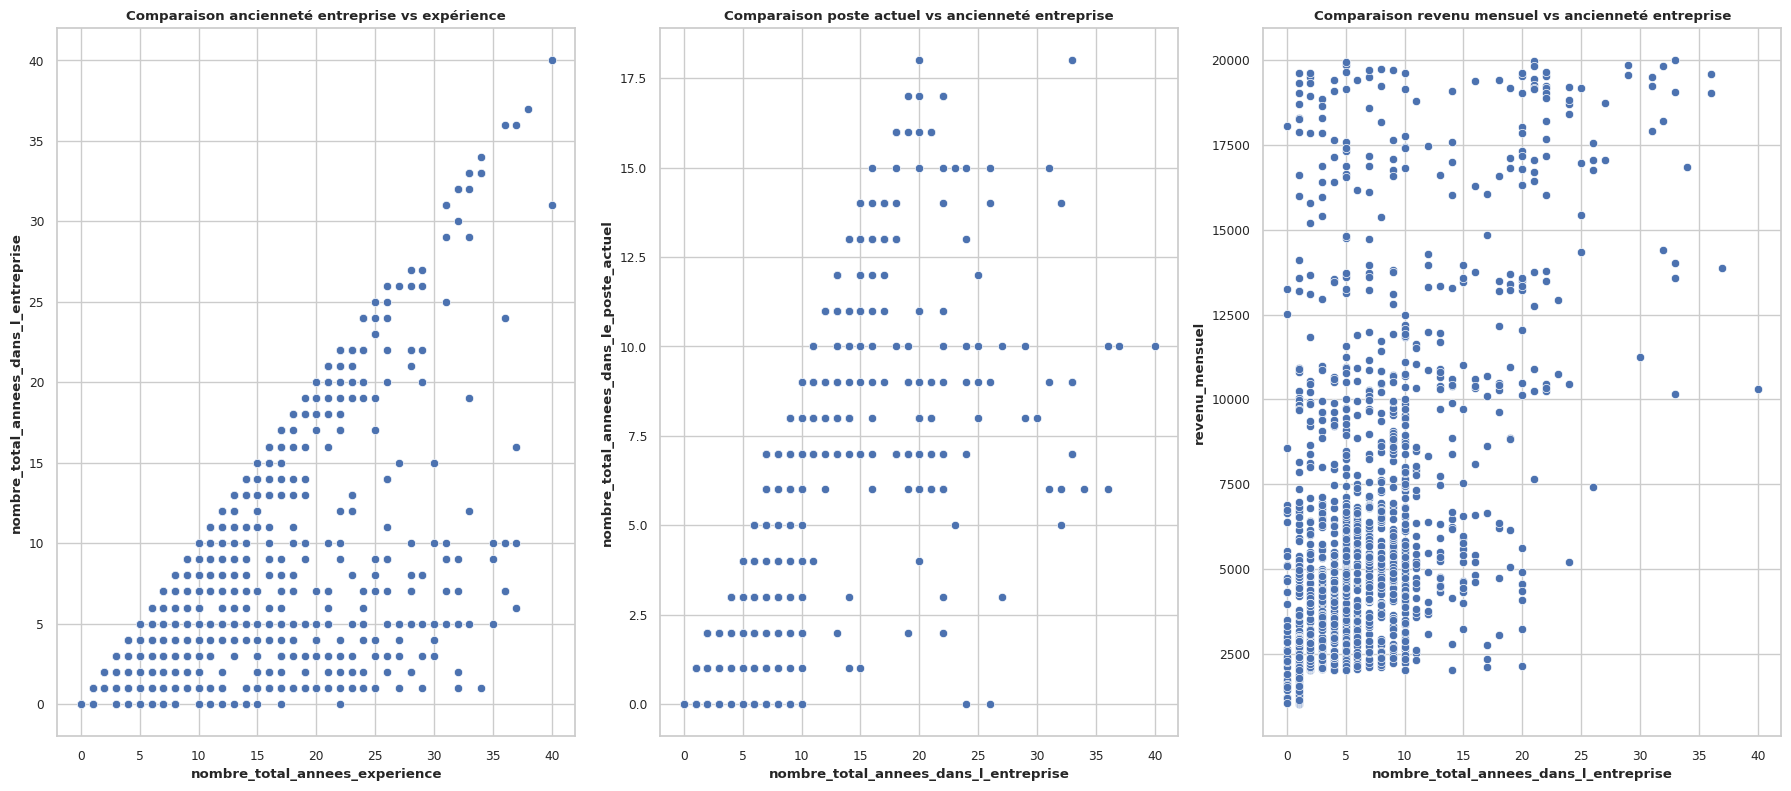

In [141]:
# Recherche de premieres corrélations
import matplotlib.pyplot as plt
import seaborn as sns

plots = [
    (
        "nombre_total_annees_experience",
        "nombre_total_annees_dans_l_entreprise",
        "Comparaison ancienneté entreprise vs expérience"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "nombre_total_annees_dans_le_poste_actuel",
        "Comparaison poste actuel vs ancienneté entreprise"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "revenu_mensuel",
        "Comparaison revenu mensuel vs ancienneté entreprise"
    )
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, (x, y, title) in enumerate(plots):
    sns.scatterplot(
        data=df_sirh,
        x=x,
        y=y,
        ax=axes[i]
    )
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel(x, fontweight='bold')
    axes[i].set_ylabel(y, fontweight='bold')

plt.tight_layout()
plt.show()

#### observations
* les salariés arrivent dans l'entreprise avec de l'entreprise déjà acquise ailleurs
* les salariés dans l'entreprise changent régulièrement de poste ce qui peut signifier soit **promotions** soit **restructurations fréquentes**

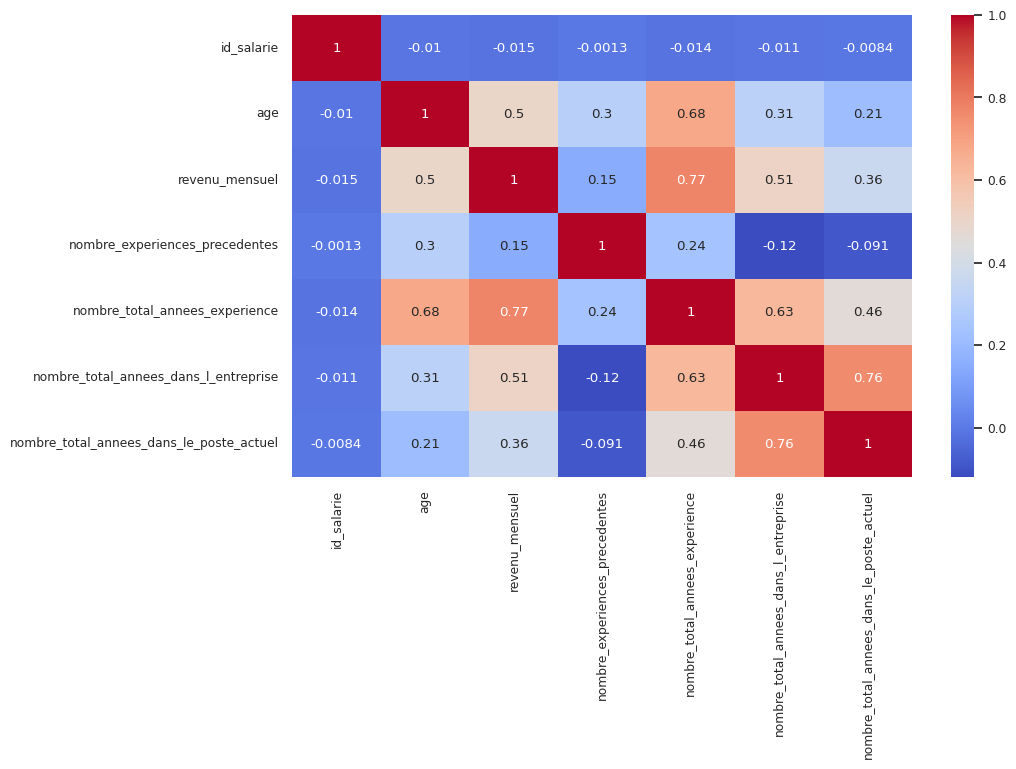

In [142]:
# Matrice globale des corrélations de df_sirh
plt.figure(figsize=(10,6))
sns.heatmap(df_sirh.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
Les variables suivantes sont fortement corrélées entre elles:
* l'âge augmente avec l'expérience
* l'expérience augmente avec le salaire 
* l'ancienneté augmente sans nécessairement changer de poste (soit **faible mobilité interne pouvant expliquer les départs** soit **évolution lente**)

Ces variables corrélées amènent de la **multicolinéarité** qui peut rendre les **poids instables** et **l'interprétation biaisée** dans une modélisaiton de machine learning. Il faudra donc:
* soit garder l'âge
* soit garder l'expérience
* ou créer une feature “ratio salaire / expérience”

### Etape 1-2 : EDA du dataframe df_eval avant jointure

In [143]:
df_eval = pd.read_csv("../data/raw/extrait_eval.csv")

In [144]:
df_eval.head(3)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


In [145]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [146]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_eval.rename(columns={
    "satisfaction_employee_environnement": "satisfaction_salarie_environnement",
    "satisfaction_employee_nature_travail": "satisfaction_salarie_nature_travail",
    "satisfaction_employee_equipe": "satisfaction_salarie_equipe",
    "satisfaction_employee_equilibre_pro_perso" : "satisfaction_salarie_equilibre_pro_perso",
    "eval_number" : "numero_d_evaluation",
    "heure_supplementaires" : "heures_supplementaires",
    "augementation_salaire_precedente" : "precedent_pourcentage_d_augmentation"  
}, inplace=True)

In [147]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   str  
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [148]:
int_cols_eval = df_eval.select_dtypes(include="int64").columns
print(int_cols_eval)

Index(['satisfaction_salarie_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail',
       'satisfaction_salarie_equipe',
       'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle'],
      dtype='str')


In [149]:
for col in int_cols_eval:
    a_decimales = (df_eval[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

satisfaction_salarie_environnement a décimales ? False
note_evaluation_precedente a décimales ? False
niveau_hierarchique_poste a décimales ? False
satisfaction_salarie_nature_travail a décimales ? False
satisfaction_salarie_equipe a décimales ? False
satisfaction_salarie_equilibre_pro_perso a décimales ? False
note_evaluation_actuelle a décimales ? False


In [150]:
# Identification des colonnes type chaînes de caractères
string_cols_eval = df_eval.select_dtypes(include="str").columns
print(string_cols_eval)

Index(['numero_d_evaluation', 'heures_supplementaires',
       'precedent_pourcentage_d_augmentation'],
      dtype='str')


In [151]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_eval:
    print(df_eval[col].unique()) 

<ArrowStringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str
<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


In [152]:
df_sirh["id_salarie"].min(), df_sirh["id_salarie"].max()

(np.int64(1), np.int64(2068))

In [153]:
# Transformer les colonnes au format int64 
import re

df_eval["numero_d_evaluation"] = df_eval["numero_d_evaluation"].apply(
    lambda x: int(re.sub(r"\D", "", str(x)))
)

df_eval["heures_supplementaires"] = df_eval["heures_supplementaires"].apply(
    lambda x: str(x).strip().lower()
)

df_eval["precedent_pourcentage_d_augmentation"] = df_eval["precedent_pourcentage_d_augmentation"].apply(
    lambda x: int(re.sub(r"[^\d]", "", str(x)))
)

In [154]:
for col in string_cols_eval:
    print(df_eval[col].unique()) 

[   1    2    4 ... 2064 2065 2068]
<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
[11 23 15 12 13 20 22 21 17 14 16 18 19 24 25]


In [155]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [156]:
# Recherche de valeurs manquantes 
df_eval.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

satisfaction_salarie_environnement          0
note_evaluation_precedente                  0
niveau_hierarchique_poste                   0
satisfaction_salarie_nature_travail         0
satisfaction_salarie_equipe                 0
satisfaction_salarie_equilibre_pro_perso    0
numero_d_evaluation                         0
note_evaluation_actuelle                    0
heures_supplementaires                      0
precedent_pourcentage_d_augmentation        0
dtype: int64

In [157]:
# Contrôle présence de doublons sur la colonne numero_d_evaluation
df_eval["numero_d_evaluation"].duplicated().any()

np.False_

In [158]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [159]:
# Statistiques descriptives du dataframe df_eval
num_cols_eval = df_eval.select_dtypes(include="int64").columns
cat_cols_eval = df_eval.select_dtypes(include="str").columns
df_eval[num_cols_eval].describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
satisfaction_salarie_nature_travail,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equipe,1470.0,2.712245,1.081209,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.00,3.0,3.00,4.0
numero_d_evaluation,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.00,3.0,3.00,4.0
precedent_pourcentage_d_augmentation,1470.0,15.209524,3.659938,11.0,12.00,14.0,18.00,25.0


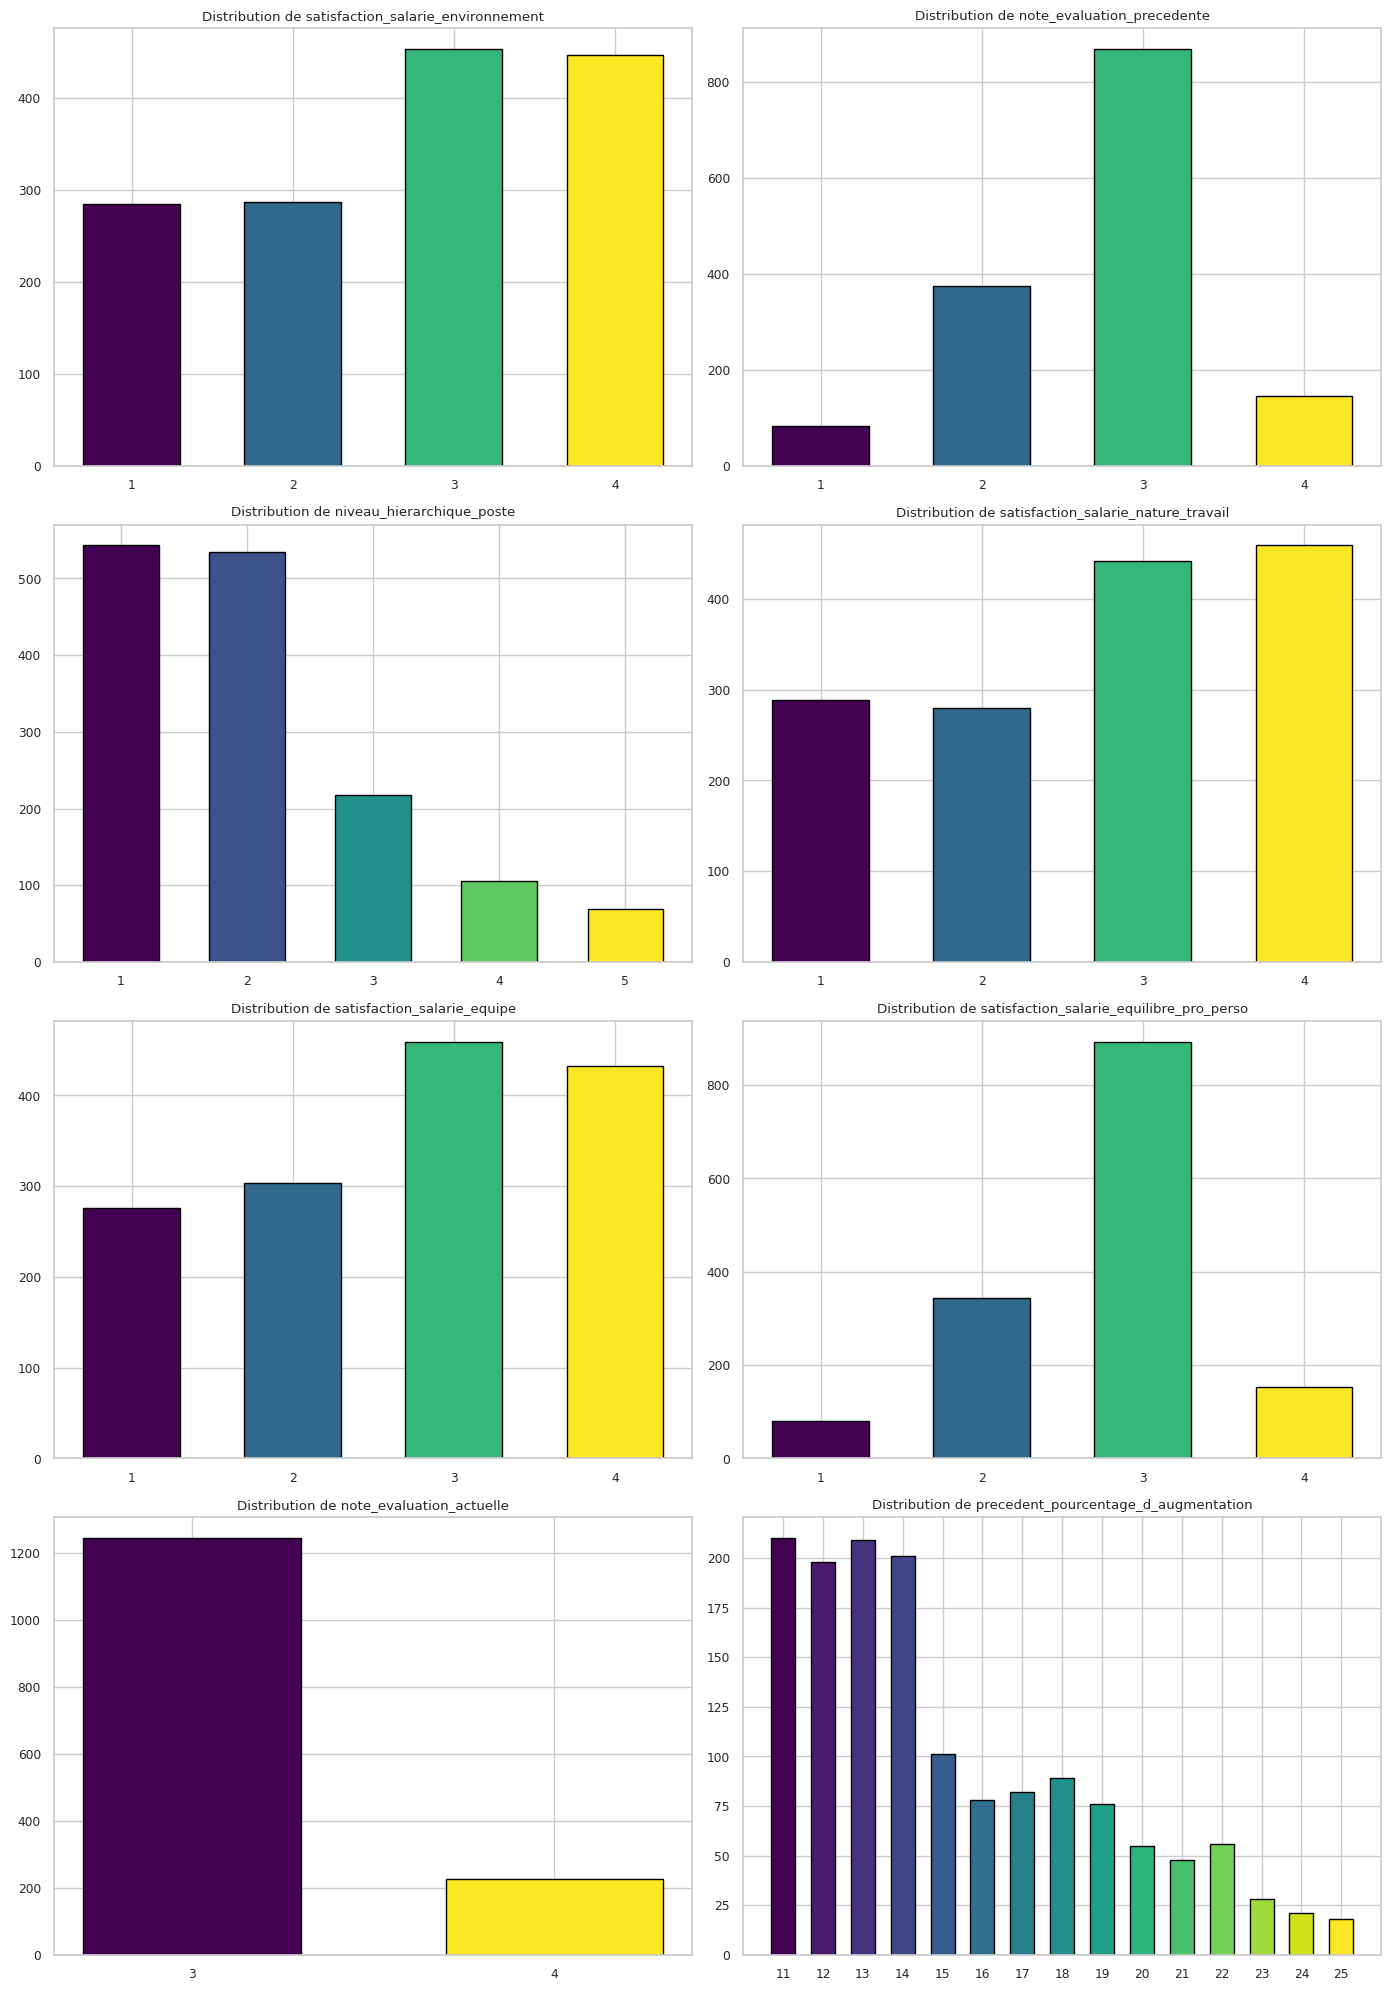

In [160]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

hierarchical_cols = ["niveau_hierarchique_poste"]
percent_cols = ["precedent_pourcentage_d_augmentation"]
exclude_cols = ["numero_d_evaluation"] 

# on retire la colonne du calcul
cols_to_plot = [col for col in num_cols_eval if col not in exclude_cols]

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.ravel()

cmap = plt.cm.viridis

for i, col in enumerate(cols_to_plot):

    # cas niveau hiérarchique
    if col in hierarchical_cols:
        levels = sorted(df_eval[col].unique())

    # cas pourcentage augmentation
    elif col in percent_cols:
        levels = sorted(df_eval[col].unique())
        axes[i].set_xlim(min(levels) - 1, max(levels) + 1)

    # autres variables numériques
    else:
        levels = sorted(df_eval[col].unique())

    # normalisation couleurs
    norm = mcolors.Normalize(vmin=min(levels), vmax=max(levels))

    counts = df_eval[col].value_counts().reindex(levels, fill_value=0)

    colors = [cmap(norm(x)) for x in counts.index]

    axes[i].bar(
        counts.index,
        counts.values,
        width=0.6,
        edgecolor="black",
        color=colors
    )

    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xticks(levels)

# supprimer axes inutilisés
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

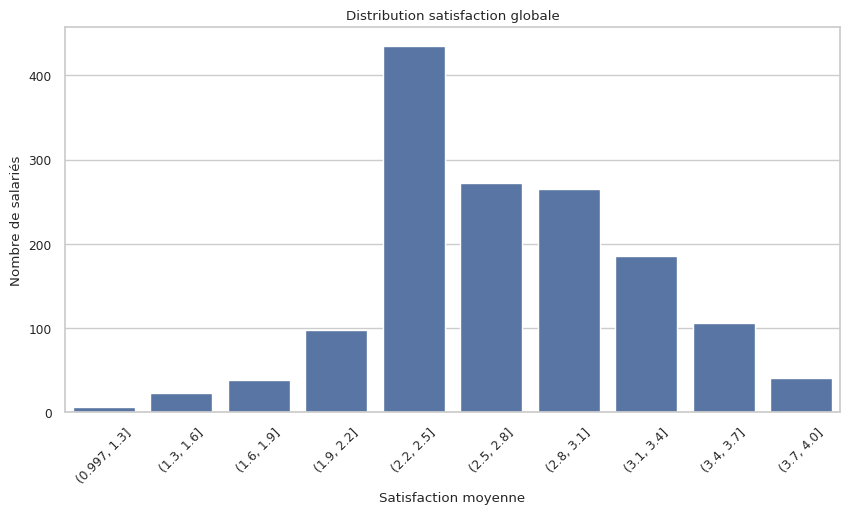

In [161]:

# création de la satisfaction moyenne
satisfaction_cols = [
    "satisfaction_salarie_environnement",
    "satisfaction_salarie_nature_travail",
    "satisfaction_salarie_equipe",
    "satisfaction_salarie_equilibre_pro_perso"
]

df_eval["satisfaction_moyenne"] = df_eval[satisfaction_cols].mean(axis=1)

# création des bins
df_eval["satisfaction_bin"] = pd.cut(
    df_eval["satisfaction_moyenne"],
    bins=10
)

# comptage par bin
bar_data = df_eval["satisfaction_bin"].value_counts().sort_index()

# barplot
plt.figure(figsize=(10,5))
sns.barplot(x=bar_data.index.astype(str), y=bar_data.values)

plt.xticks(rotation=45)
plt.title("Distribution satisfaction globale")
plt.xlabel("Satisfaction moyenne")
plt.ylabel("Nombre de salariés")

plt.show()

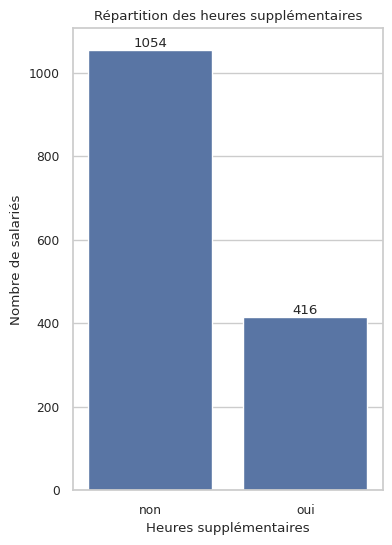

In [162]:
# distribution des heures supplémentaires

plt.figure(figsize=(4,6))

ax = sns.countplot(
    data=df_eval,
    x="heures_supplementaires",
    order=["non", "oui"] 
)

# titres
plt.title("Répartition des heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre de salariés")

# ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container)

plt.show()

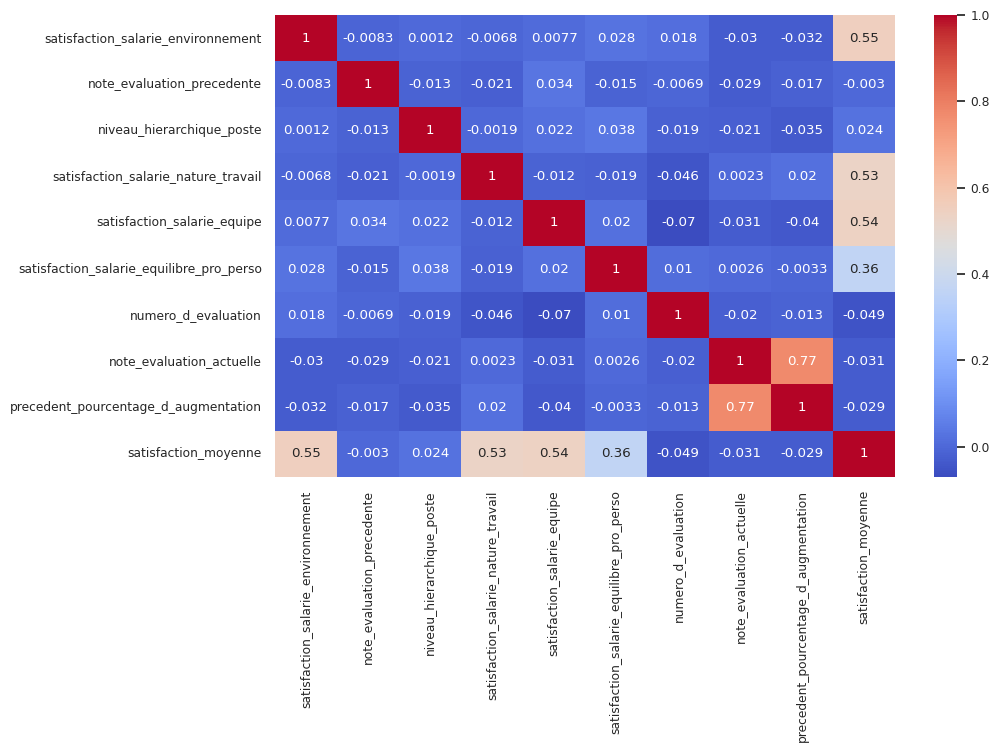

In [163]:
# matrice globale des corrélations de df_eval
plt.figure(figsize=(10,6))
sns.heatmap(df_eval.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
* satisfaction globale moyenne mais pas excellente
* **peu de différenciation individuelle sur l'augmentation salariale**
* perception de l'environnement de travail globalement bonne mais pas homogène (400 personnes note 3 et 400 personnes note 4) **ce qui peut cacher des différences dans les différents départements de travail**
* le système de notation d'évaluation actuelle est peu discriminant par près de 80%  des salariés ont leur performance notée à 3. Or 400 salariés evaluent la satisfaction globale à 2 **ce qui montre que les salariés évaluent moins bien leur bien-être (pouvant causer des départs) que leur performance ce qui est synonyme de stress global**.
* 30% de l'effectif effectue des heures supplémentaires ce qui peut être source de stress
* **plus la note d’évaluation est élevée, plus le pourcentage d’augmentation est élevé**
* la note d’évaluation précédente n’a pas de corrélation linéaire simple avec la note actuelle (un salarié bien noté avant n’est pas forcément bien noté maintenant (et inversement)), **ce qui peut suggérer que les signaux de départ sont plutôt dans le contexte actuel que dans l’historique**


In [164]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   satisfaction_salarie_environnement        1470 non-null   int64   
 1   note_evaluation_precedente                1470 non-null   int64   
 2   niveau_hierarchique_poste                 1470 non-null   int64   
 3   satisfaction_salarie_nature_travail       1470 non-null   int64   
 4   satisfaction_salarie_equipe               1470 non-null   int64   
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64   
 6   numero_d_evaluation                       1470 non-null   int64   
 7   note_evaluation_actuelle                  1470 non-null   int64   
 8   heures_supplementaires                    1470 non-null   str     
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64   
 10  satisfaction_moyenne               

### Etape 1-3 : EDA du dataframe df_sondage avant jointure

In [165]:
df_sondage = pd.read_csv("../data/raw/extrait_sondage.csv")

In [166]:
df_sondage.head(3)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


In [167]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [168]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sondage.rename(columns={
    "nb_formations_suivies" : "nombre_de_formations_suivies",
    "nombre_employee_sous_responsabilite" : "nombre_de_salaries_sous_sa_responsabilite",
    "annees_depuis_la_derniere_promotion" : "nombre_d_annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel" : "nombre_d_annees_sous_le_responsable_actuel"
}, inplace=True)

In [169]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [170]:
int_cols_sondage = df_sondage.select_dtypes(include="int64").columns
print(int_cols_sondage)

Index(['nombre_participation_pee', 'nombre_de_formations_suivies',
       'nombre_de_salaries_sous_sa_responsabilite', 'code_sondage',
       'distance_domicile_travail', 'niveau_education',
       'nombre_d_annees_depuis_la_derniere_promotion',
       'nombre_d_annees_sous_le_responsable_actuel'],
      dtype='str')


In [171]:
for col in int_cols_sondage:
    a_decimales = (df_sondage[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

nombre_participation_pee a décimales ? False
nombre_de_formations_suivies a décimales ? False
nombre_de_salaries_sous_sa_responsabilite a décimales ? False
code_sondage a décimales ? False
distance_domicile_travail a décimales ? False
niveau_education a décimales ? False
nombre_d_annees_depuis_la_derniere_promotion a décimales ? False
nombre_d_annees_sous_le_responsable_actuel a décimales ? False


In [172]:
# Identification des colonnes type chaînes de caractères
string_cols_sondage = df_sondage.select_dtypes(include="str").columns
print(string_cols_sondage)

Index(['a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants',
       'frequence_deplacement'],
      dtype='str')


In [173]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
<ArrowStringArray>
['Y']
Length: 1, dtype: str
<ArrowStringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str


In [174]:
# Recherche de valeurs manquantes 
df_sondage.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

a_quitte_l_entreprise                           0
nombre_participation_pee                        0
nombre_de_formations_suivies                    0
nombre_de_salaries_sous_sa_responsabilite       0
code_sondage                                    0
distance_domicile_travail                       0
niveau_education                                0
domaine_etude                                   0
ayant_enfants                                   0
frequence_deplacement                           0
nombre_d_annees_depuis_la_derniere_promotion    0
nombre_d_annees_sous_le_responsable_actuel      0
dtype: int64

In [175]:
# Retirer les majuscules, espaces, & et remplacer Y par oui
df_sondage[string_cols_sondage] = df_sondage[string_cols_sondage].apply(
    lambda col: col.astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "et", regex=False)
    .str.replace(" ", "_", regex=False)
    .apply(lambda x: "oui" if x == "y" else x)
)

In [176]:
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
<ArrowStringArray>
[         'infra_et_cloud',                   'autre',
 'transformation_digitale',               'marketing',
         'entrepreunariat',     'ressources_humaines']
Length: 6, dtype: str
<ArrowStringArray>
['oui']
Length: 1, dtype: str
<ArrowStringArray>
['occasionnel', 'frequent', 'aucun']
Length: 3, dtype: str


In [177]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [178]:
df_sondage["code_sondage"].min(), df_sondage["code_sondage"].max()

(np.int64(1), np.int64(2068))

In [179]:
# Contrôle présence de doublons sur la colonne code_sondage
df_sondage["code_sondage"].duplicated().any()

np.False_

In [180]:
# statistiques descriptiques du dataframe df_sondage
df_sondage.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nombre_de_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_de_salaries_sous_sa_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
code_sondage,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
nombre_d_annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
nombre_d_annees_sous_le_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0


#### observations 
- Le nombre de salaries sous sa responsaiblité est toujours égal à 1 donc pas de variabilité dans les données, la colonne pourra être retirée du dataframe.

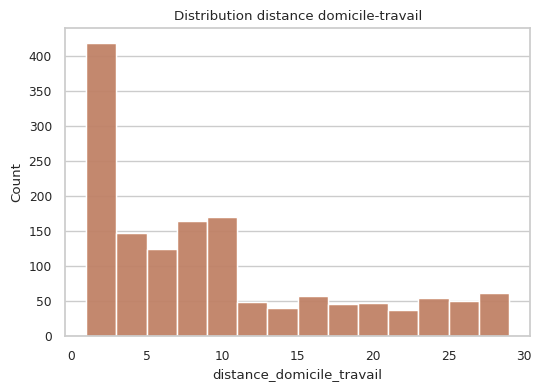

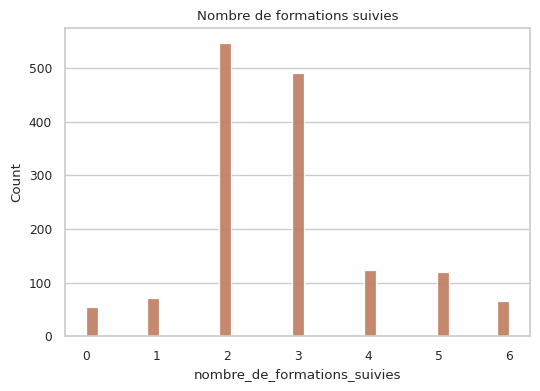

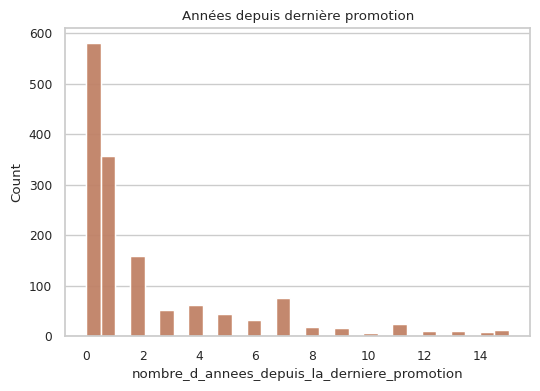

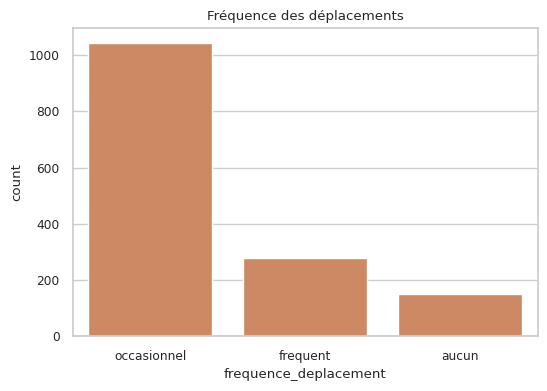

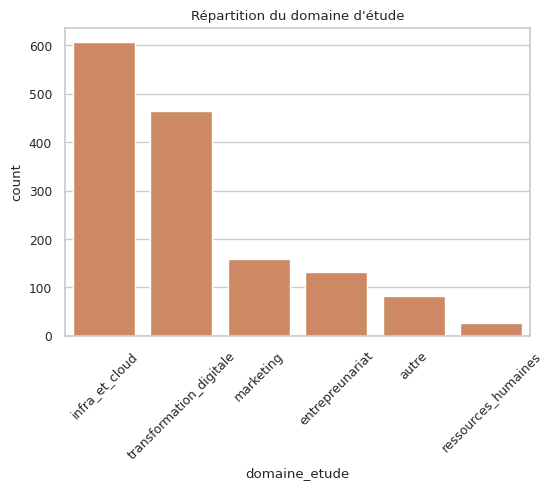

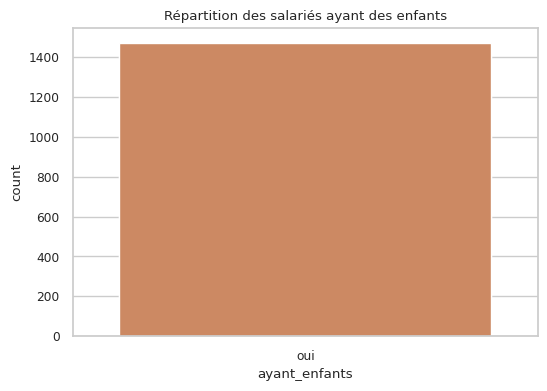

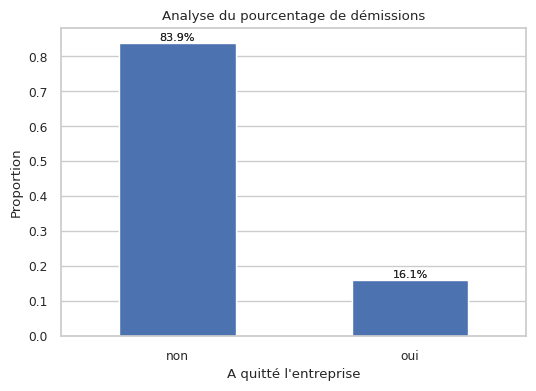

In [181]:
# Visualisations univariées

sns.set_style("whitegrid", {'axes.grid.axis': 'y'})
plt.rcParams["figure.figsize"] = (6, 4)

# Distance domicile-travail
sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax = sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Distribution distance domicile-travail")
plt.show()

# Formations suivies
sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax = sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Nombre de formations suivies")
plt.show()

# Années depuis dernière promotion
sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax = sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Années depuis dernière promotion")
plt.show()

# Fréquence des déplacements
sns.countplot(data=df_sondage, x="frequence_deplacement")
ax = sns.countplot(data=df_sondage, x="frequence_deplacement")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Fréquence des déplacements")
plt.show()

# Domaine d'étude 
sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax = sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition du domaine d'étude")
plt.xticks(rotation=45, ha="center", fontsize=9)
plt.show()

# Ayant enfants
sns.countplot(data=df_sondage, x="ayant_enfants")
ax = sns.countplot(data=df_sondage, x="ayant_enfants")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition des salariés ayant des enfants")
plt.show()

# a quitté l'entreprise (variable cible potentielle)
plt.figure()

(df_sondage["a_quitte_l_entreprise"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

ax = (df_sondage["a_quitte_l_entreprise"]
      .value_counts(normalize=True)
      .sort_index()
      .plot(kind="bar"))

# ajout des labels directement
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)

plt.title("Analyse du pourcentage de démissions")
plt.ylabel("Proportion")
plt.xlabel("A quitté l'entreprise")
plt.xticks(rotation=0)

plt.show()


In [182]:
# Analyse de la variable cible a_quitte_l_entreprise
df_sondage["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
non    0.838776
oui    0.161224
Name: proportion, dtype: float64

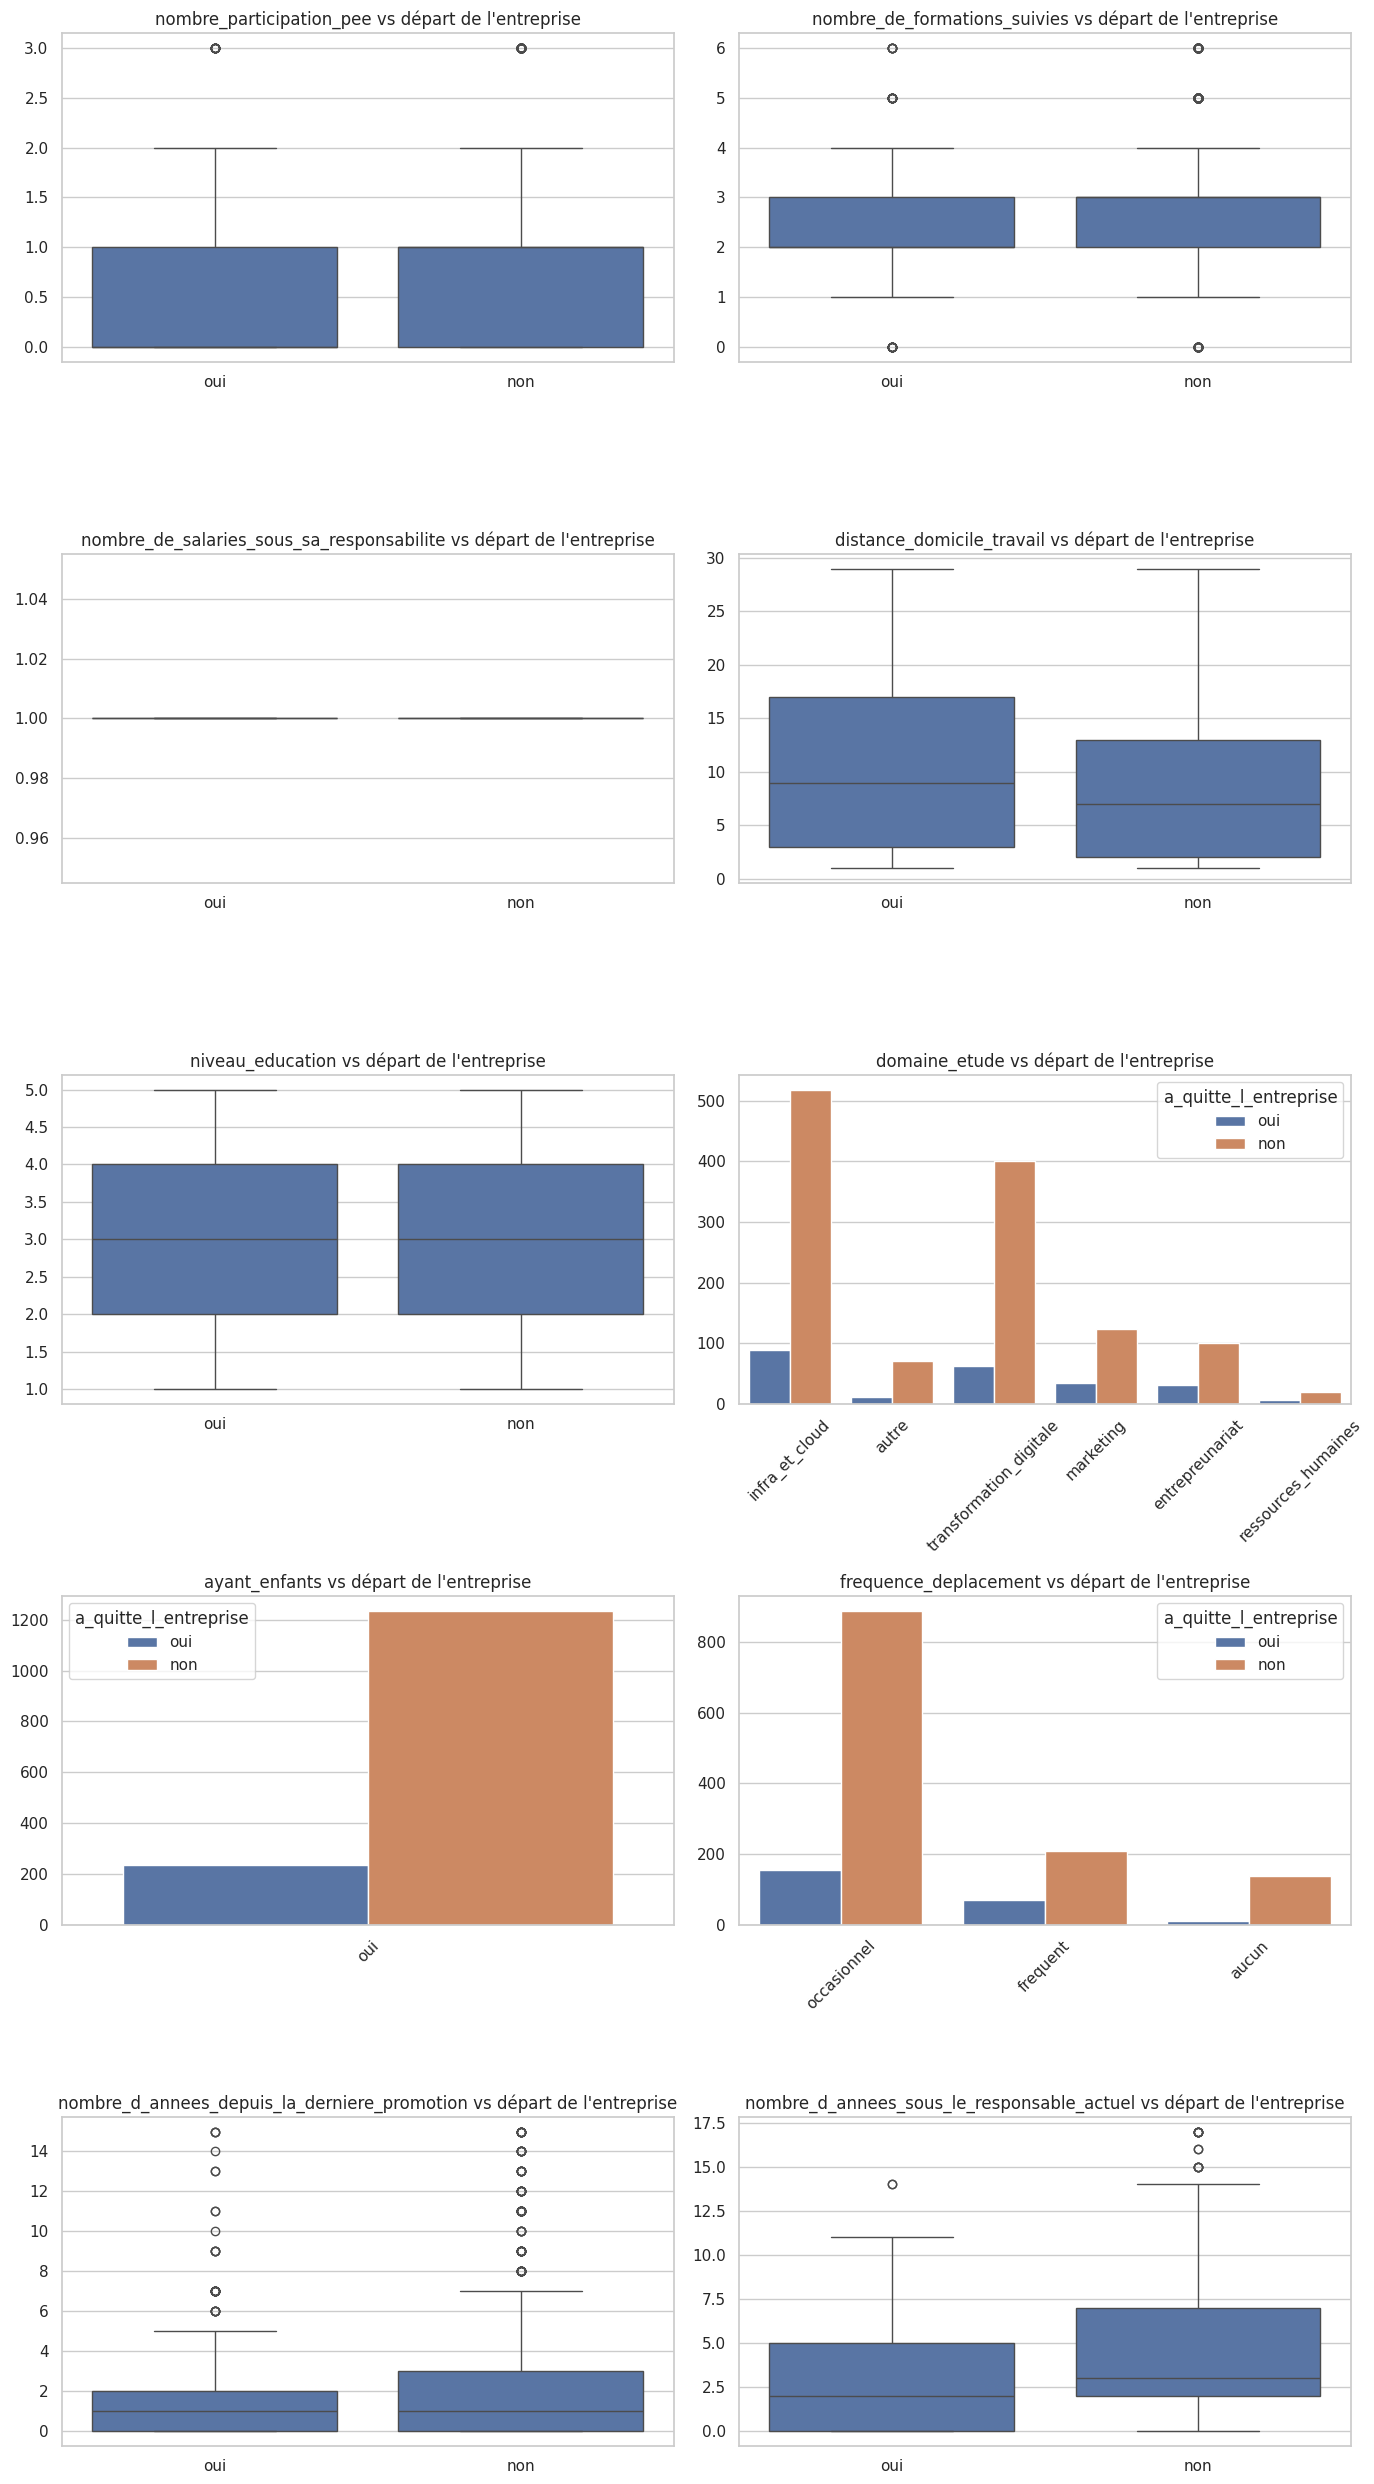

In [183]:
# visualisaitons bivariees
import math

sns.set(style="whitegrid")

cols = [
    "nombre_participation_pee",
    "nombre_de_formations_suivies",
    "nombre_de_salaries_sous_sa_responsabilite",
    "distance_domicile_travail",
    "niveau_education",
    "domaine_etude",
    "ayant_enfants",
    "frequence_deplacement",
    "nombre_d_annees_depuis_la_derniere_promotion",
    "nombre_d_annees_sous_le_responsable_actuel"
]

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    # Cas variables numériques
    if df_sondage[col].dtype == "int64":
        sns.boxplot(
            data=df_sondage,
            x="a_quitte_l_entreprise",
            y=col,
            ax=axes[i]
        )
    
    # Cas variables catégorielles
    else:
        sns.countplot(
            data=df_sondage,
            x=col,
            hue="a_quitte_l_entreprise",
            ax=axes[i]
        )
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} vs départ de l'entreprise")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# supprimer axes inutilisés
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### observations
* **la colonne ayant enfants pourra être retirée du dataframe** car la réponse est toujours oui, donc la variable n'apportera pas d'informations
* population plutôt proche du lieu de travail, **peu de contrainte géographique globale**
* **politique de formation active** (1000 salaries ont suivi entre 2 et 3 formations), faible dispersion des valeurs dans la boxplot
* promotions récentes nombreuses
* **déplacements assez présents** ce qui peut être facteur potentiel de fatigue puis de départ de l'entreprise
* population technique dominante
* **le dataset présente un déséquilibre de classes significatif sur la variable cible**, ce qui nécessitera des techniques adaptées (pondération, rééchantillonnage avec undersampling) lors de la modélisation machine learning
* **davantage de départs dans le domaine “infra & cloud”** (profils très demandés, stress, sous-payé par rapport au marché)
* **population majoritairement technique** (domaine infra & cloud), avec une forte concentration des départs dans ce segment 
* **les salariés présentent une ancienneté faible depuis leur dernière promotion** et une fréquence de déplacement majoritairement occasionnelle
* **le déséquilibre de classes (16% de départs) devra être pris en compte dans les étapes de modélisation**

In [184]:
df_sondage.drop(
    columns=[
        "ayant_enfants",
        "nombre_de_salaries_sous_sa_responsabilite"
    ],
    inplace=True
)
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   code_sondage                                  1470 non-null   int64
 4   distance_domicile_travail                     1470 non-null   int64
 5   niveau_education                              1470 non-null   int64
 6   domaine_etude                                 1470 non-null   str  
 7   frequence_deplacement                         1470 non-null   str  
 8   nombre_d_annees_depuis_la_derniere_promotion  1470 non-null   int64
 9   nombre_d_annees_sous_le_responsable_actuel    1470 non-null   int64
dtypes: int64(7), str(3)
mem

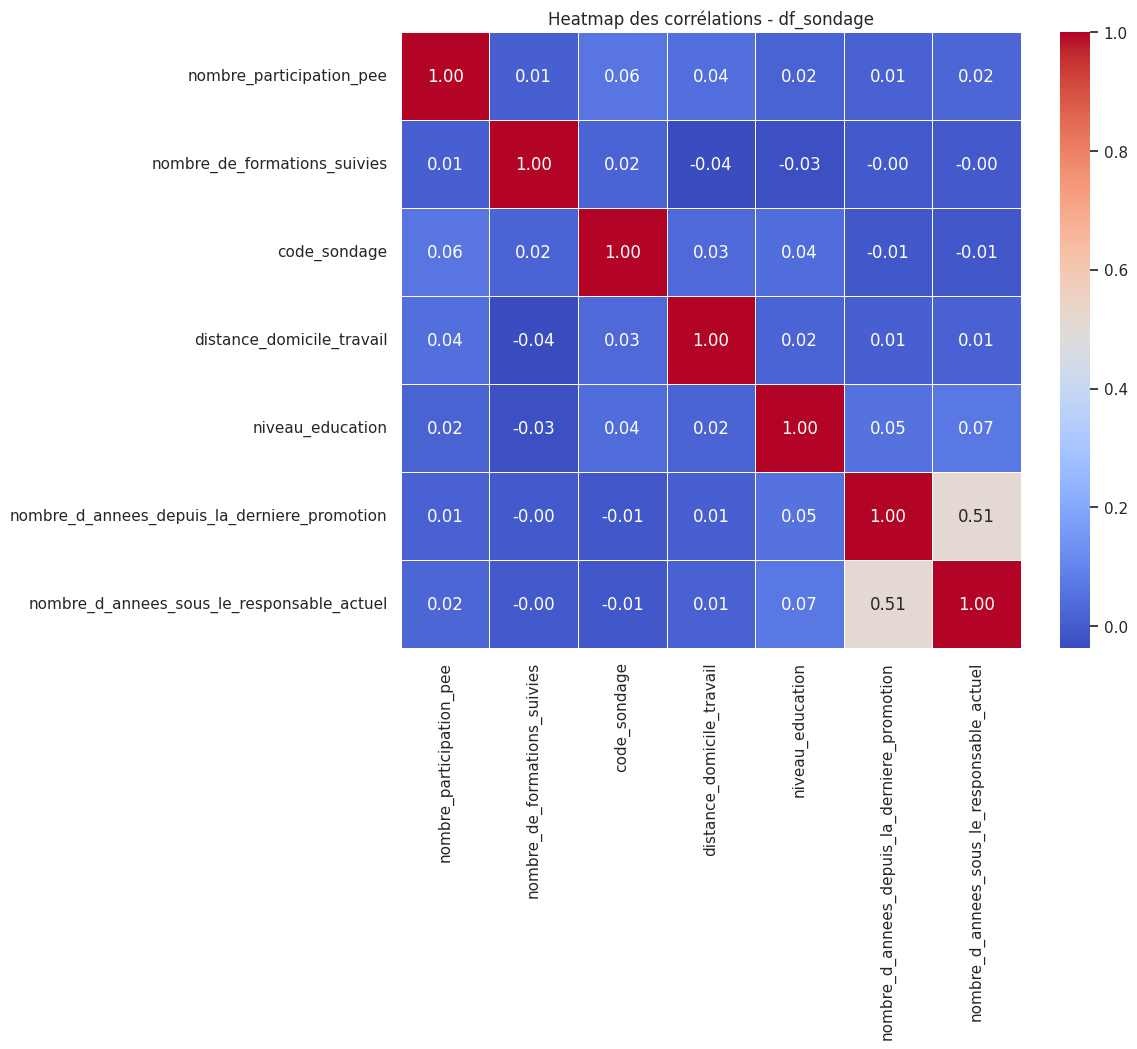

In [185]:
# Matrice globale des corrélations de df_sondage
# sélection des colonnes numériques
num_cols_sondage = df_sondage.select_dtypes(include="int64")

# matrice de corrélation
corr_matrix = num_cols_sondage.corr()

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap des corrélations - df_sondage")
plt.show()

#### observations
- Une corrélation modérée (0.51) entre le nombre d’années depuis la dernière promotion et l’ancienneté avec le responsable actuel suggère que **les salariés restés longtemps sous le même management ont tendance à connaître une progression de carrière plus lente, ce qui peut refléter une certaine stagnation professionnelle**. Ceci peut être une motivation pour quitter l'entreprise.

### Etape 1-4 : Réalisation de la jointure pour réunir les 3 dataframes 

In [186]:
# Réalisation de la jointure pour réunir les trois dataframes

df_sirh = df_sirh.rename(columns={"id_salarie": "id"})
df_eval = df_eval.rename(columns={"numero_d_evaluation": "id"})
df_sondage = df_sondage.rename(columns={"code_sondage": "id"})

df_joint = (
    df_sirh
    .merge(df_eval, on="id", how="inner")
    .merge(df_sondage, on="id", how="inner")
    .sort_values(by="id")
    .reset_index(drop=True)
)

In [187]:
# Contrôle dimensions du dataframe obtenu et de l'absence de doublons
print("Shape finale :", df_joint.shape)
print("Doublons :", df_joint.duplicated().sum())

Shape finale : (1470, 31)
Doublons : 0


In [188]:
df_joint.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   id                                            1470 non-null   int64   
 1   age                                           1470 non-null   int64   
 2   genre                                         1470 non-null   str     
 3   revenu_mensuel                                1470 non-null   int64   
 4   statut_marital                                1470 non-null   str     
 5   departement                                   1470 non-null   str     
 6   poste                                         1470 non-null   str     
 7   nombre_experiences_precedentes                1470 non-null   int64   
 8   nombre_total_annees_experience                1470 non-null   int64   
 9   nombre_total_annees_dans_l_entreprise         1470 non-null   i

### Etape 1-5 : EDA sur le dataframe obtenu df_joint

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [190]:
df_joint.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1470.0,1024.865306,602.024335,1.0,491.25,1020.50,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.00,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.00,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.00,4.00,9.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.00,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.00,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.00,7.00,18.0
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.00,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.00,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.00,3.00,5.0


In [191]:
# Fonctions python pour l'EDA sur le dataframe df_joint issu de la jointure

def eda_univariee(df, num_cols=None, cat_cols=None):
    """Visualisations univariées pour les colonnes numériques et catégorielles"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques
    for col in num_cols:
        sns.histplot(df[col], kde=False)
        plt.title(f"Distribution de {col}")
        plt.show()
    
    # Catégorielles
    for col in cat_cols:
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.show()


def eda_bivariee(df, target_col, num_cols=None, cat_cols=None):
    """Visualisations bivariées entre features et la cible"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques vs cible
    for col in num_cols:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=df[target_col], y=df[col])
        
        plt.title(f"{col} selon {target_col}", fontsize=14)
        plt.xlabel(target_col, fontsize=12)
        plt.ylabel(col, fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        plt.show()
    
    # Catégorielles vs cible
    for col in cat_cols:
        plt.figure(figsize=(8,5))
        sns.countplot(x=col, hue=target_col, data=df)
        
        plt.title(f"{col} selon {target_col}", fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks(fontsize=10, rotation=45)
        plt.yticks(fontsize=10)
        
        plt.legend(title=target_col, fontsize=10, title_fontsize=11)
        
        plt.show()

def correlation_heatmap(df, method="pearson"):
    """
    - method="pearson" : variables normalement distribuées
    - method="spearman": variables non normales ou discrètes
    """
    if method == "pearson":
        cols = [
            "age"  
        ]
    elif method == "spearman":
        cols = [
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "precedent_pourcentage_d_augmentation",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel"
        ]
    else:
        raise ValueError("Méthode doit être 'pearson' ou 'spearman'")

    plt.figure(figsize=(20,18)) 

    sns.heatmap(
    df[cols].corr(method=method),
    annot=True,           
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},  
    linewidths=0.8          
)

    plt.title(f"Matrice de corrélation ({method})", fontsize=16)
    plt.xticks(fontsize=10, rotation=90)  
    plt.yticks(fontsize=10, rotation=0)  
    plt.tight_layout()                     
    plt.show()


def pairplot_sample(df, cols, target_col, sample_size=500):
    """Pairplot pour un sous-échantillon de lignes de df_joint"""
    # Sous-échantillon
    if len(df) > sample_size:
        df_sample = df.sample(sample_size, random_state=42)
    else:
        df_sample = df

    # Style et taille globale
    sns.set_context("notebook", font_scale=0.8)  
    g = sns.pairplot(
        df_sample[cols + [target_col]],
        hue=target_col,
        diag_kind="kde",
        height=3.5,    
        aspect=1.2    
    )

    for ax in g.axes.flatten():
        if ax is not None:
            ax.xaxis.label.set_fontweight('bold')
            ax.yaxis.label.set_fontweight('bold')

    # Mettre la légende en gras
    if g._legend is not None:
        for text in g._legend.get_texts():
            text.set_fontweight('bold')

    # Ajuster l'espacement
    plt.subplots_adjust(top=0.95)
    plt.show()

In [192]:
# Fonctions python pour préparer les features X et la target y à partir de df_joint

def prepare_features(df, target_col):
    """
    Prépare X et y pour sklearn :
    - encode la cible en binaire
    - sépare features numériques et catégorielles
    - encode les catégorielles avec OneHotEncoder
    """
    # Cible
    y = df[target_col].map({"Oui":1, "Non":0})  # ajuster selon vos valeurs

    # Features
    X = df.drop(columns=[target_col, "id"])  # on enlève id et cible

    # Colonnes catégorielles
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    # OneHotEncoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X_encoded, y

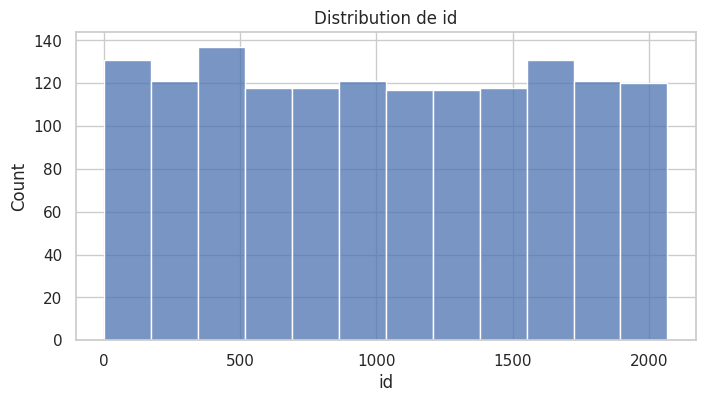

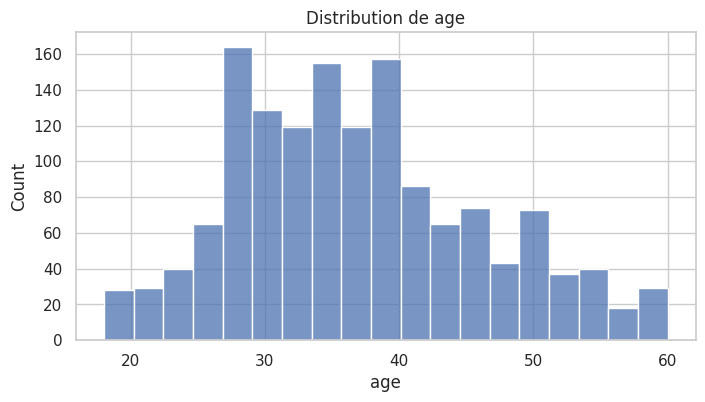

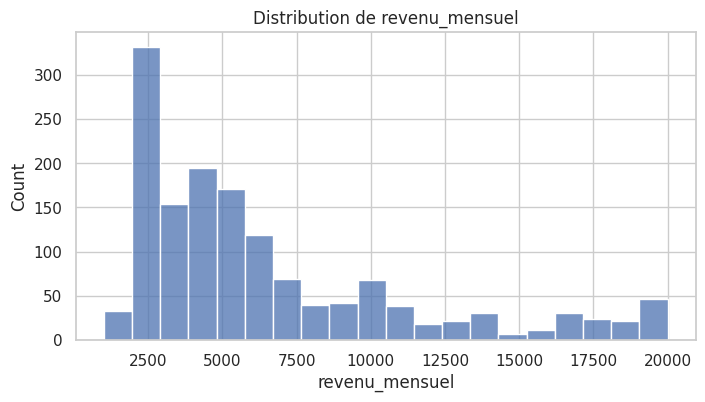

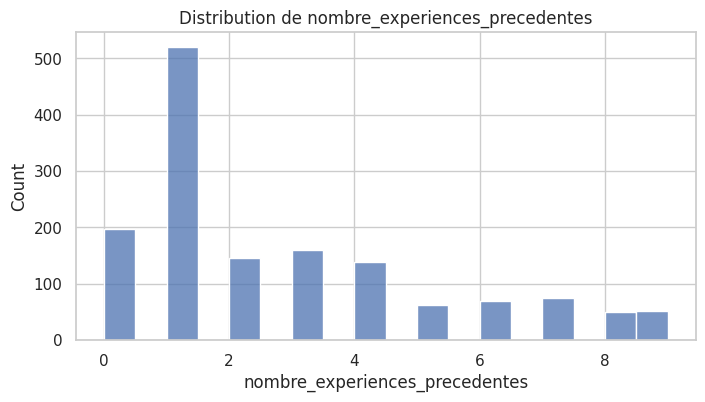

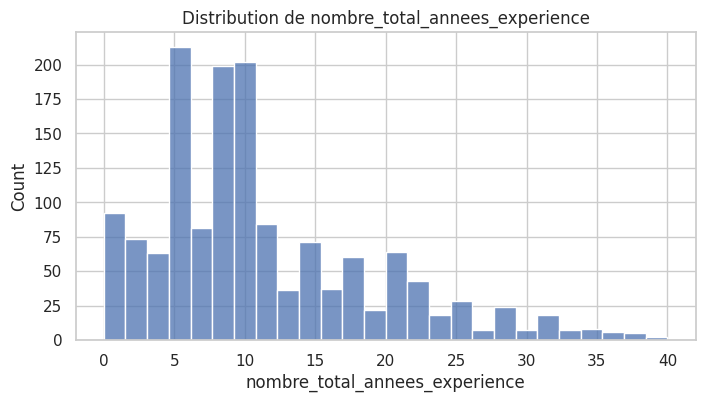

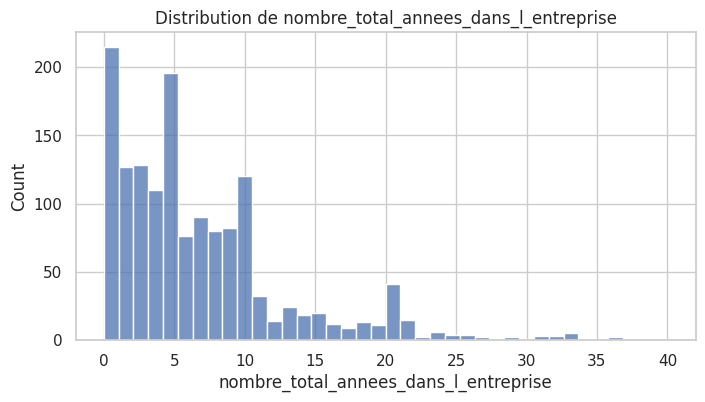

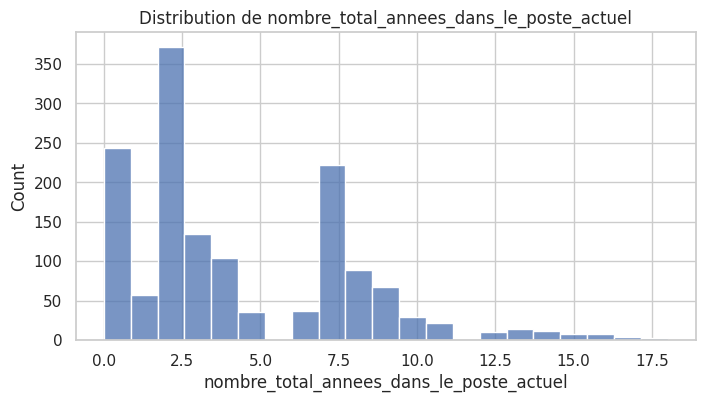

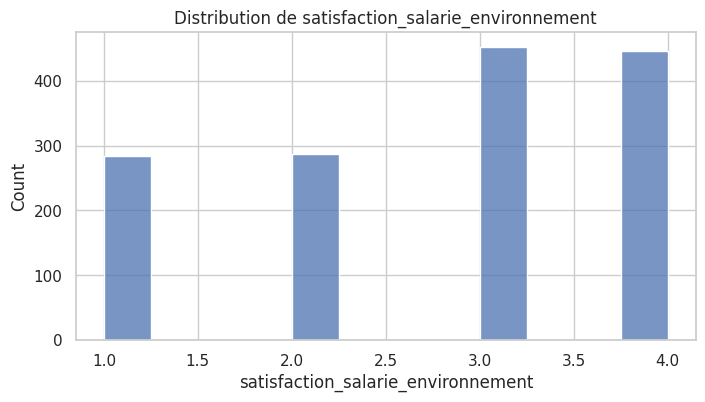

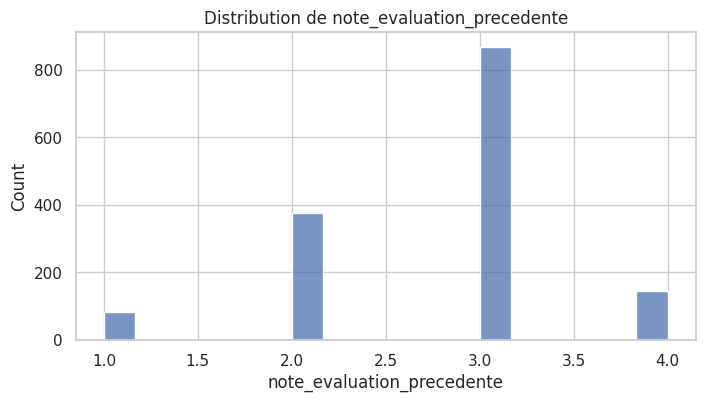

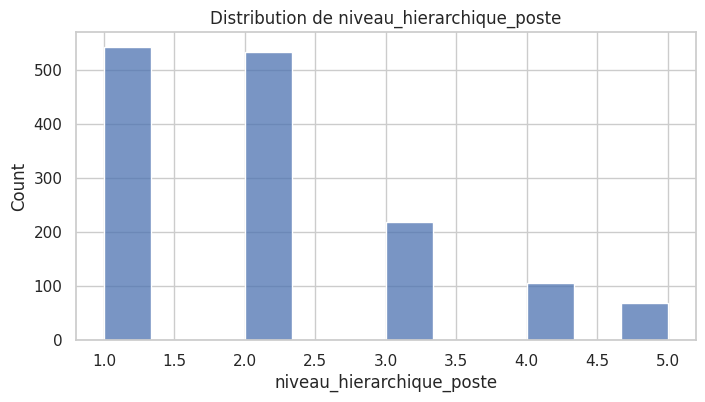

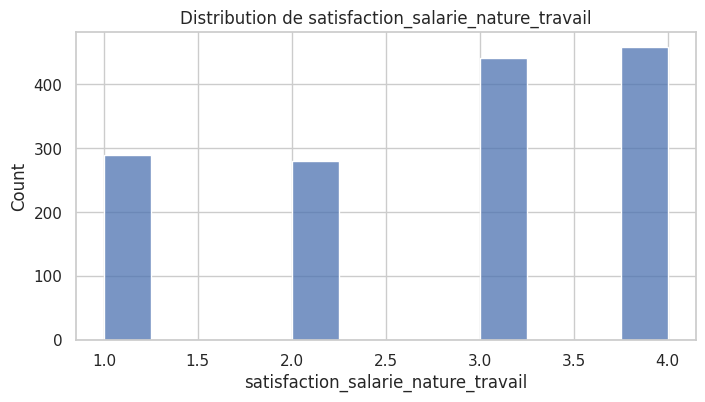

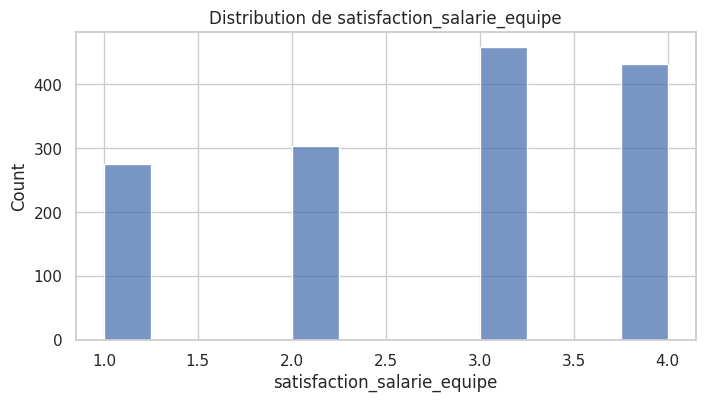

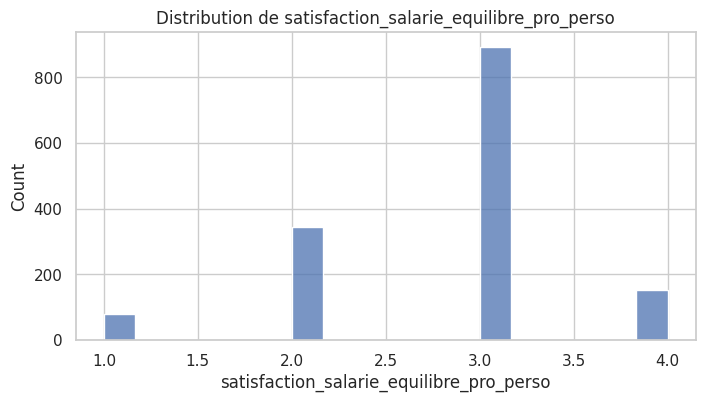

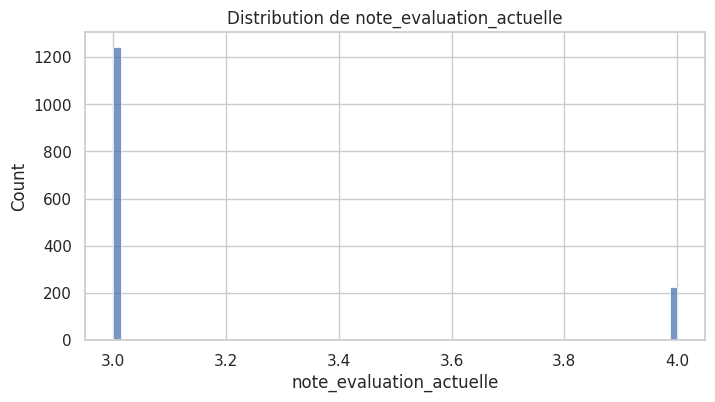

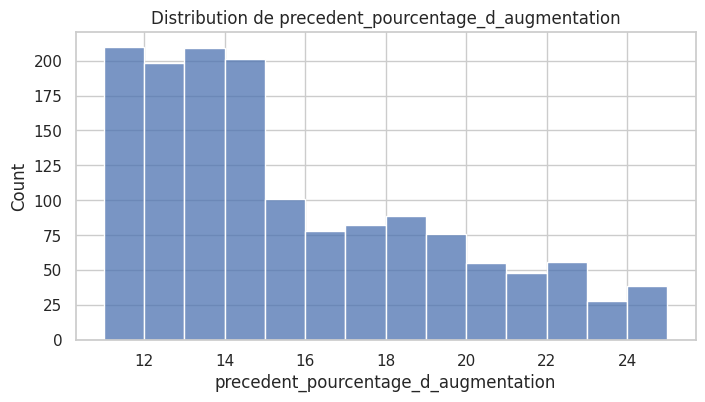

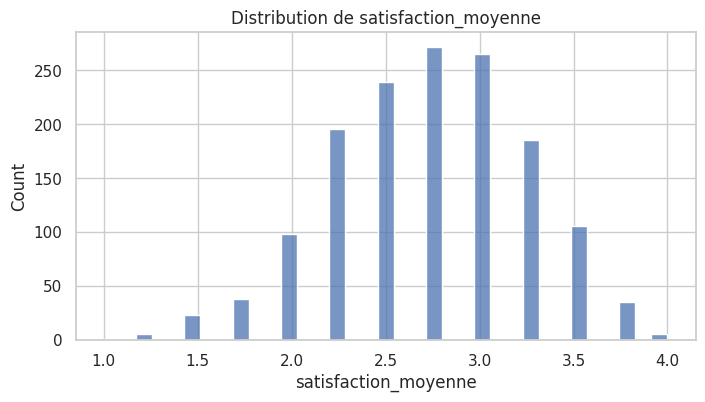

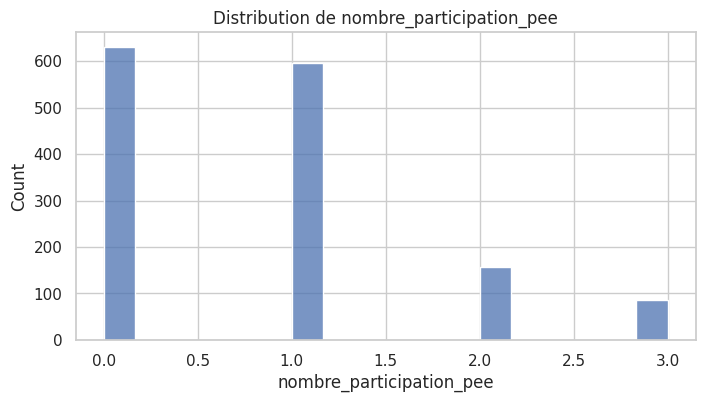

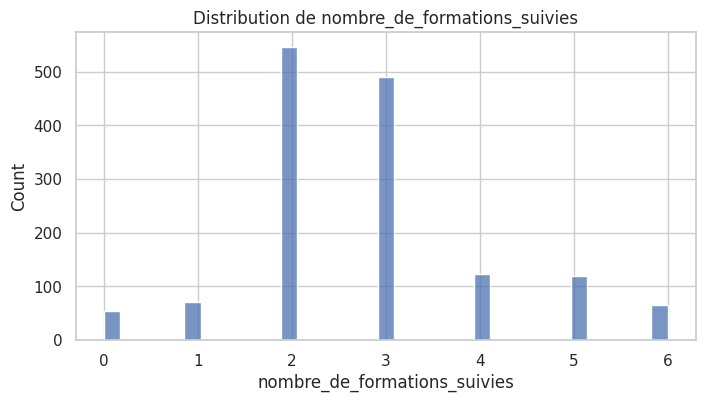

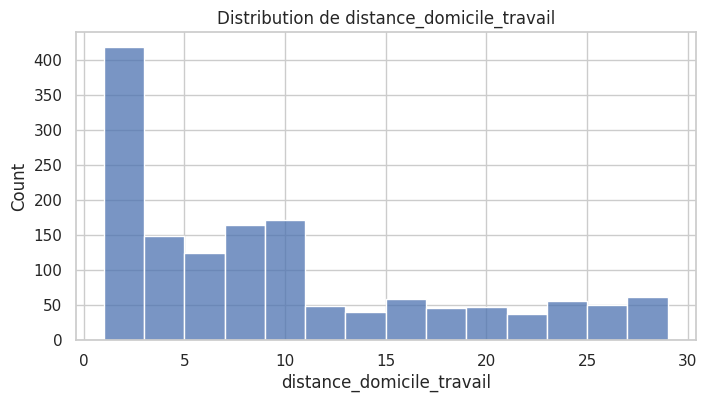

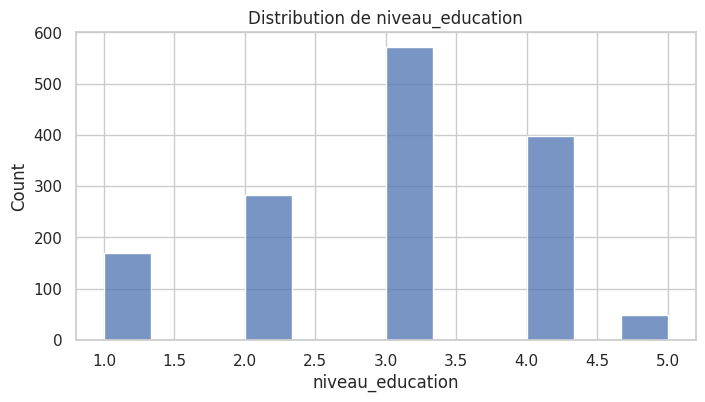

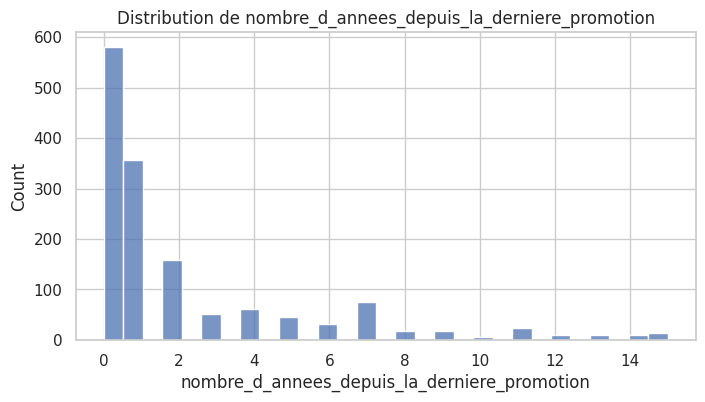

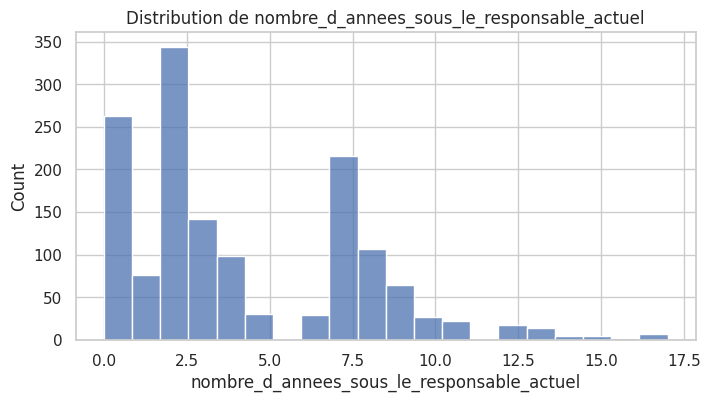

In [193]:
# EDA univariée

# On enlève l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]

# Sélection des colonnes numériques uniquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns

# Appel de la fonction univariée avec ces colonnes
eda_univariee(df_joint, num_cols=num_cols, cat_cols=[])

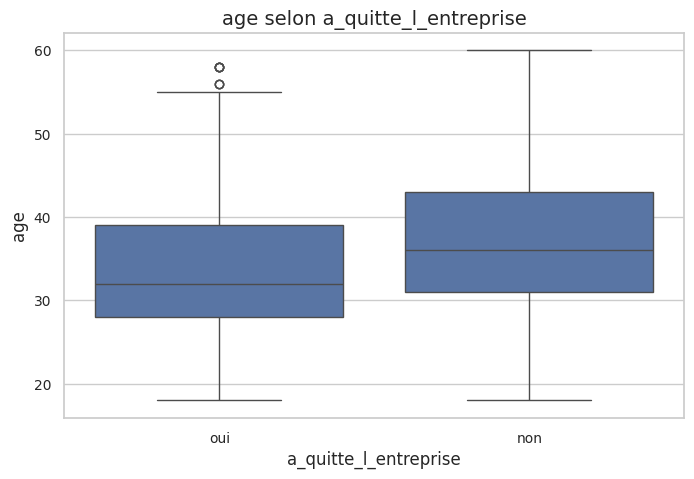

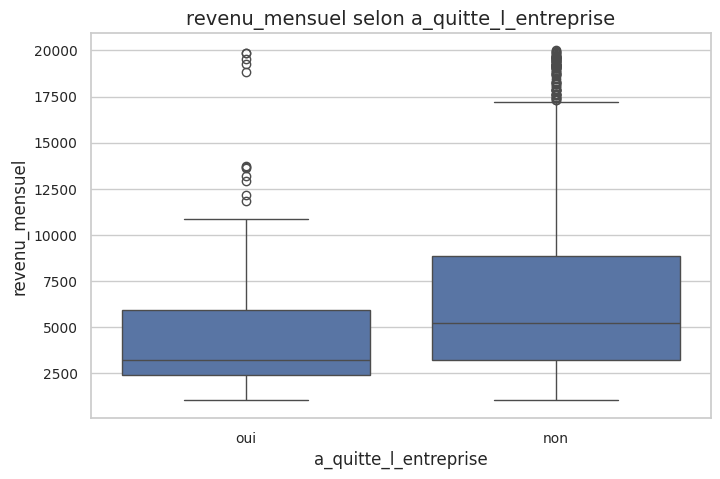

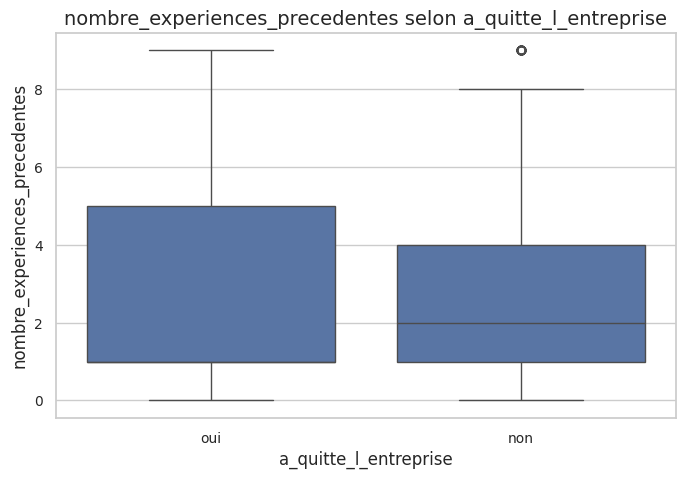

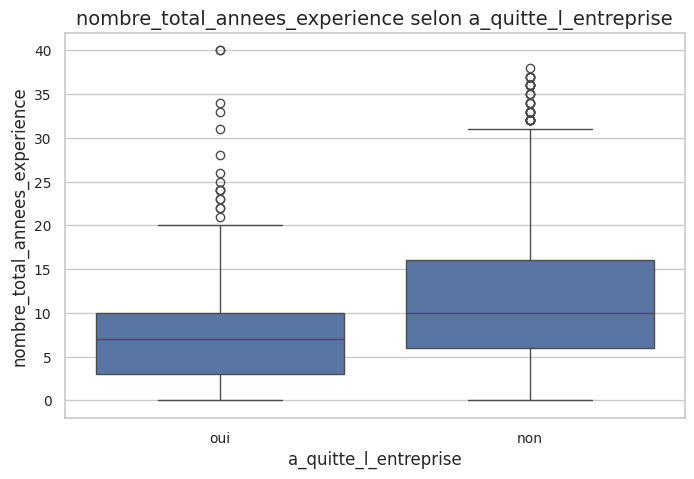

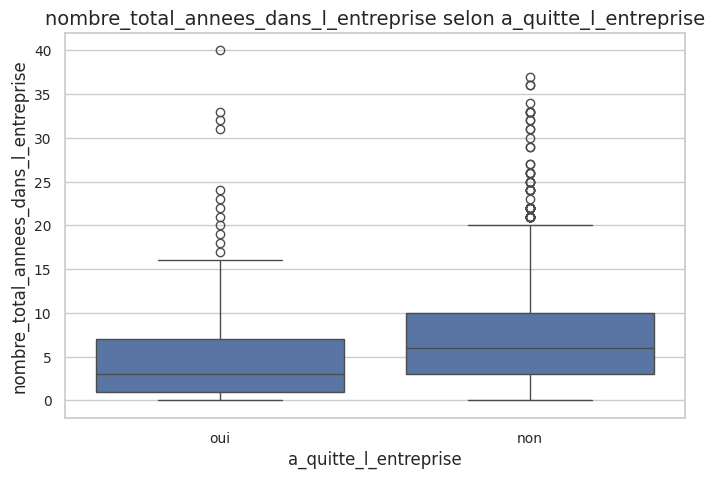

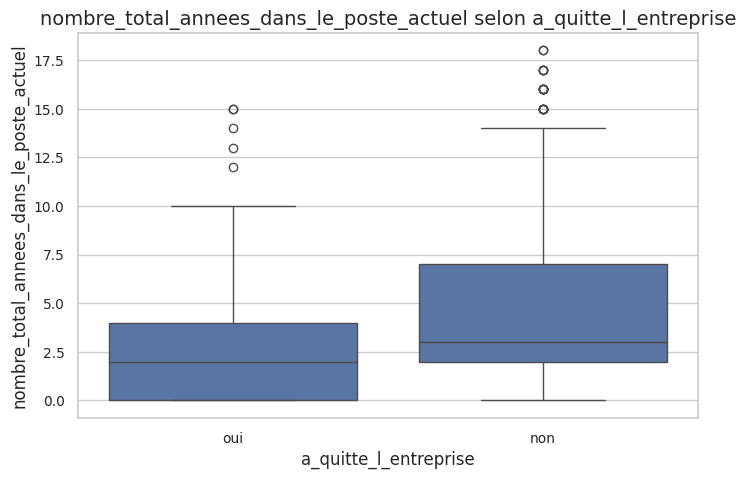

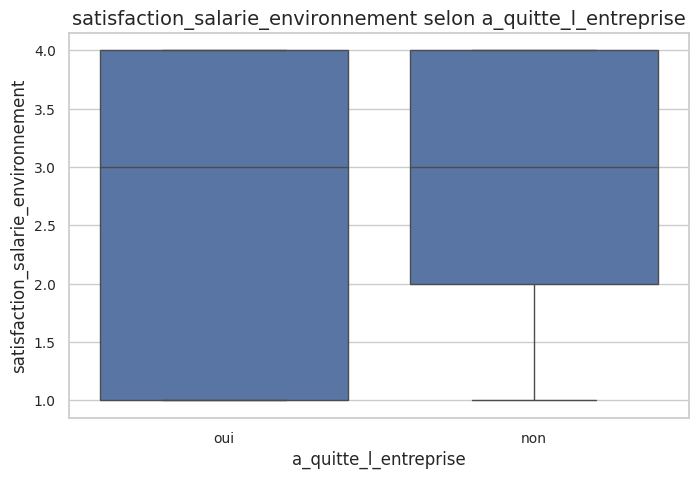

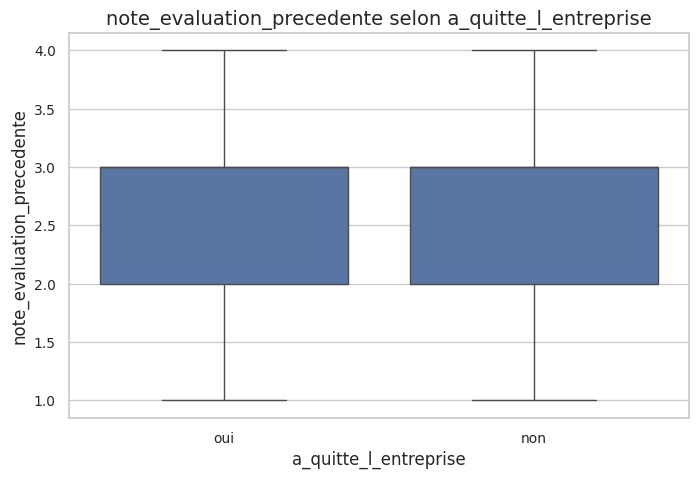

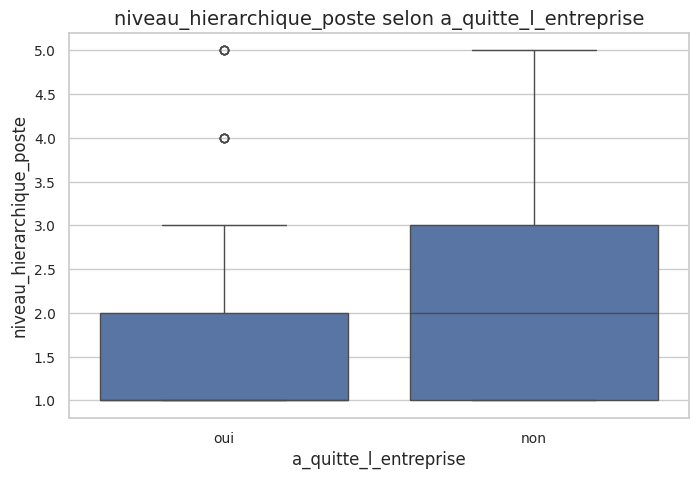

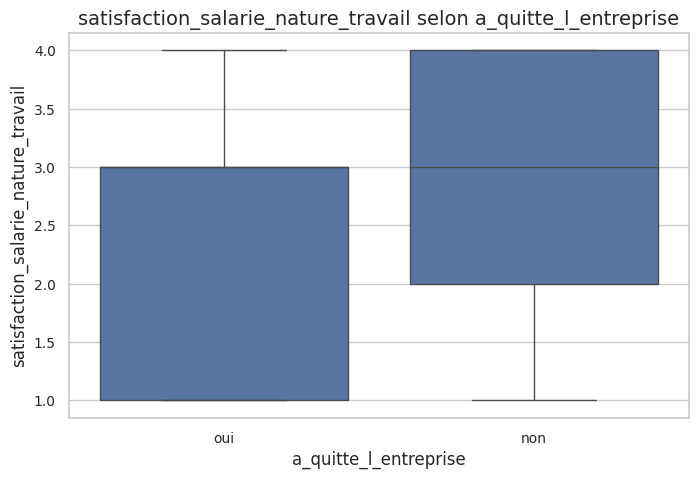

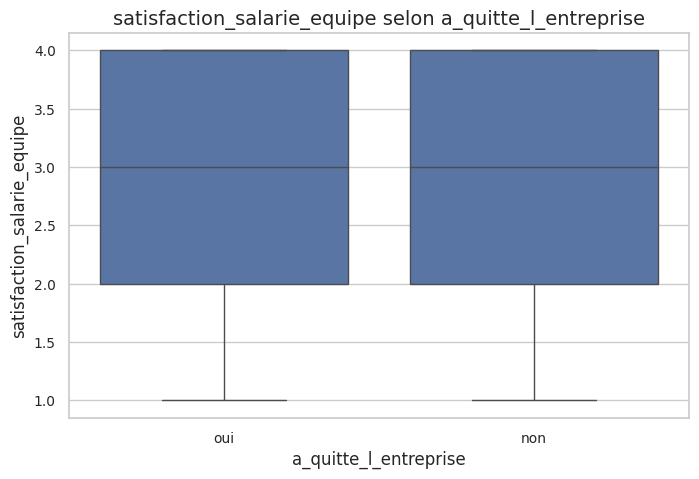

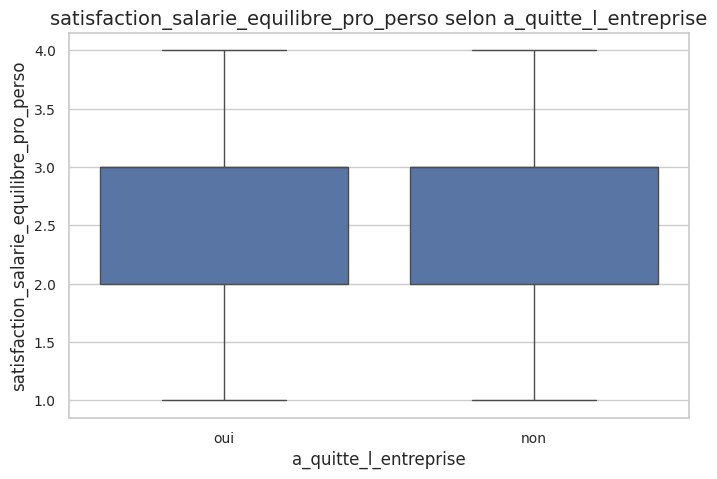

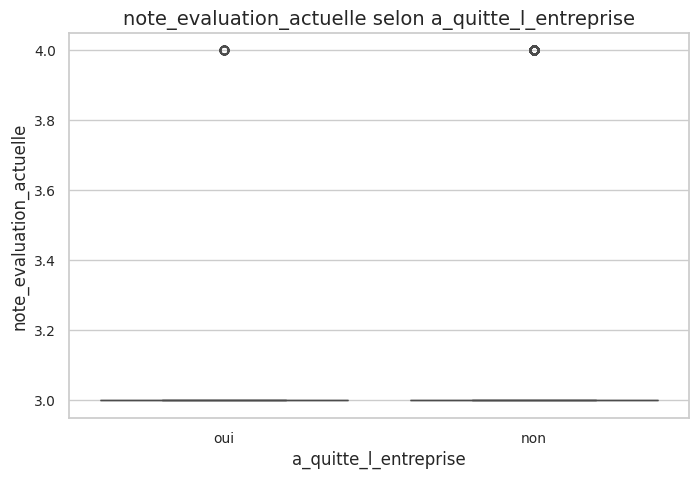

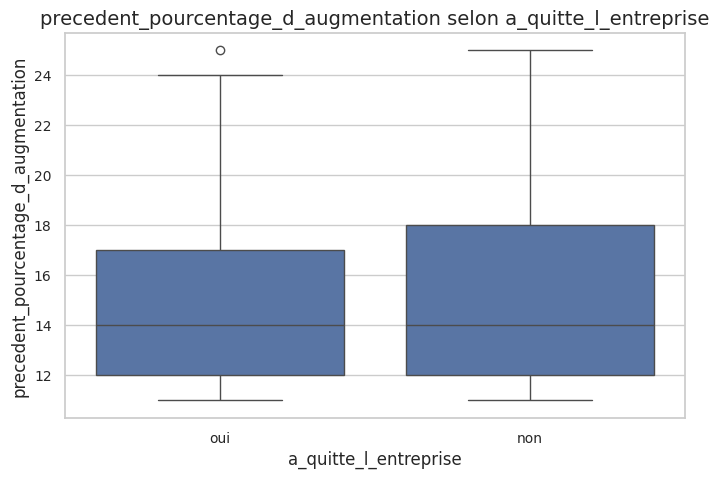

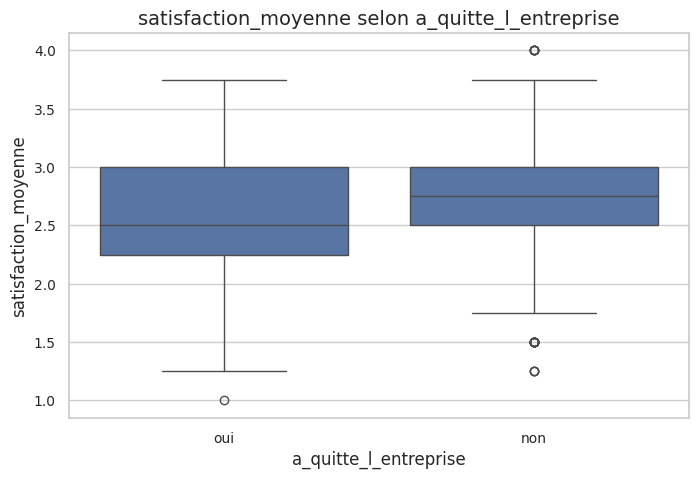

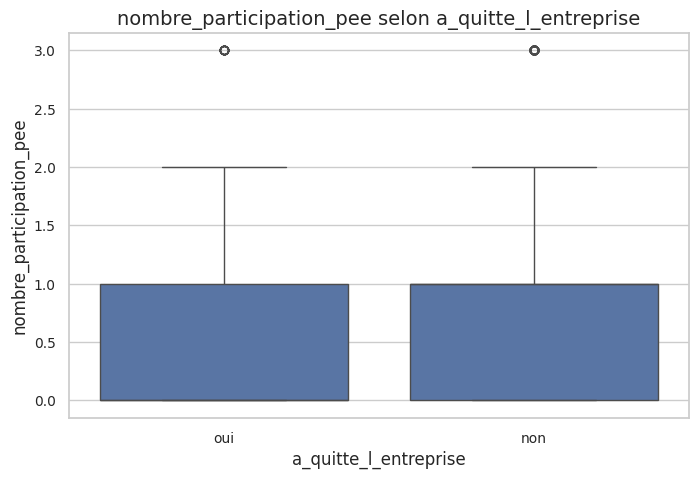

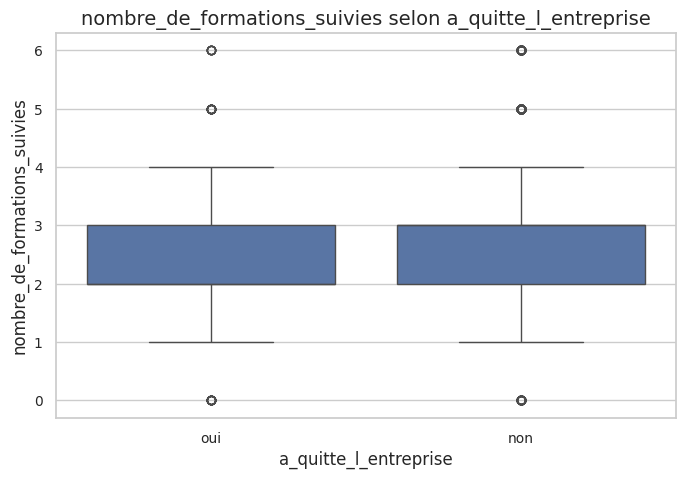

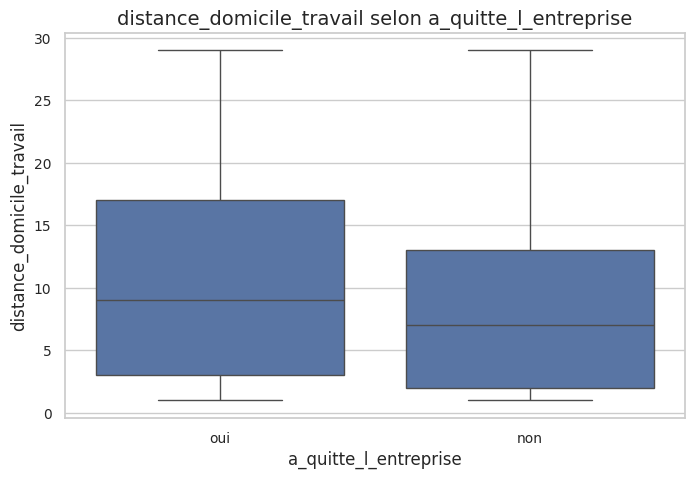

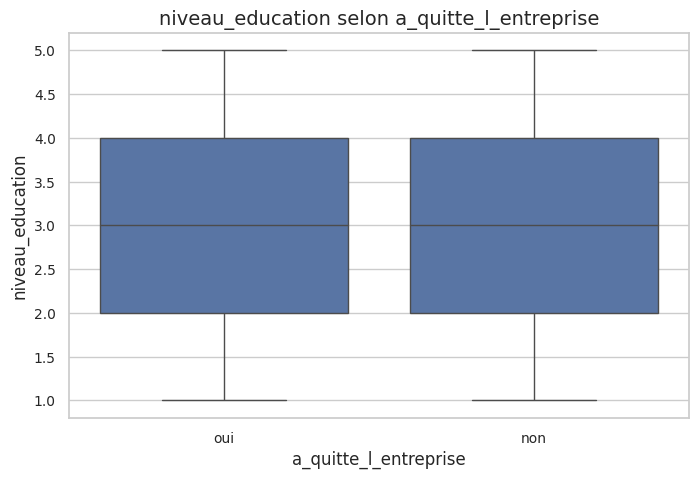

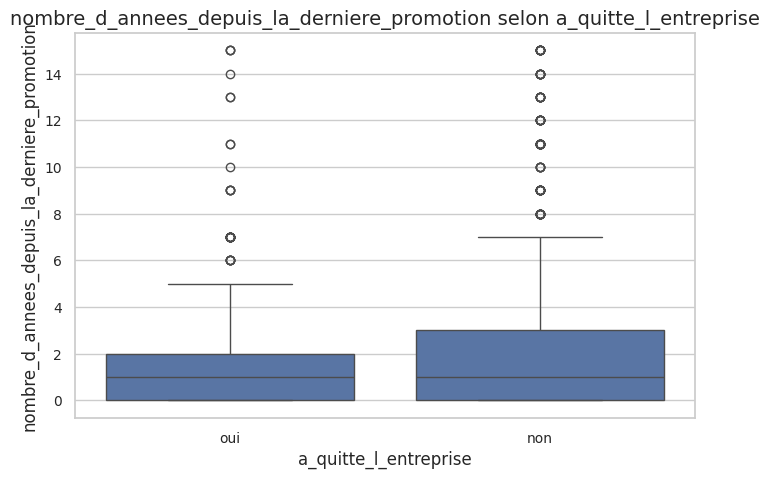

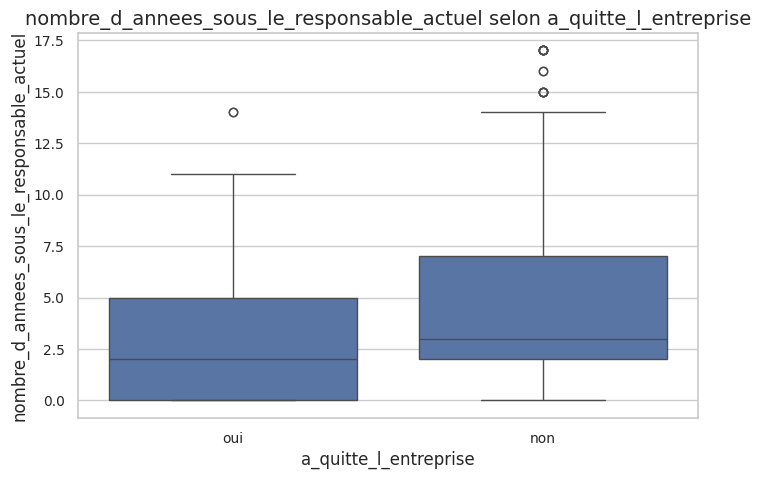

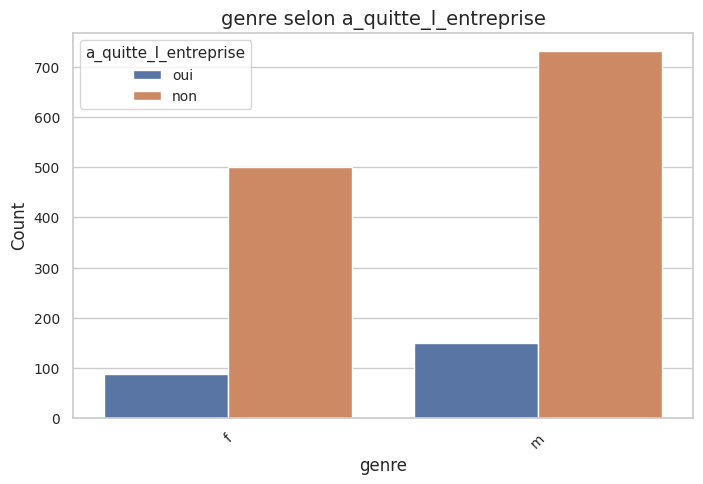

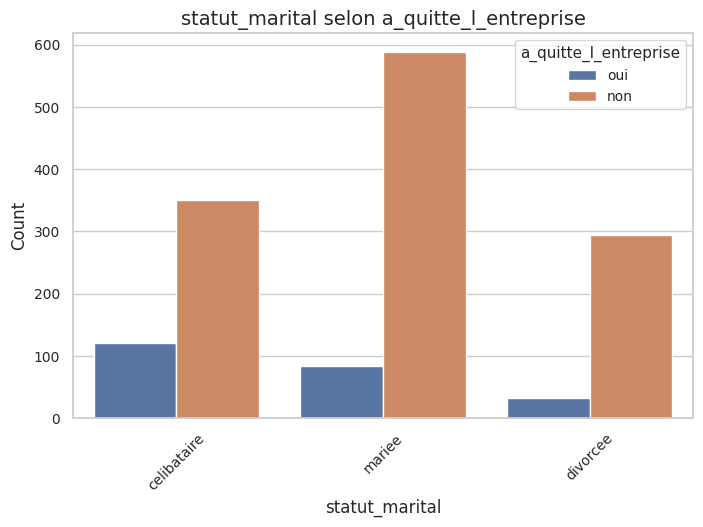

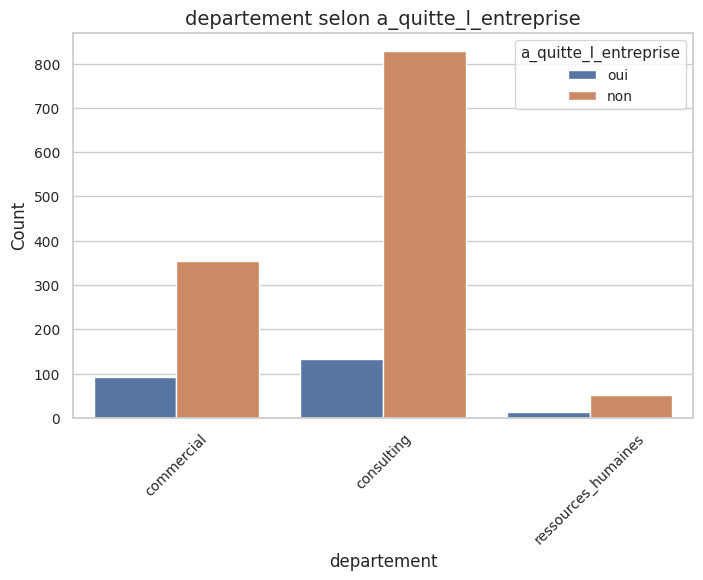

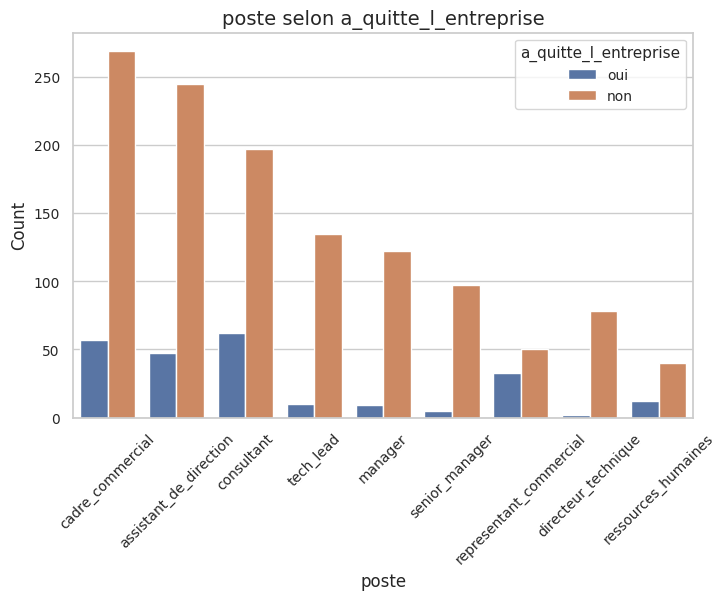

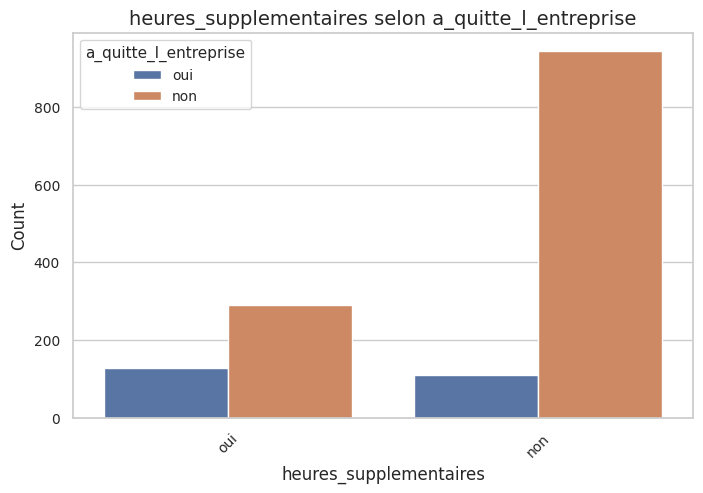

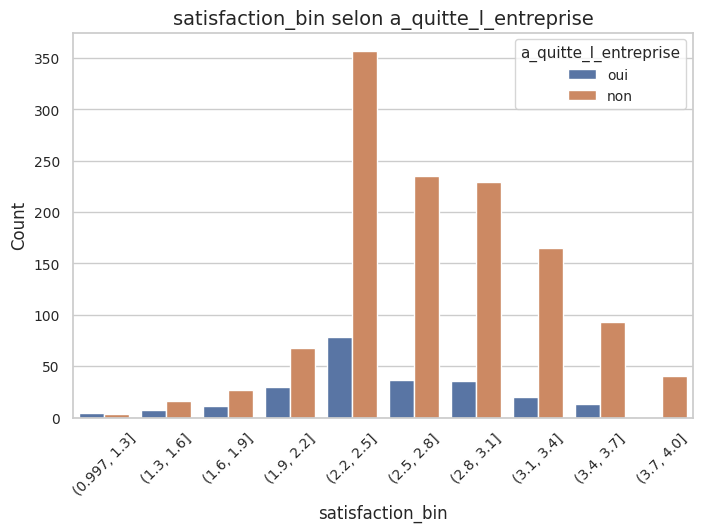

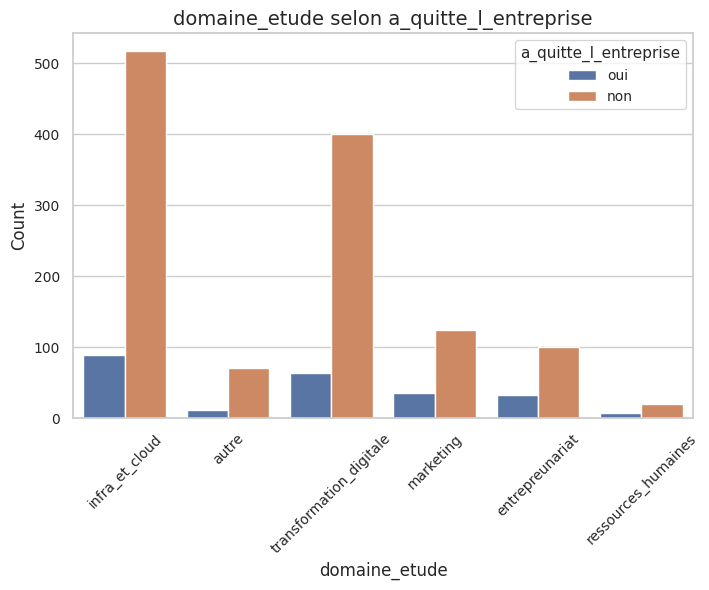

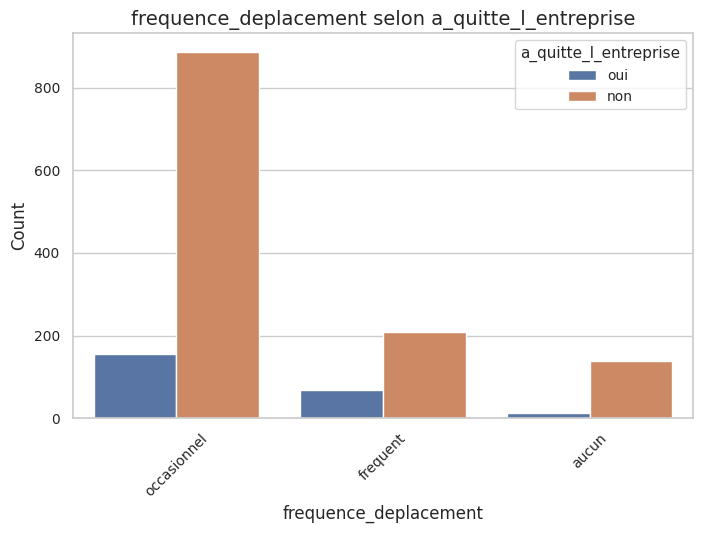

In [194]:
# EDA bivariée

# Détecter colonnes numériques et catégorielles automatiquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_joint.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# On enlève la cible et l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]
cat_cols = [col for col in cat_cols if col not in ["id", "a_quitte_l_entreprise"]]

# Lancer l'EDA bivariée
eda_bivariee(df_joint, target_col="a_quitte_l_entreprise", num_cols=num_cols, cat_cols=cat_cols)

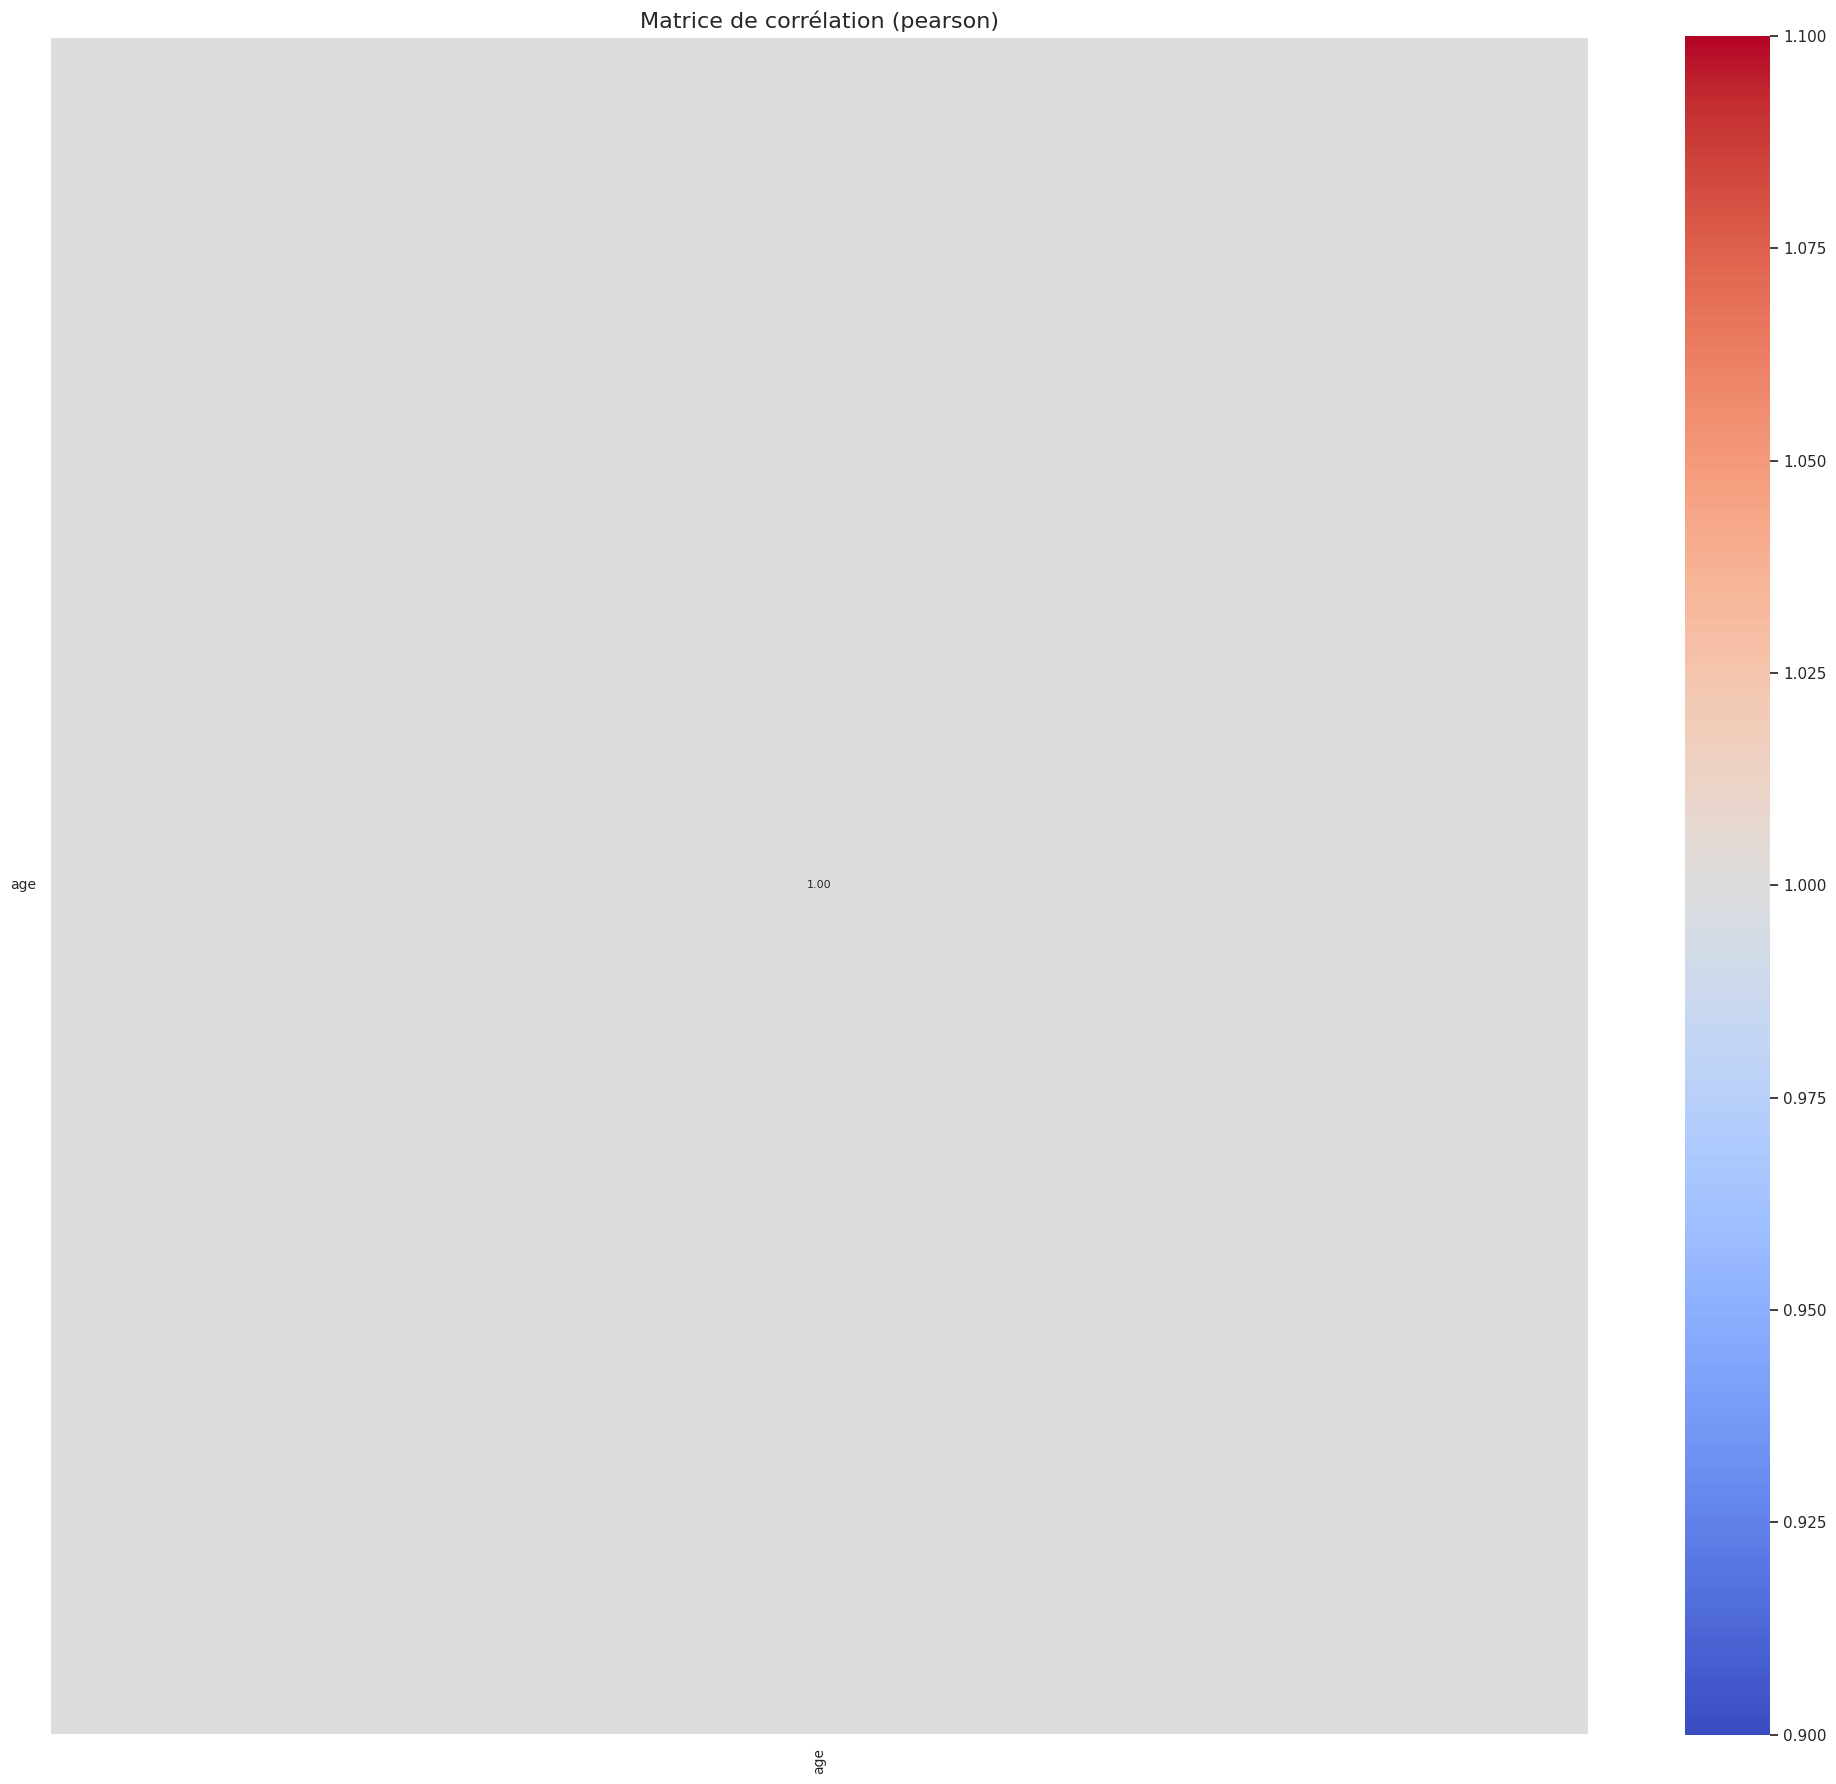

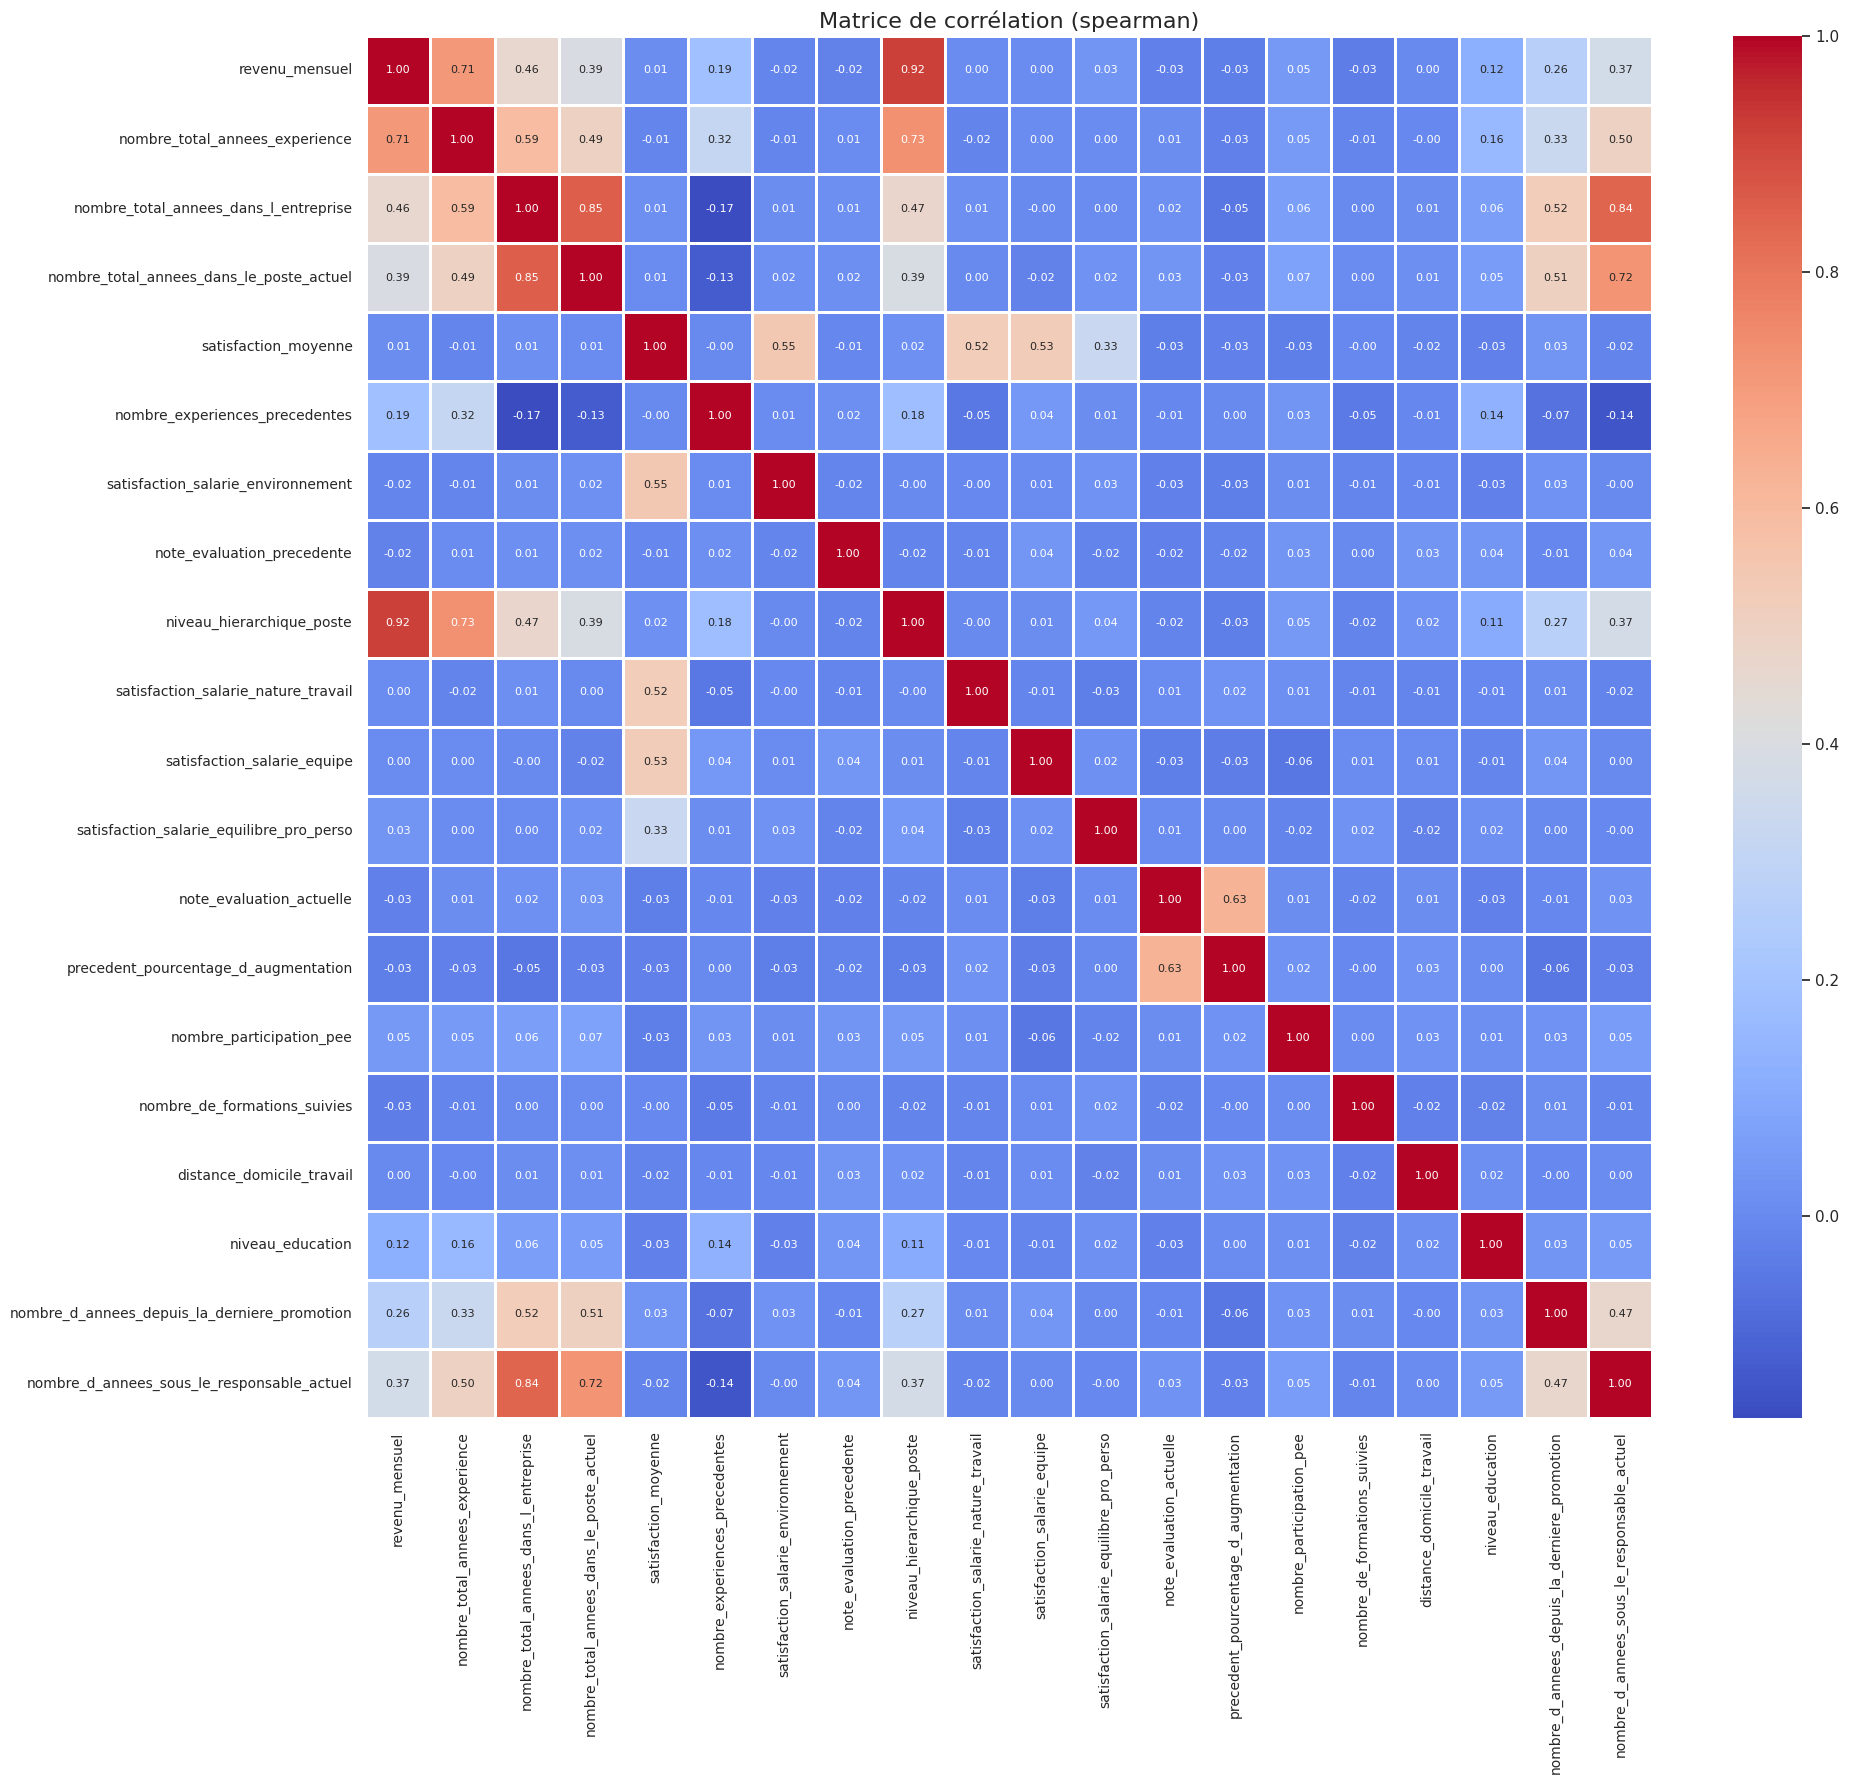

In [195]:
# Pearson pour variables continues/normales
correlation_heatmap(df_joint, method="pearson")

# Spearman pour variables discrètes/non normales
correlation_heatmap(df_joint, method="spearman")

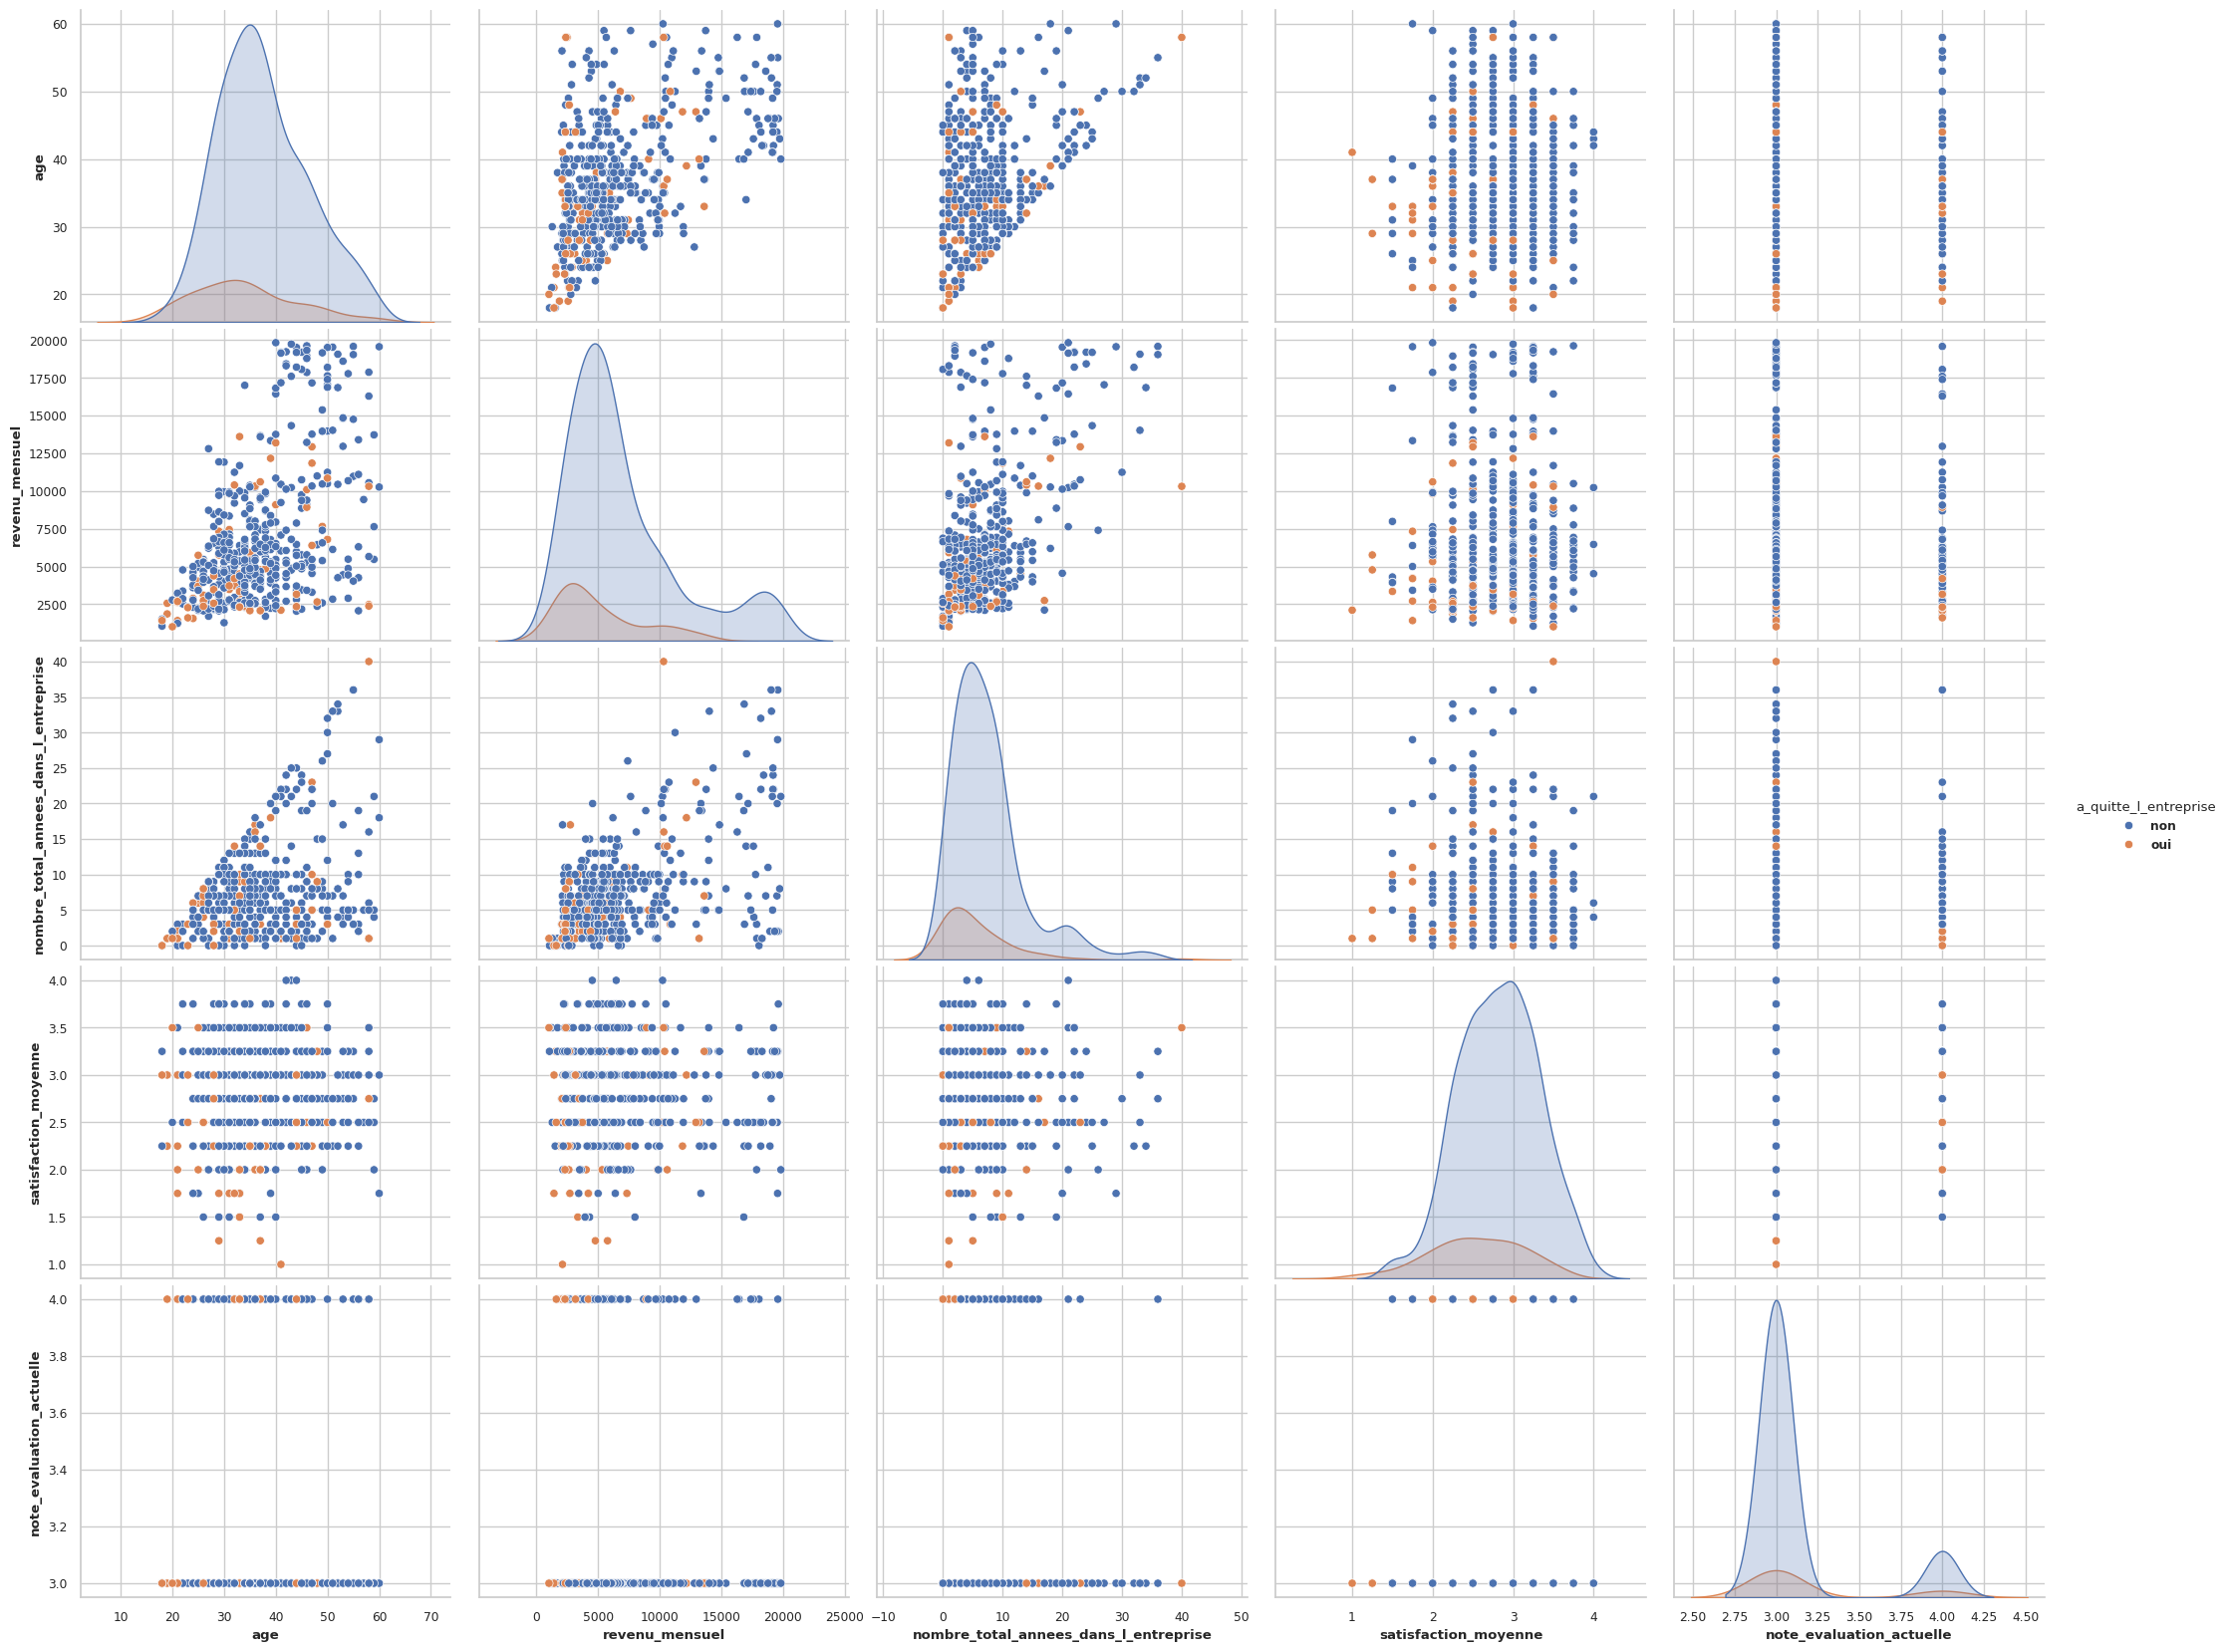

In [196]:
# Pairplot pour les variables clés

# Choisir les variables numériques les plus pertinentes
selected_cols = [
    "age", 
    "revenu_mensuel",
    "nombre_total_annees_dans_l_entreprise",
    "satisfaction_moyenne",
    "note_evaluation_actuelle"
]

pairplot_sample(df_joint, cols=selected_cols, target_col="a_quitte_l_entreprise", sample_size=500)

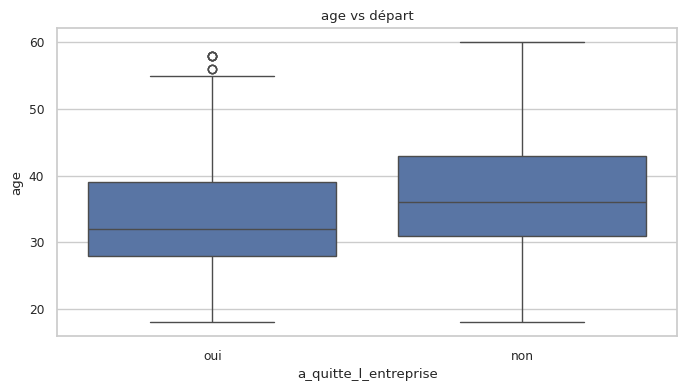

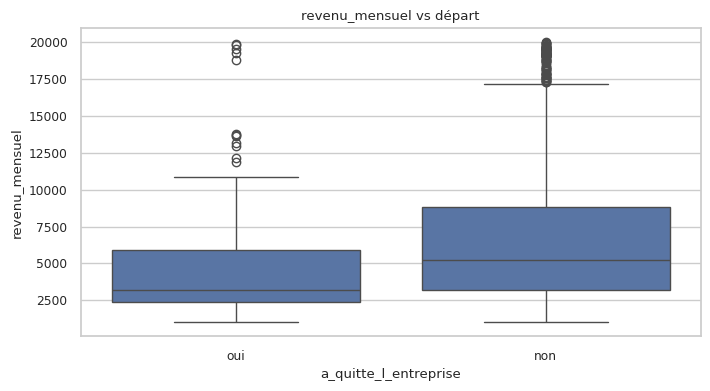

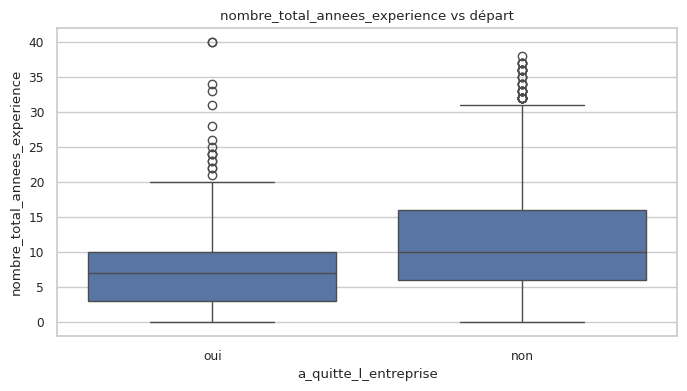

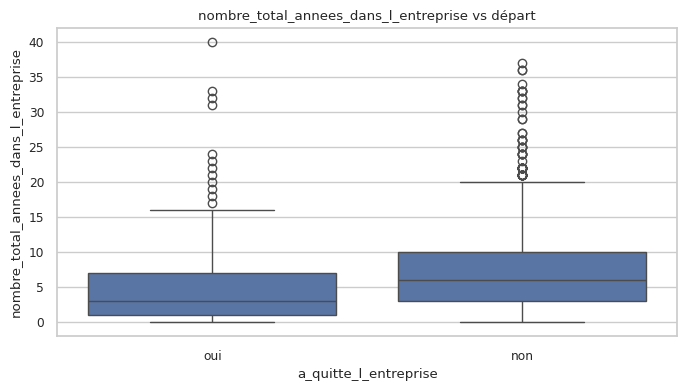

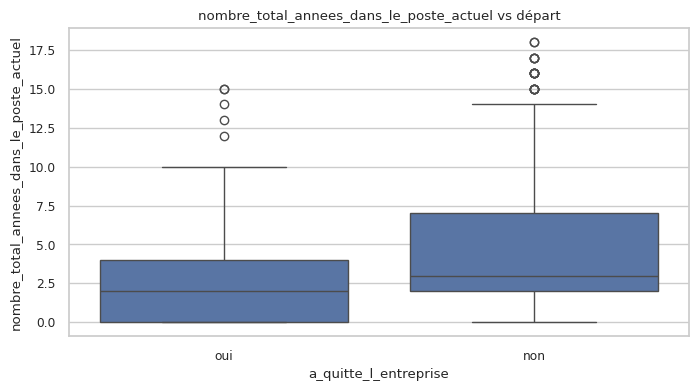

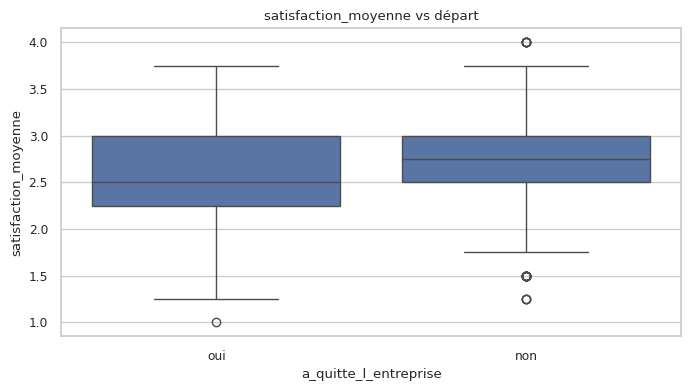

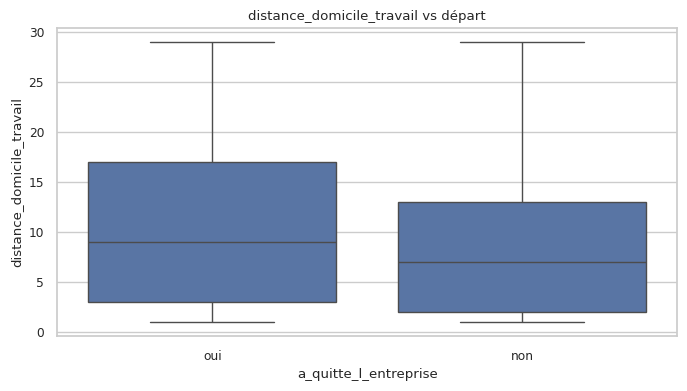

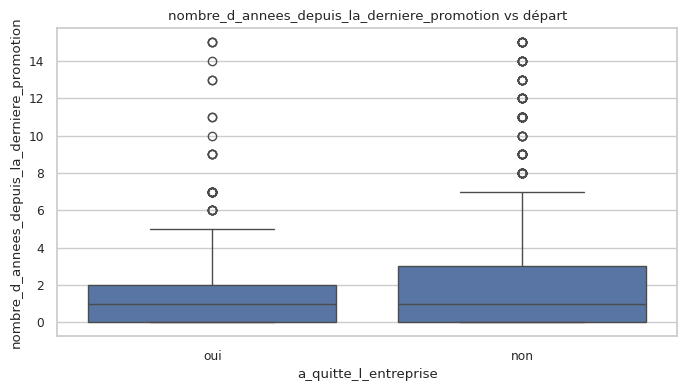

In [197]:
# Visualisations variable cible en fonction des variables numériques
num_cols = [
    "age", "revenu_mensuel", "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "satisfaction_moyenne",
    "distance_domicile_travail",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

for col in num_cols:
    sns.boxplot(x="a_quitte_l_entreprise", y=col, data=df_joint)
    plt.title(f"{col} vs départ")
    plt.show()

In [198]:
# Mesurer la dispersion des valeurs et détecter les outliers avec la statistique descriptive IQR

print(f"{'Variable':40} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Min_IQR':>10} {'Max_IQR':>10} {'Outliers':>10}")
print("-" * 100)

for col in num_cols:
    Q1 = df_joint[col].quantile(0.25)
    Q3 = df_joint[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_joint[
        (df_joint[col] < lower) | 
        (df_joint[col] > upper)
    ]

    print(f"{col:40} {Q1:8.2f} {Q3:8.2f} {IQR:8.2f} {lower:10.2f} {upper:10.2f} {len(outliers):10}")

Variable                                       Q1       Q3      IQR    Min_IQR    Max_IQR   Outliers
----------------------------------------------------------------------------------------------------
age                                         30.00    43.00    13.00      10.50      62.50          0
revenu_mensuel                            2911.00  8379.00  5468.00   -5291.00   16581.00        114
nombre_total_annees_experience               6.00    15.00     9.00      -7.50      28.50         63
nombre_total_annees_dans_l_entreprise        3.00     9.00     6.00      -6.00      18.00        104
nombre_total_annees_dans_le_poste_actuel     2.00     7.00     5.00      -5.50      14.50         21
satisfaction_moyenne                         2.50     3.00     0.50       1.75       3.75         36
distance_domicile_travail                    2.00    14.00    12.00     -16.00      32.00          0
nombre_d_annees_depuis_la_derniere_promotion     0.00     3.00     3.00      -4.50       7.

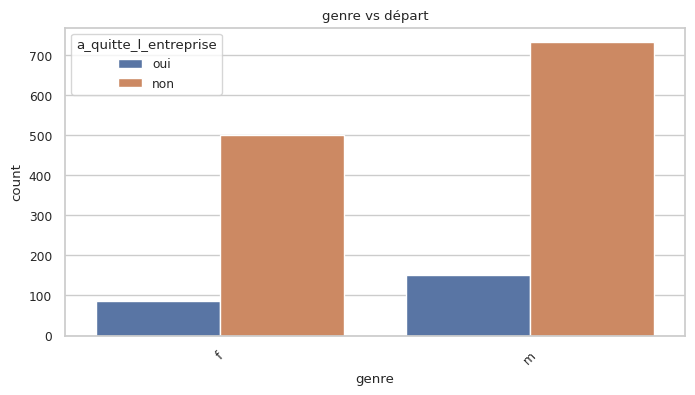

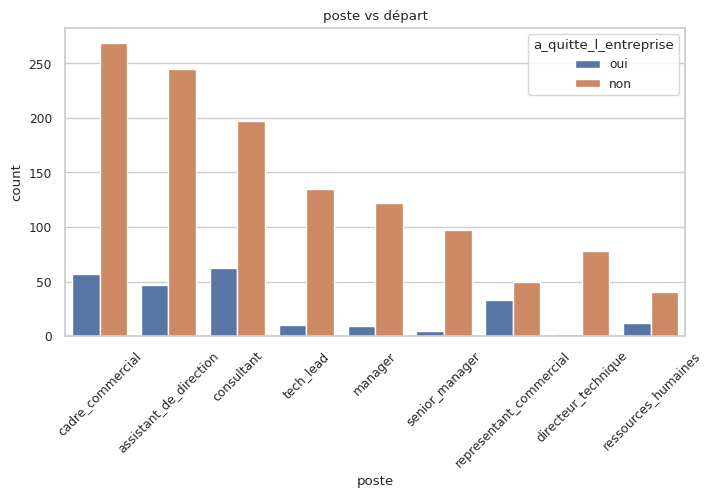

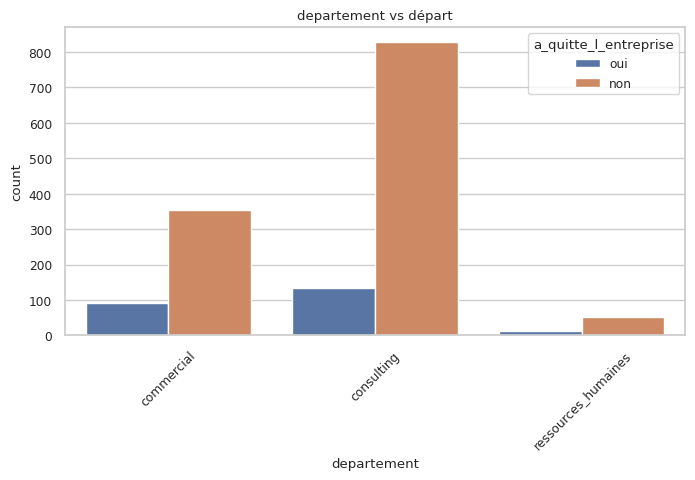

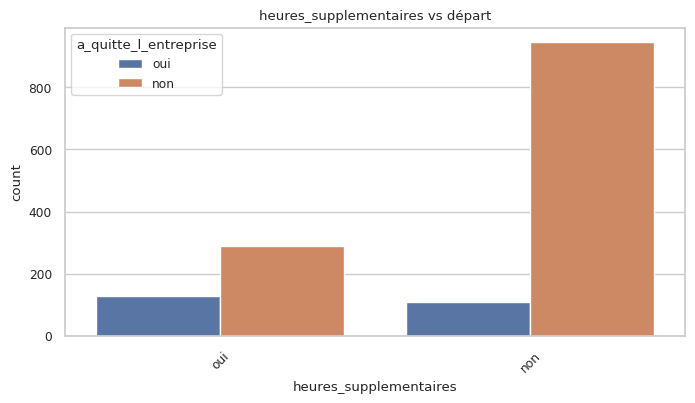

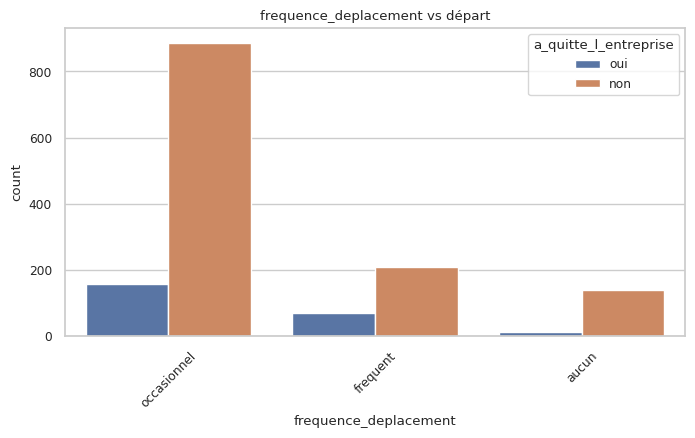

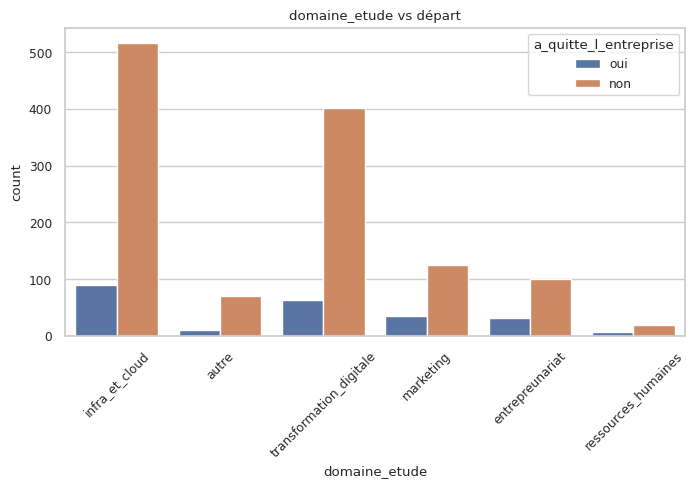

In [199]:
# Visualisations variables catégorielles versus la target
cat_cols = [
    "genre", "poste", "departement",
    "heures_supplementaires",
    "frequence_deplacement",
    "domaine_etude"
]

for col in cat_cols:
    sns.countplot(data=df_joint, x=col, hue="a_quitte_l_entreprise")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs départ")
    plt.show()

In [200]:
# Afichage numérique variables catégorielles versus la target
for col in cat_cols:
    print("\n" + "="*70)
    print(f"Variable : {col}")
    print("="*70)

    # tableau croisé (effectifs)
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])

    # pourcentages par ligne
    table_pct = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    ) * 100

    # affichage combiné
    for category in table.index:
        print(f"\n {col} = {category}")
        
        for target in table.columns:
            count = table.loc[category, target]
            pct = table_pct.loc[category, target]

            print(f"   {target:<10} : {count:4} ({pct:5.1f}%)")


Variable : genre

 genre = f
   non        :  501 ( 85.2%)
   oui        :   87 ( 14.8%)

 genre = m
   non        :  732 ( 83.0%)
   oui        :  150 ( 17.0%)

Variable : poste

 poste = assistant_de_direction
   non        :  245 ( 83.9%)
   oui        :   47 ( 16.1%)

 poste = cadre_commercial
   non        :  269 ( 82.5%)
   oui        :   57 ( 17.5%)

 poste = consultant
   non        :  197 ( 76.1%)
   oui        :   62 ( 23.9%)

 poste = directeur_technique
   non        :   78 ( 97.5%)
   oui        :    2 (  2.5%)

 poste = manager
   non        :  122 ( 93.1%)
   oui        :    9 (  6.9%)

 poste = representant_commercial
   non        :   50 ( 60.2%)
   oui        :   33 ( 39.8%)

 poste = ressources_humaines
   non        :   40 ( 76.9%)
   oui        :   12 ( 23.1%)

 poste = senior_manager
   non        :   97 ( 95.1%)
   oui        :    5 (  4.9%)

 poste = tech_lead
   non        :  135 ( 93.1%)
   oui        :   10 (  6.9%)

Variable : departement

 departement = co

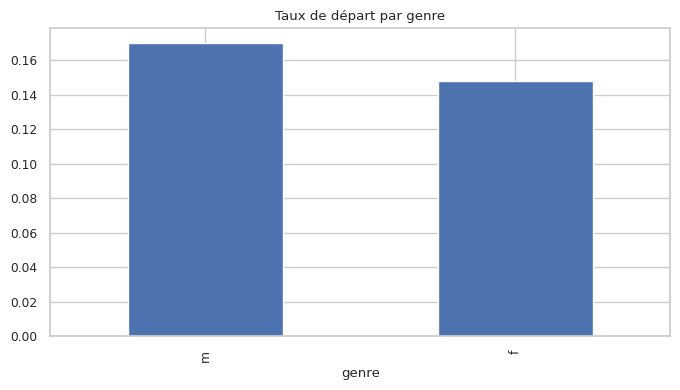

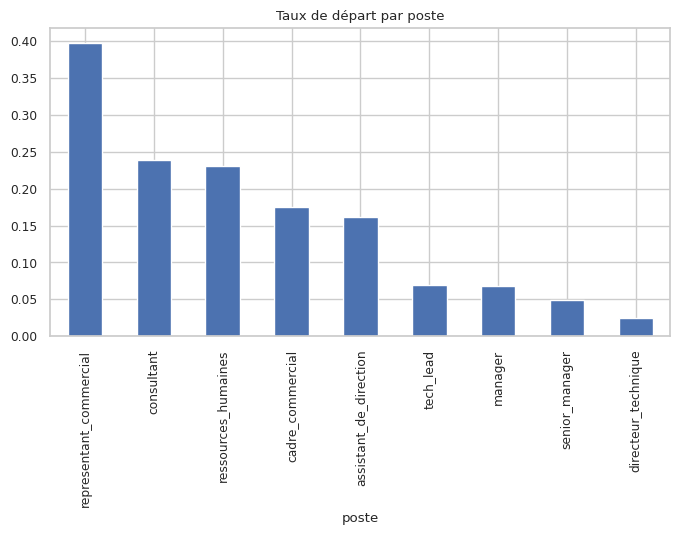

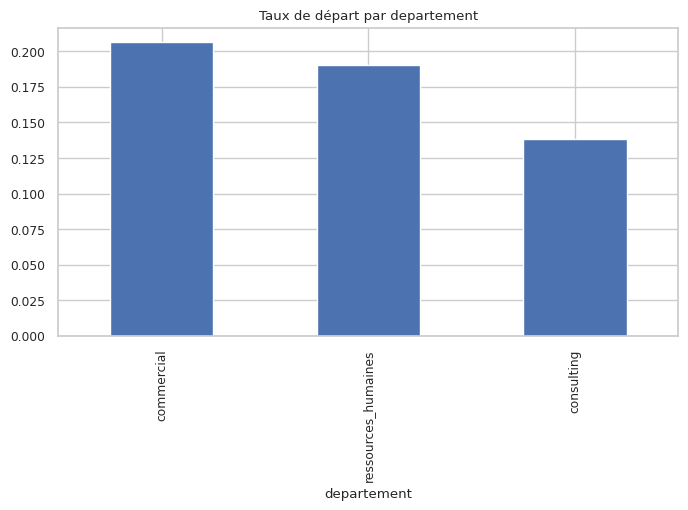

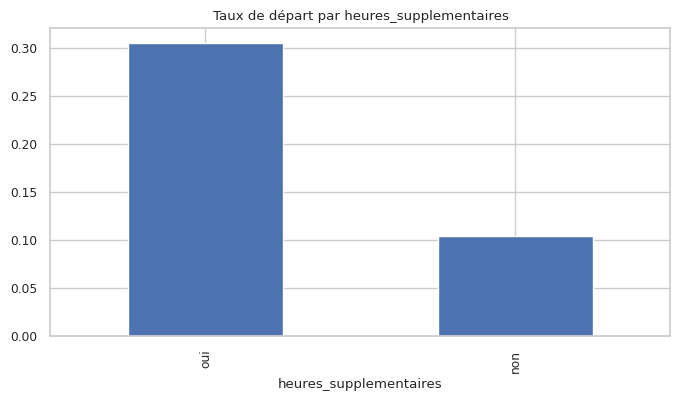

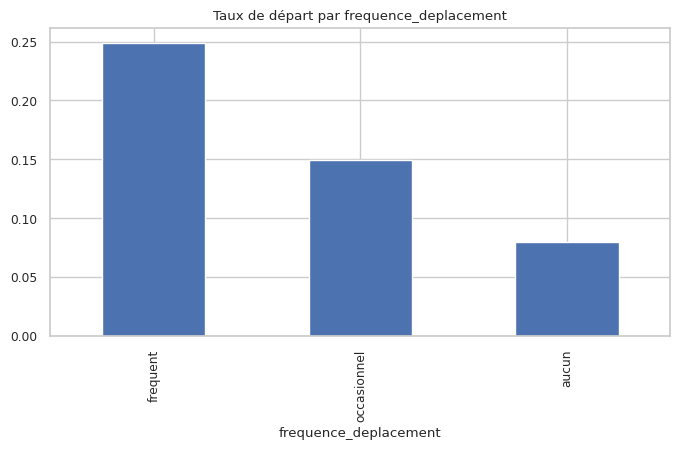

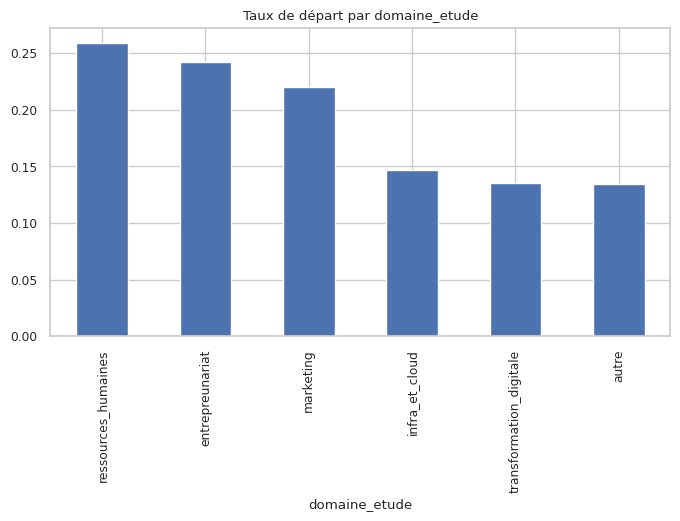

In [201]:
# Identification des taux de départ par catégorie

for col in cat_cols:
    taux = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"], normalize="index")
    taux["oui"].sort_values(ascending=False).plot(kind="bar")
    plt.title(f"Taux de départ par {col}")
    plt.show()

In [202]:
# Affichage numérique des taux de départs par catégorie

for col in cat_cols:
    print("\n" + "="*70)
    print(f"Taux de départ par {col}")
    print("="*70)

    # calcul taux de départ
    taux = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    )

    # tri décroissant sur "oui"
    taux_sorted = taux["oui"].sort_values(ascending=False)

    # affichage
    for category, value in taux_sorted.items():
        print(f"{category:<30} : {value*100:5.1f}%")


Taux de départ par genre
m                              :  17.0%
f                              :  14.8%

Taux de départ par poste
representant_commercial        :  39.8%
consultant                     :  23.9%
ressources_humaines            :  23.1%
cadre_commercial               :  17.5%
assistant_de_direction         :  16.1%
tech_lead                      :   6.9%
manager                        :   6.9%
senior_manager                 :   4.9%
directeur_technique            :   2.5%

Taux de départ par departement
commercial                     :  20.6%
ressources_humaines            :  19.0%
consulting                     :  13.8%

Taux de départ par heures_supplementaires
oui                            :  30.5%
non                            :  10.4%

Taux de départ par frequence_deplacement
frequent                       :  24.9%
occasionnel                    :  15.0%
aucun                          :   8.0%

Taux de départ par domaine_etude
ressources_humaines            :  25.

In [203]:
# Tests de statistiques inférentielles
# si p < 0.05 alors variable significative

from scipy.stats import ttest_ind

group1 = df_joint[df_joint["a_quitte_l_entreprise"] == "oui"]
group0 = df_joint[df_joint["a_quitte_l_entreprise"] == "non"]

for col in num_cols:
    stat, p = ttest_ind(group1[col], group0[col])
    print(col, "p-value:", p)

age p-value: 8.356308021103588e-10
revenu_mensuel p-value: 7.147363985353823e-10
nombre_total_annees_experience p-value: 4.061878111266856e-11
nombre_total_annees_dans_l_entreprise p-value: 2.3188716103862972e-07
nombre_total_annees_dans_le_poste_actuel p-value: 6.003185843641391e-10
satisfaction_moyenne p-value: 8.59252198159284e-10
distance_domicile_travail p-value: 0.0027930600802134322
nombre_d_annees_depuis_la_derniere_promotion p-value: 0.20578995916249362


In [204]:
# Test de Mann wHitney
cols_mw = [
            
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel",
            "precedent_pourcentage_d_augmentation"
]


from scipy.stats import mannwhitneyu

alpha = 0.05

for col in cols_mw:
    stat, p = mannwhitneyu(group1[col], group0[col], alternative="two-sided")

    if p < alpha:
        conclusion = "Différence significative"
    else:
        conclusion = "Pas de différence"

    print(f"{col:50} p-value = {p:.5f} → {conclusion}")


revenu_mensuel                                     p-value = 0.00000 → Différence significative
nombre_total_annees_experience                     p-value = 0.00000 → Différence significative
nombre_total_annees_dans_l_entreprise              p-value = 0.00000 → Différence significative
nombre_total_annees_dans_le_poste_actuel           p-value = 0.00000 → Différence significative
satisfaction_moyenne                               p-value = 0.00000 → Différence significative
nombre_experiences_precedentes                     p-value = 0.24237 → Pas de différence
satisfaction_salarie_environnement                 p-value = 0.00022 → Différence significative
note_evaluation_precedente                         p-value = 0.00000 → Différence significative
niveau_hierarchique_poste                          p-value = 0.00000 → Différence significative
satisfaction_salarie_nature_travail                p-value = 0.00008 → Différence significative
satisfaction_salarie_equipe                    

In [205]:
# Test du Khi2
from scipy.stats import chi2_contingency

for col in cat_cols:
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])
    stat, p, _, _ = chi2_contingency(table)
    print(col, "p-value:", p)

genre p-value: 0.29057244902890855
poste p-value: 2.752481638050678e-15
departement p-value: 0.004525606574479633
heures_supplementaires p-value: 8.15842372153832e-21
frequence_deplacement p-value: 5.608614476449931e-06
domaine_etude p-value: 0.006773980139025212


#### observations:

- Les variables les plus discriminantes sont liées à **ancienneté, expérience, revenu, satisfaction et formation** **(p-values très faibles (~0 ou 1e-10)**)
- Les variables moins discriminantes ou non significatives : **nombre d’expériences précédentes** **(p-values ~ 0.242 > 0.05)**, **satisfaction équipe, note d’évaluation actuelle, niveau d’éducation**.
- Les variables catégorielles les plus discriminantes : **poste** **(p-values ~ 2.75e-15)**, **heures supplémentaires** **(p-values ~ 8.16e-21)**, **fréquence de déplacement** **(p-values ~ 5.6e-6)**.
- Les segments moins discriminants : **genre**.
- Les postes à forte rotation : représentant commercial, consultant, RH.
- **Les salariés effectuant des heures supplémentaires ou ayant une fréquence de déplacement élevée ont un risque de départ plus élevé**.
- **Les salariés issus de domaines d’étude RH, entrepreneuriat ou marketing sont plus susceptibles de quitter l’entreprise**.
- **Segments à risque:**
  -  **Postes à forte rotation** : représentant commercial, consultant, RH → ces segments sont explicitement identifiés comme plus à risque.
  -  **Comportements à risque** : salariés effectuant des heures supplémentaires ou avec une fréquence de déplacement élevée.
  -  **Domaines d’étude à risque** : RH, entrepreneuriat, marketing → segment ciblé pour le risque de départ
- Multicolinéarité probable dans :
  - Ancienneté, expérience, poste actuel, sous responsable, revenu et niveau hiérarchique.
  -  Si ces variables sont utilisées ensemble dans un modèle linéaire (ex : régression logistique), les coefficients peuvent devenir instables.
- Solution / feature engineering :
  - **Créer des features composites ou ratios pour réduire la redondance** :
    - ratio_experience_salaire = revenu_mensuel / nombre_total_annees_experience
    - anciennete_relative = nombre_total_annees_dans_le_poste_actuel / nombre_total_annees_dans_l_entreprise
    - anciennete_sous_responsable = nombre_d_annees_sous_le_responsable_actuel / nombre_total_annees_dans_le_poste_actuel
    - niveau_poste_vs_revenu = revenu_mensuel / niveau_hierarchique_poste (pour capturer la sur/sous-rémunération par niveau)
    - éviter d’inclure directement toutes les variables corrélées si modèle linéaire.
  - **Variables moins problématiques** :
    - Satisfaction moyenne,
    - distance domicile-travail,
    - formations suivies
    - corrélation modérée ou faible, peuvent rester telles quelles.


In [206]:
# Feature engineering et préparation pour la modélisation 
import pandas as pd
import numpy as np

# Suppression des colonnes inutiles

drop_cols = [
    "id",
    "nombre_d_annees_sous_le_responsable_actuel",
    "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "revenu_mensuel"
]

# Création d'un dataframe résultant pour les étapes suivantes de modélisation

df_mod = df_joint.drop(columns=drop_cols)

# Variables numériques dérivées

df_mod["ratio_salaire_experience"] = df_joint["revenu_mensuel"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_ratio"] = df_joint["nombre_total_annees_dans_l_entreprise"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_sous_responsable_ratio"] = df_joint["nombre_d_annees_sous_le_responsable_actuel"] / \
                                              (df_joint["nombre_total_annees_dans_le_poste_actuel"] + 1)
df_mod["niveau_poste_vs_revenu"] = df_joint["revenu_mensuel"] / (df_joint["niveau_hierarchique_poste"] + 1e-6)  # éviter div par 0

# Features comportementales / à risque

df_mod["stagnation"] = (df_joint["nombre_d_annees_depuis_la_derniere_promotion"] > 3).astype(int)
df_mod["stress"] = ((df_joint["heures_supplementaires"] == "oui") & (df_joint["satisfaction_moyenne"] < 3)).astype(int)
df_mod["mobilite"] = (df_joint["frequence_deplacement"] != "aucun").astype(int)
df_mod["low_satisfaction"] = (df_joint["satisfaction_moyenne"] < 2.5).astype(int)


# Encodage des variables catégorielles

def encode_categorical(df, col, threshold_low=0.05, threshold_high=0.8):
    """
    Encode les variables catégorielles :
    - Modalités < threshold_low → 'other'
    - Modalités > threshold_high → binaire majoritaire
    - Sinon one-hot
    """
    total = len(df)
    counts = df[col].value_counts(normalize=True)
    
    # Regrouper les modalités rares
    rare = counts[counts < threshold_low].index
    df[col] = df[col].replace(rare, "other")
    
    # Identifier la modalité majoritaire si > threshold_high
    major = counts[counts > threshold_high].index
    if len(major) == 1:
        # Créer un binaire pour majoritaire
        df[col + "_major"] = (df[col] == major[0]).astype(int)
        # Supprimer la colonne originale
        df = df.drop(columns=[col])
    else:
        # One-hot pour les autres variables
        df = pd.get_dummies(df, columns=[col], prefix=col)
    
    return df

# Colonnes catégorielles

categorical_cols = [
    "poste",
    "departement",
    "domaine_etude",
    "genre",
    "heures_supplementaires",
    "frequence_deplacement",
    "niveau_education"
]

for col in categorical_cols:
    df_mod = encode_categorical(df_mod, col)


# Sélection des features finales

numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

# Toutes les colonnes restantes après encodage des variables catégorielles sont gardées comme features

final_features = numeric_features + behavioral_features + \
                 [c for c in df_mod.columns if c not in numeric_features + behavioral_features + ["a_quitte_l_entreprise"]]


# Préparer X et y pour modélisation

X = df_mod[final_features]
y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})  # encode binaire

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
print("Features finales :", X.columns.tolist())

Shape de X : (1470, 55)
Shape de y : (1470,)
Features finales : ['satisfaction_moyenne', 'ratio_salaire_experience', 'anciennete_ratio', 'anciennete_sous_responsable_ratio', 'niveau_poste_vs_revenu', 'distance_domicile_travail', 'nombre_de_formations_suivies', 'nombre_d_annees_depuis_la_derniere_promotion', 'stagnation', 'stress', 'mobilite', 'low_satisfaction', 'age', 'statut_marital', 'nombre_experiences_precedentes', 'satisfaction_salarie_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail', 'satisfaction_salarie_equipe', 'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle', 'precedent_pourcentage_d_augmentation', 'satisfaction_bin', 'nombre_participation_pee', 'poste_assistant_de_direction', 'poste_cadre_commercial', 'poste_consultant', 'poste_directeur_technique', 'poste_manager', 'poste_other', 'poste_representant_commercial', 'poste_senior_manager', 'poste_tech_lead', 'departement_commercial', 'departe

In [207]:
df_mod.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 56 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   age                                           1470 non-null   int64   
 1   statut_marital                                1470 non-null   str     
 2   nombre_experiences_precedentes                1470 non-null   int64   
 3   satisfaction_salarie_environnement            1470 non-null   int64   
 4   note_evaluation_precedente                    1470 non-null   int64   
 5   niveau_hierarchique_poste                     1470 non-null   int64   
 6   satisfaction_salarie_nature_travail           1470 non-null   int64   
 7   satisfaction_salarie_equipe                   1470 non-null   int64   
 8   satisfaction_salarie_equilibre_pro_perso      1470 non-null   int64   
 9   note_evaluation_actuelle                      1470 non-null   i

#### Features et target finales pour la modélisation 

Les features finales sont :

**a) Numériques dérivées / calculées**
- satisfaction_moyenne
- ratio_salaire_experience (revenu / expérience)
- anciennete_ratio (ancienneté / expérience)
- anciennete_sous_responsable_ratio (ancienneté sous responsable / ancienneté poste)
- niveau_poste_vs_revenu (revenu / niveau hiérarchique)
- distance_domicile_travail
- nombre_de_formations_suivies
- nombre_d_annees_depuis_la_derniere_promotion

**b) Features comportementales / à risque**
- stagnation (plus de 3 ans depuis dernière promotion)
- stress (heures sup + faible satisfaction)
- mobilite (fréquence déplacement ≠ aucun)
- low_satisfaction (satisfaction < 2.5)

**c) Features catégorielles encodées**
- Toutes les colonnes restantes après l’encodage des variables catégorielles avec encode_categorical :
- poste_* (one-hot ou binaire majoritaire)
- departement_*
- domaine_etude_*
- genre_*
- heures_supplementaires_*
- frequence_deplacement_*
- niveau_education_*

Ces features couvrent numérique, comportemental et catégoriel, ce qui est complet pour la prédiction de départ.

**d) Target utilisée pour la modélisation**
- y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})
- C’est la variable binaire correcte pour classification (1 = départ, 0 = reste).

#### Analyse du risque de data leakage et de la préparation de l'encodage

**Préparation / Encodage et Data Leakage:**
- Suppression des colonnes inutiles pour éviter les features triviales ou fortement corrélées avec le target (ex : ID, revenu brut, anciennetés totales). 
- Variables dérivées toutes basées sur des colonnes historiques et présentes au moment du départ, pas de fuite future. 
- Features comportementales dérivées de données présentes au moment de l’observation, pas de target leakage. 
- Encodage catégoriel via encode_categorical :
  - Modalités rares regroupées pour éviter overfitting sur petites catégories.
  - Modalité majoritaire binaire pour simplifier le modèle.
  - One-hot si plusieurs catégories pas de fuite. 
- Conversion bool vers int pour scikit-learn et ainsi ne pas avoir d’incohérence. 
- ColumnTransformer avec RobustScaler pour numériques et passthrough pour bool pour aucune fuite ni sur-échelle introduite. 

#### Raisons de préférence de features dérivées issues du feature engineering
- Normalisation / ratio qui permet de comparer des individus ayant des expériences ou des salaires très différents.
- Seuils comportementaux comme stagnation, low_satisfaction et stress qui sont directement issus des analyses statistiques et montrent un signal fort pour le départ.
- Réduction de dimension pour les features très corrélées (ex : plusieurs notes de satisfaction) sont combinées pour éviter colinéarité et overfitting.
- Encodage correct des variables catégorielles qui transforme les features comme poste, departement, genre en format exploitable par scikit-learn.

#### Points forts du feature engineering
- Segmentation du risque : Les features comportementales (stagnation, stress, mobilite, low_satisfaction) ciblent directement les segments à risque identifiés.
- Réduction de la multicolinéarité : Les ratios numériques remplacent les variables fortement corrélées (anciennete, expérience, revenu, niveau) ce qui est plus stable pour les modèles linéaires.
- Encodage adapté des variables catégorielles : poste, domaine_etude, etc., qui permettent de capturer les risques liés aux postes à forte rotation.
- **Adaptation à la minorité : Ces nouvelles features renforcent le signal pour la classe “Départ”, ce qui est critique vu le déséquilibre des classes.**

#### Implication pour les modèles
- Les résultats des 3 modèles choisis pour les étapes suivantes (**Dummy, RandomForest, LightGBM**) dépendent de ces features finales dérivées, pas directement des colonnes d’origine.
- **Comme la préparation est cohérente avec l’EDA et les tests statistiques, on peut considérer que les performances obtenues reflètent la qualité des features dérivées et pas un biais introduit par des features brutes non pertinentes.**
- **L’absence de fuite de données est garantie : aucune feature future ou fortement corrélée à la variable cible n’est utilisée directement.**

#### Conclusion avant les étapes de modélisation 
- Toutes les features utilisées paraissent pertinentes car cohérentes avec les résultats précédents de l'EDA et des tests statistiques effectués.
- Pas de fuite de données (data leakage) détectable.
- **Les performances des modèles (Dummy, RandomForest, LightGBM) vont maintenant dépendre de la gestion du déséquilibre (class_weight, scale_pos_weight)**
- L’encodage est correct et ne risque pas de maldimensionner les features ou de créer des erreurs dans l’entraînement.
- Les colonnes d’origine sont transformées ou supprimées pour rendre le modèle plus robuste et pertinent.
- Les modèles ne sont pas “dépendants” d’une seule feature brute et utilisent un ensemble de features pertinentes qui seront le cas échéant encodées et normalisées.

## Etape 3 : Réaliser un premier modèle de classification

In [208]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0



Modèle : Dummy

Validation croisée (ROC-AUC) :
Scores : [0.506 0.505 0.49  0.537 0.49 ]
Moyenne : 0.505
Écart-type : 0.017

Seuil optimal (CV) : 0.000
F1 (OOF) : 0.278

ROC-AUC train : 0.487
ROC-AUC test  : 0.477

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       986
           1       0.16      1.00      0.28       190

    accuracy                           0.16      1176
   macro avg       0.08      0.50      0.14      1176
weighted avg       0.03      0.16      0.04      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       247
           1       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294



/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

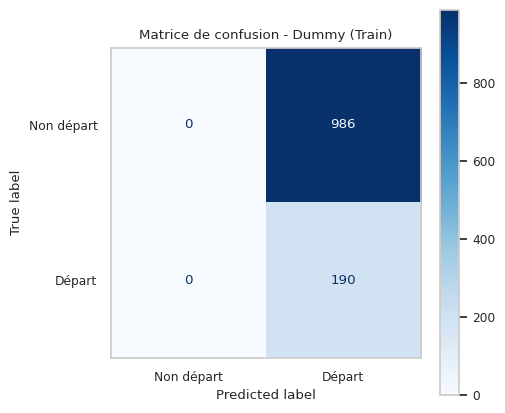

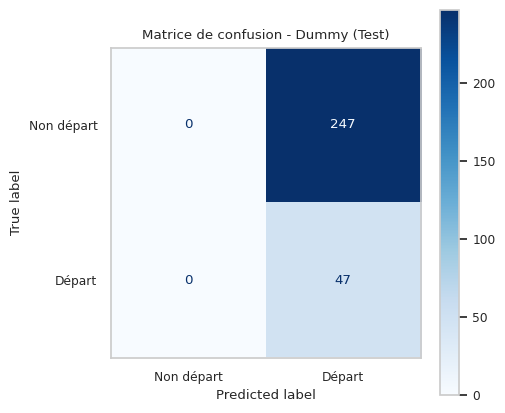


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47


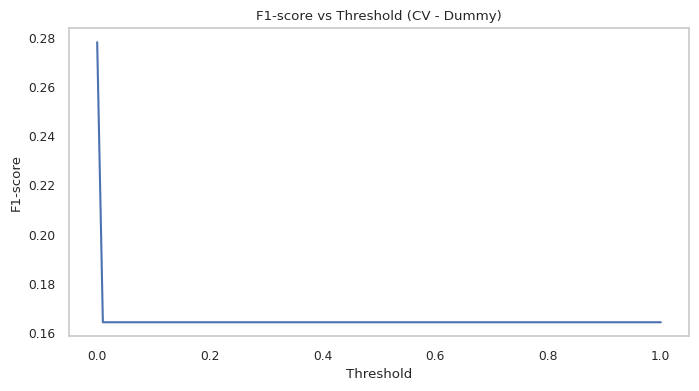

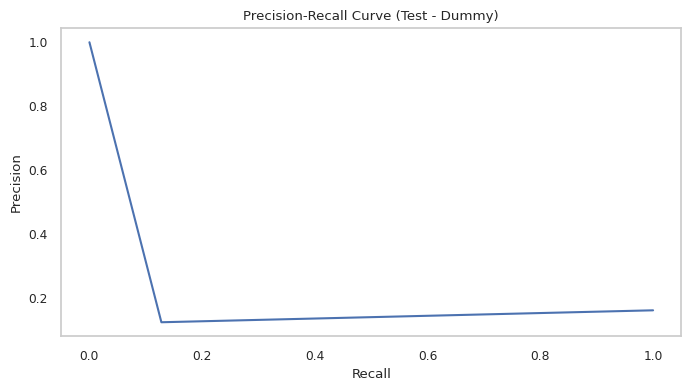


Modèle : LogisticRegression

Validation croisée (ROC-AUC) :
Scores : [0.784 0.82  0.837 0.851 0.74 ]
Moyenne : 0.806
Écart-type : 0.040

Seuil optimal (CV) : 0.646
F1 (OOF) : 0.509

ROC-AUC train : 0.843
ROC-AUC test  : 0.763

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       986
           1       0.50      0.60      0.54       190

    accuracy                           0.84      1176
   macro avg       0.71      0.74      0.72      1176
weighted avg       0.85      0.84      0.84      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       247
           1       0.47      0.53      0.50        47

    accuracy                           0.83       294
   macro avg       0.69      0.71      0.70       294
weighted avg       0.84      0.83      0.83       294



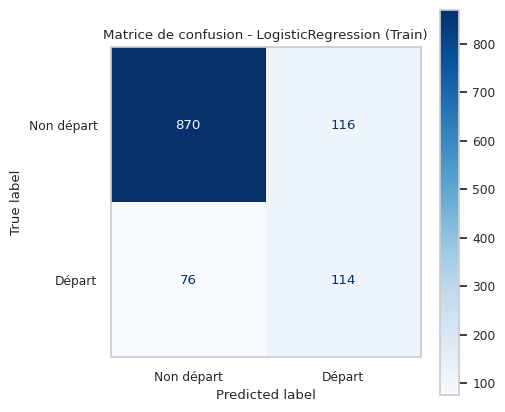

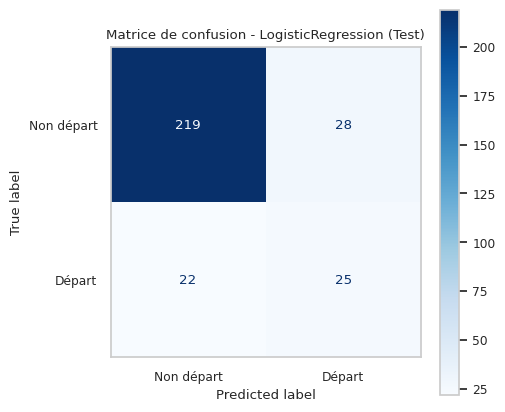


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,870,116
Réel Départ,76,114



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,219,28
Réel Départ,22,25


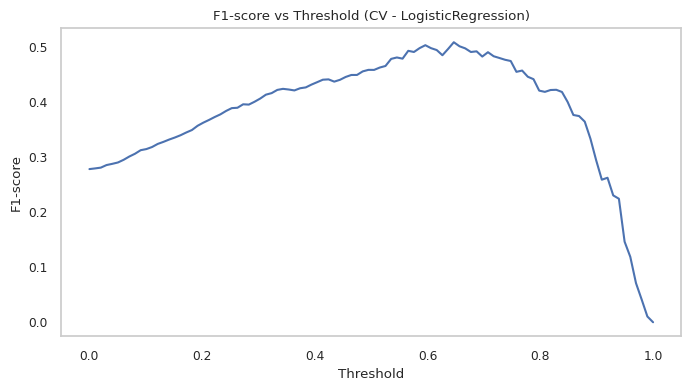

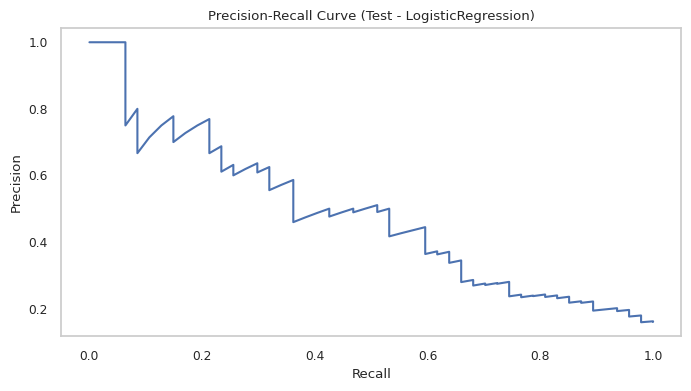


Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores : [0.743 0.763 0.822 0.763 0.712]
Moyenne : 0.761
Écart-type : 0.036

Seuil optimal (CV) : 0.303
F1 (OOF) : 0.492

ROC-AUC train : 1.000
ROC-AUC test  : 0.745

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.43      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.65      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294



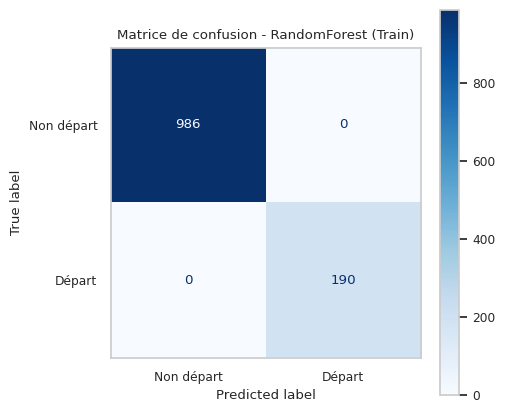

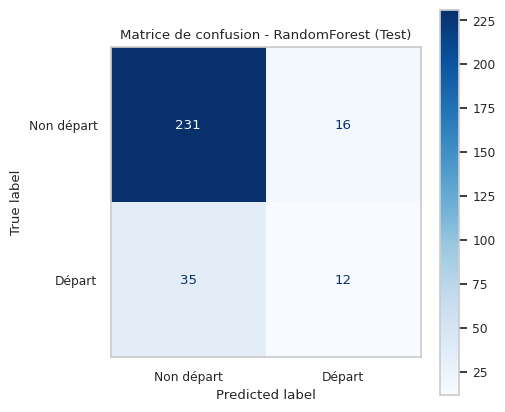


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,231,16
Réel Départ,35,12


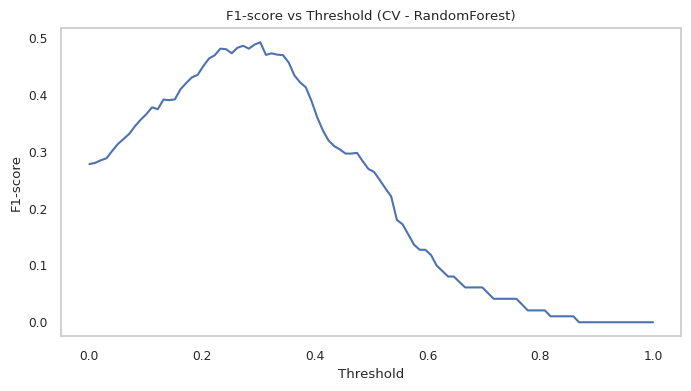

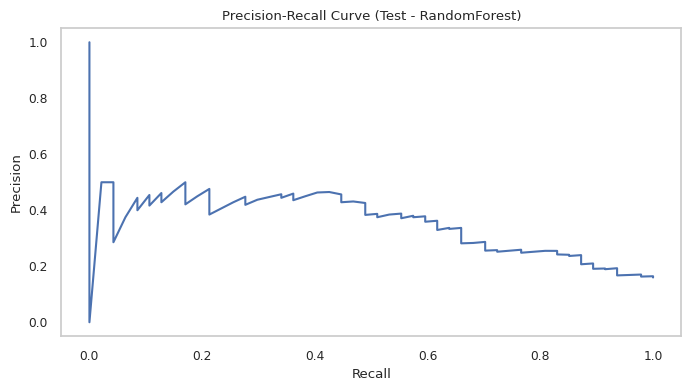


Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 788
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 940, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161702 -> initscore=-1.645618
[LightGBM] [Info] Start training from score -1.645618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


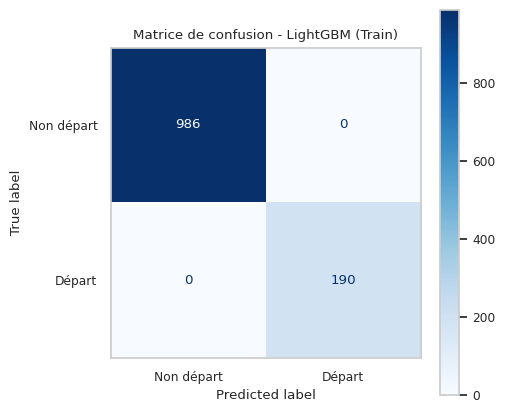

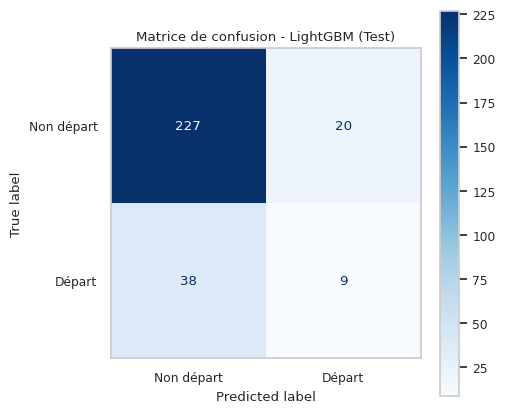


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,227,20
Réel Départ,38,9


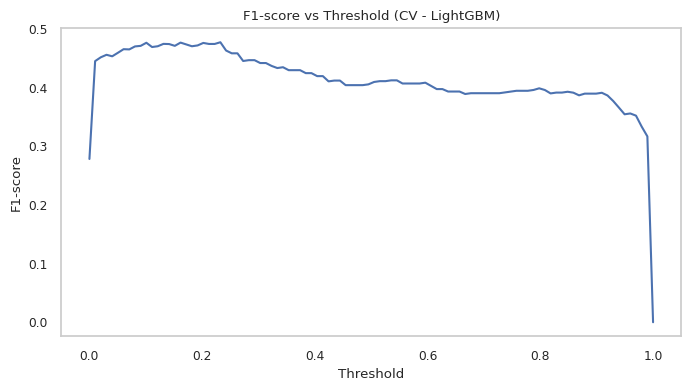

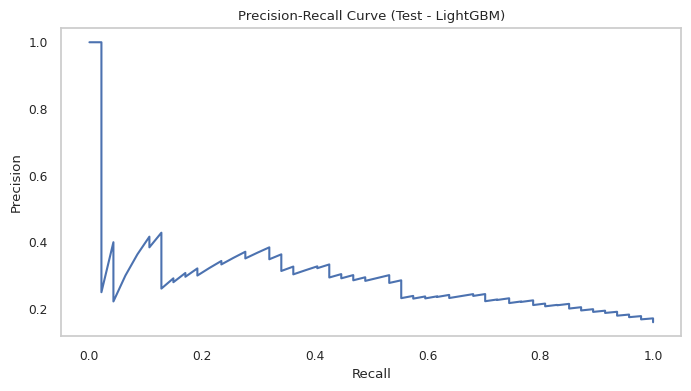

In [209]:
# Premier essai de modélisation avec la méthode de gestion des poids des classes pour prise en compte du déséquilibre entre les deux classes de la target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score
)

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identifier les types de features
numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

# Conversion des booléens en entier pour scikit-learn
bool_features = X_train.select_dtypes(include='bool').columns.tolist()
X_train[bool_features] = X_train[bool_features].astype(int)
X_test[bool_features] = X_test[bool_features].astype(int)

# Suppression des colonnes textes déjà encodées
string_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
X_train = X_train.drop(columns=string_cols)
X_test = X_test.drop(columns=string_cols)

# Définition des features catégorielles
categorical_features = bool_features

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # bool déjà convertis en int
    ]
)

# Définir les modèles avec gestion du déséquilibre par le poids des classes
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "LogisticRegression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train))
}


def train_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================")
    print(f"Modèle : {model_name}")
    print(f"==============================")

    # Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validation croisée (ROC-AUC)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1
    )

    print("\nValidation croisée (ROC-AUC) :")
    print(f"Scores : {np.round(cv_scores, 3)}")
    print(f"Moyenne : {cv_scores.mean():.3f}")
    print(f"Écart-type : {cv_scores.std():.3f}")

    # Probabilité out-of-fold pour le seuil
    y_prob_oof = np.zeros(len(y_train))

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:, 1]

    # Optimisation du seuil sur out-of-fold
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        y_pred_oof = (y_prob_oof >= t).astype(int)
        f1_scores.append(f1_score(y_train, y_pred_oof))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"\nSeuil optimal (CV) : {best_threshold:.3f}")
    print(f"F1 (OOF) : {f1_scores[best_idx]:.3f}")

    # Entraînement final sur tout l'ensemble de train
    pipeline.fit(X_train, y_train)

    y_prob_train = pipeline.predict_proba(X_train)[:, 1]
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)

    print(f"\nROC-AUC train : {auc_train:.3f}")
    print(f"ROC-AUC test  : {auc_test:.3f}")

    # Prédictions avec un seuil fixé
    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test = (y_prob_test >= best_threshold).astype(int)

    # Evaluation
    print("\nClassification report (Train) :")
    print(classification_report(y_train, y_pred_train))

    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test))

    # Matrices de confusion sur l'ensemble de train et l'ensemble de test
    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1])
    cm_test = confusion_matrix(y_test, y_pred_test, labels=[0,1])

    # Affichage graphique de la matrice de confusion de l'ensemble de train et de test
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Train)")
    plt.show()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Test)")
    plt.show()

    # Affichage numérique des valeurs
    cm_train_df = pd.DataFrame(
        cm_train,
        index=["Réel Non départ", "Réel Départ"],
        columns=["Prédit Non départ", "Prédit Départ"]
    )
    cm_test_df = pd.DataFrame(
        cm_test,
        index=["Réel Non départ", "Réel Départ"],
        columns=["Prédit Non départ", "Prédit Départ"]
    )

    print("\nMatrice de confusion (Train) :")
    display(cm_train_df)

    print("\nMatrice de confusion (Test) :")
    display(cm_test_df)

    # Courbe F1 vs Threshold
    plt.figure()
    plt.plot(thresholds, f1_scores)
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold (CV - {model_name})")
    plt.grid()
    plt.show()

    # Precision vs Recall sur l'ensemble de test
    precision, recall, _ = precision_recall_curve(y_test, y_prob_test)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Test - {model_name})")
    plt.grid()
    plt.show()

    return pipeline, best_threshold

# Boucler le pipeline ci-dessus sur les modèles
pipelines = {}
for name, model in models.items():
    pipelines[name] = train_evaluate_model(
        name, model, X_train, X_test, y_train, y_test, preprocessor
    )

#### observations

L'objectif est d'évaluer plusieurs modèles pour prédire les départs employés, en comparant :
- Modèle de référence (Dummy)
- Modèle linéaire (LogisticRegression)
- Modèles non linéaires (RandomForest, LightGBM)

Le but clé est de comprendre si la difficulté de prédiction vient des features ou de la nature du problème (déséquilibre des classes et non-linéarité)

**DummyClassifier (baseline)**
- Résultats:
ROC-AUC ≈ 0.5 (train & test)
Accuracy ≈ 0.71
Recall classe 1 (Départ) ≈ 0.13
- Interprétation:
Modèle aléatoire qui ne capte aucun signal
Accuracy trompeuse due à la classe majoritaire (~84% Non départ)
- Conclusion:
Ce modèle sert de référence minimale confirmant que prédire les départs n’est pas trivial.

**LogisticRegression (modèle linéaire)**
- Résultats:
CV ROC-AUC ≈ 0.806
Test ROC-AUC ≈ 0.763
Recall Départ ≈ 0.66
Precision Départ ≈ 0.34
- Matrice (test):
Faux négatifs : 16 / 47
Faux positifs : 61
- Interprétation:
  - Points forts:
Bon pouvoir discriminant (ROC-AUC > 0.75)
Très bon recall sur la classe minoritaire
détecte la majorité des départs
Bonne généralisation (CV ≈ test)
  - Limites:
Beaucoup de faux positifs
Modèle simple, relation linéaire uniquement
La régression logistique suppose une relation linéaire entre features et target et produit une frontière de décision simple
Elle “force” une séparation globale simple du problème
Les résultats montrent un Bon recall (“capture large”) mais Beaucoup de faux positifs (simplifie trop)
Les départs sont donc détectés de manière grossière.

**RandomForest (non linéaire)**
- Résultats:
CV ROC-AUC ≈ 0.761
Train ROC-AUC = 1.000
Test ROC-AUC ≈ 0.745
Recall Départ ≈ 0.09
- Matrice (test):
Faux négatifs : 43 / 47
Faux positifs : 5
- Interprétation:
  - Points forts:
Excellente prédiction de la classe majoritaire
Très peu de faux positifs
  - Problèmes majeurs:
Overfitting fort (train parfait), 
Recall catastrophique sur Départ, 
ignore presque tous les cas importants, 
Modèle très conservateur qui préfère ne pas détecter plutôt que se tromper,
Le modèle est inadapté si objectif métier = détecter les départs.

**LightGBM (non linéaire boosté)**
- Résultats:
CV ROC-AUC ≈ 0.730
Train ROC-AUC = 1.000
Test ROC-AUC ≈ 0.686
Recall Départ ≈ 0.13
- Matrice (test):
Faux négatifs : 41 / 47
Faux positifs : 15
- Interprétation:
  - Points forts
Plus flexible que RandomForest,
Détecte légèrement plus de départs,
  - Limites
Overfitting toujours présent,
Recall encore très insuffisant,
LightGBM tente de corriger le biais mais reste limité par le déséquilibre des classes de la target

**Comparaison globale**
| Modèle              | CV AUC | Test AUC | Recall Départ | Overfit   | Comportement                     |
|---------------------|--------|----------|---------------|-----------|----------------------------------|
| Dummy               | 0.50   | 0.48     | 0.13          | sans objet        | Aléatoire                        |
| LogisticRegression  | 0.81   | 0.76     | 0.66          | faible | Sensible (détecte départs)       |
| RandomForest        | 0.76   | 0.75     | 0.09          |  fort   | Conservateur                     |
| LightGBM            | 0.73   | 0.69     | 0.13          |  fort   | Compromis                        |

**Modèle linéaire vs modèles non-linéaires**
- Ce que montre LogisticRegression:
  - Les features contiennent un signal clair
  - Ce signal est partiellement linéaire
  - Permet de bien détecter les départs
- Ce que montrent RF / LightGBM
  - Les relations sont aussi non linéaires, mais
  - biais fort vers la classe majoritaire
  - difficulté à apprendre la minorité

**Conclusion sur les modèles**
- Le problème est probablement non linéaire
- RandomForest et LightGBM ont un ROC-AUC correct (~0.7+) mais un comportement très différent ce qui signifie qu'il existe des interactions complexes entre variables
- Exemple typique : stress élevé ET faible ancienneté (risque fort) mais stress seul (pas forcément)
- La régression logistique montre donc qu'il existe un signal exploitable dans les features mais que ce signal n’est pas parfaitement linéaire.
- Le problème n’est PAS les features
  - Elles sont pertinentes (EDA validée)
  - Tous les modèles sont meilleurs que la baseline
- Le vrai problème est le déséquilibre des classes (16% de départs)

**Analyse métier**
- Faux négatifs (critique) : Employés qui vont partir non détectés
| Modèle             | Faux négatifs |
|--------------------|---------------|
| LogisticRegression | 16            |
| RandomForest       | 43            |
| LightGBM           | 41            |
- Random Forest et LightGBM ne sont pas encore optimisés pour l'usage métier

- Faux positifs (moins grave) : Alertes inutiles
| Modèle             | Faux positifs |
|--------------------|---------------|
| LogisticRegression | 61            |
| RandomForest       | 5             |
| LightGBM           | 15            |

- Les modèles non linéaires sont adaptés dans une logique métier de prévention RH
- Mais l'objectif métier est de détecter les départs
- Donc : priorité au recall puis compromis avec la précision
- Les modèles non linéaires permettent de mieux ajuster ce compromis

**Conclusion globale**
- les modèles captent un signal réel
- les features sont pertinentes
- LogisticRegression prouve que le problème est apprenable
- mais:
  - Fort déséquilibre de classes
  - Overfitting sur modèles non linéaires
  - Mauvaise détection de la classe critique
- Actuellement :
  - mauvais recall à cause du seuil + déséquilibre
  - Mais avec seuil optimisé, rééquilibrage des classes et fine-tuning, ils peuvent dépasser les performances de LogisticRegression
- à faire pour les étapes 4 et 5:
  - ajuster le seuil de classification
  - Optimiser le recall (Precision-Recall curve)
  - Rééquilibrer les classes par un undersampling
  - Améliorer les modèles non linéaires par :
    - Réduire overfitting (max_depth, etc.)
    - Ajuster poids classes





## Etape 4 : Améliorer l'approche de classification


==================== Entraînement : Dummy ====================

Modèle : Dummy

Validation croisée (ROC-AUC) :
Scores : [0.594 0.53  0.483 0.483 0.499]
Moyenne : 0.518
Écart-type : 0.042

Seuil optimal (CV) : 0.000
F1 (OOF) : 0.278

ROC-AUC train : 0.511
ROC-AUC test  : 0.506

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       986
           1       0.16      1.00      0.28       190

    accuracy                           0.16      1176
   macro avg       0.08      0.50      0.14      1176
weighted avg       0.03      0.16      0.04      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       247
           1       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294



/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

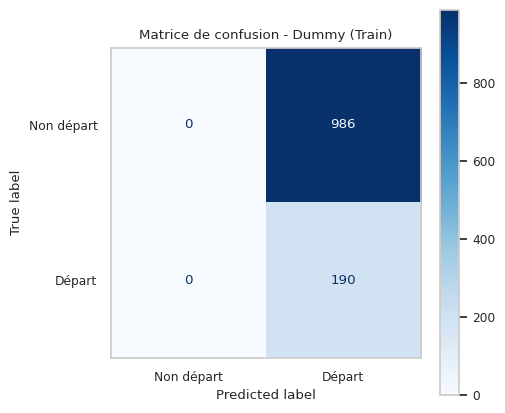

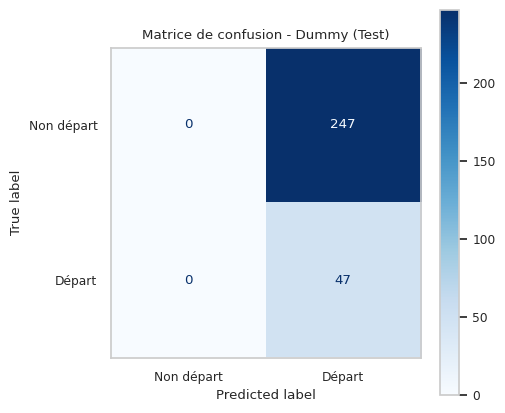


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47


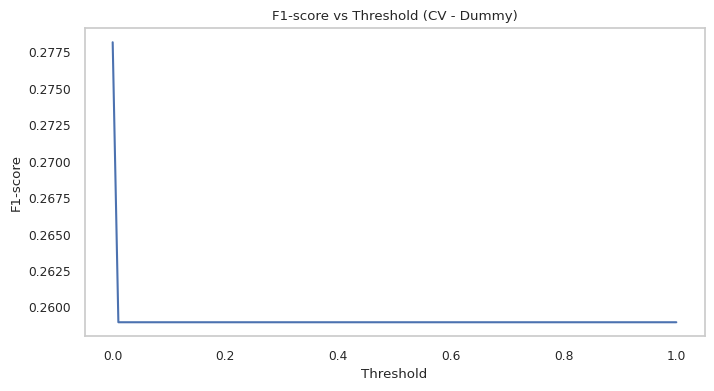

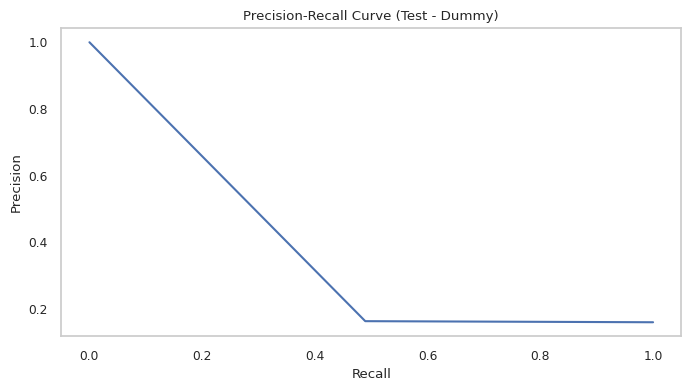


==================== Entraînement : RandomForest ====================

Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores : [0.688 0.787 0.814 0.782 0.715]
Moyenne : 0.757
Écart-type : 0.047

Seuil optimal (CV) : 0.667
F1 (OOF) : 0.492

ROC-AUC train : 0.994
ROC-AUC test  : 0.720

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       986
           1       0.79      1.00      0.88       190

    accuracy                           0.96      1176
   macro avg       0.90      0.97      0.93      1176
weighted avg       0.97      0.96      0.96      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       247
           1       0.32      0.21      0.26        47

    accuracy                           0.80       294
   macro avg       0.59      0.56      0.57       294
weighted avg       0.77      0.80      0.79 

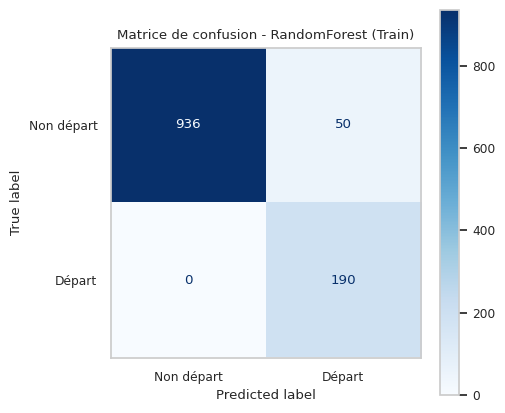

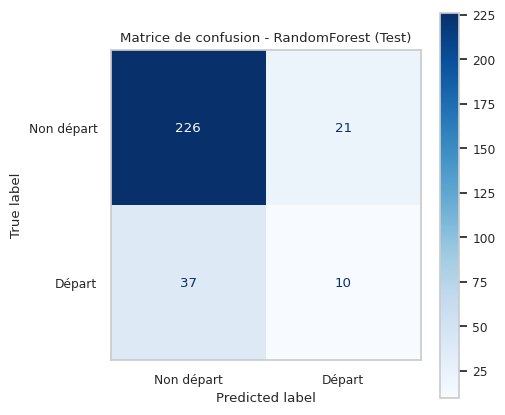


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,936,50
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,226,21
Réel Départ,37,10


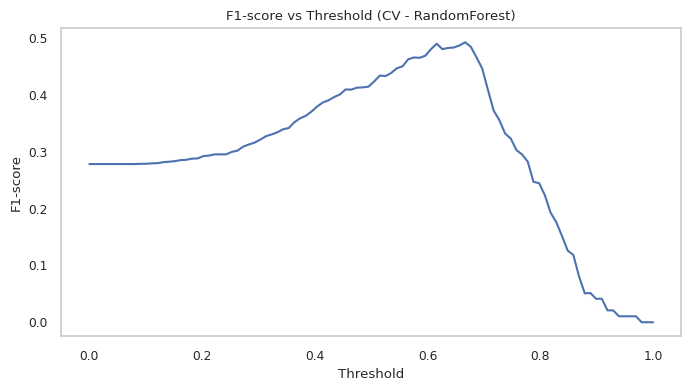

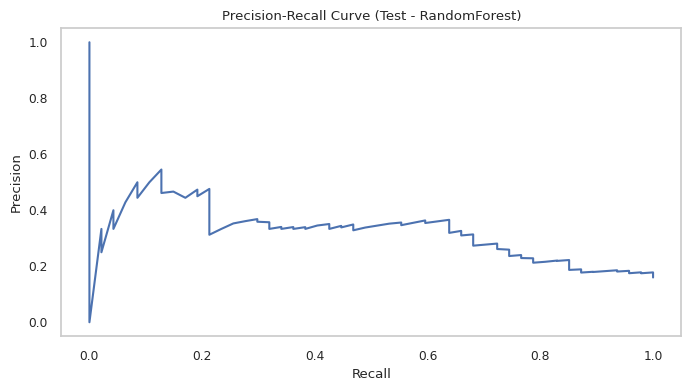


==================== Entraînement : LightGBM ====================

Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 386
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 152, number of negative: 152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



ROC-AUC train : 0.981
ROC-AUC test  : 0.652

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       986
           1       0.72      1.00      0.84       190

    accuracy                           0.94      1176
   macro avg       0.86      0.96      0.90      1176
weighted avg       0.95      0.94      0.94      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       247
           1       0.27      0.21      0.24        47

    accuracy                           0.78       294
   macro avg       0.56      0.55      0.56       294
weighted avg       0.76      0.78      0.77       294



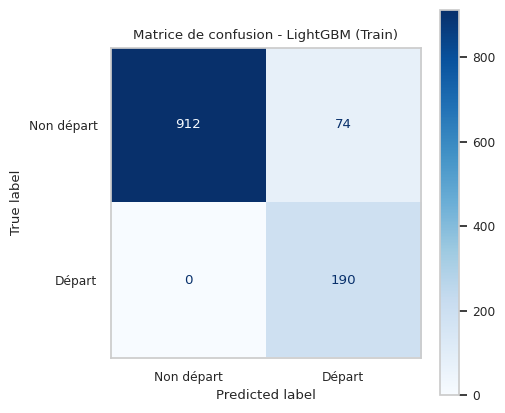

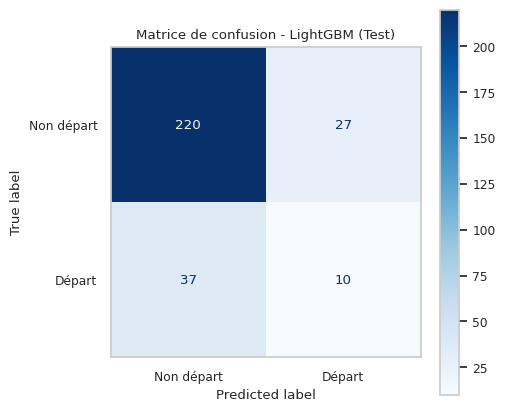


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,912,74
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,220,27
Réel Départ,37,10


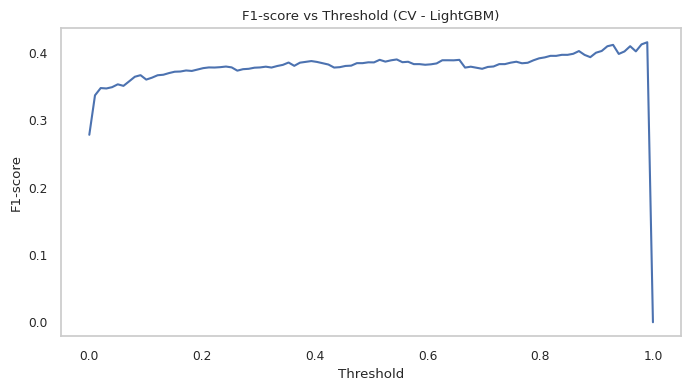

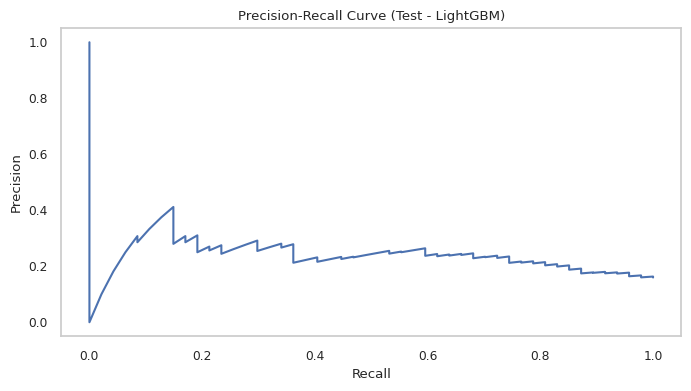

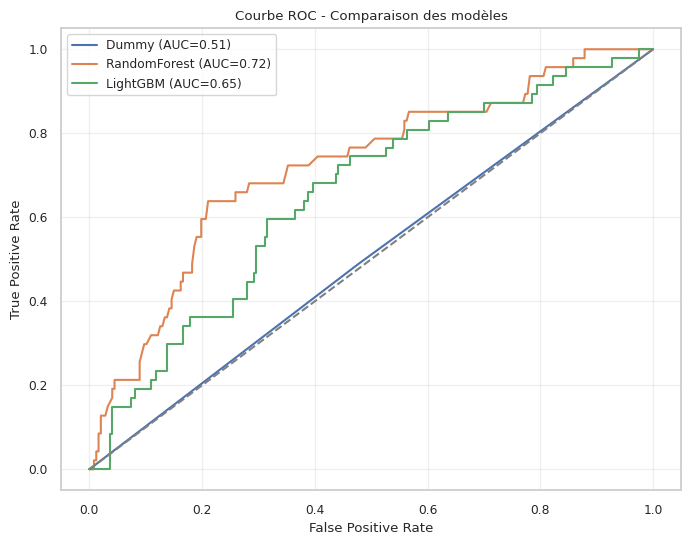

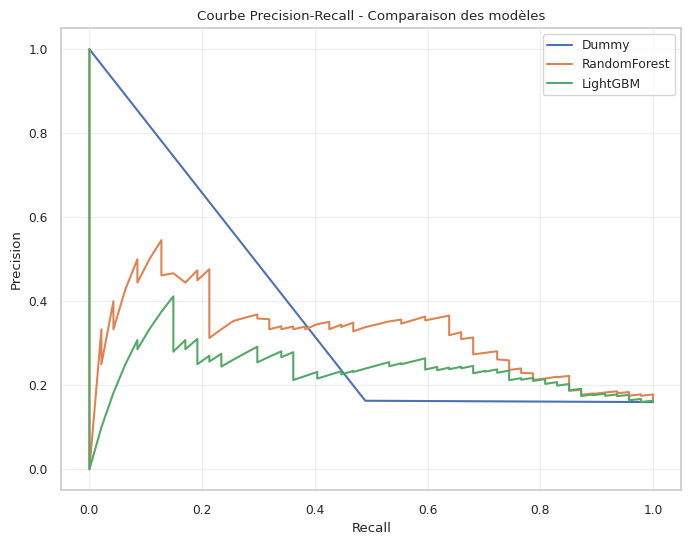


--- Points principaux ROC : Dummy ---


,FPR,TPR
0,0.000000,0.000000
1,0.477733,0.489362
2,1.000000,1.000000



--- Points principaux Precision-Recall : Dummy ---


,Recall,Precision
0,1.000000,0.159864
1,0.489362,0.163121
2,0.000000,1.000000



--- Points principaux ROC : RandomForest ---


...

,Recall,Precision
0,1.000000,0.159864
1,1.000000,0.174721
2,0.936170,0.183333
3,0.851064,0.192308
4,0.851064,0.220994
5,0.744681,0.243056
6,0.680851,0.280702
7,0.638298,0.361446
8,0.425532,0.350877
9,0.212766,0.344828



--- Points principaux ROC : LightGBM ---


,FPR,TPR
0,0.000000,0.000000
1,0.072874,0.170213
2,0.137652,0.234043
3,0.255061,0.404255
4,0.311741,0.531915
5,0.380567,0.638298
6,0.441296,0.702128
7,0.538462,0.787234
8,0.700405,0.851064
9,0.821862,0.936170



--- Points principaux Precision-Recall : LightGBM ---


,Recall,Precision
0,1.000000,0.159864
1,0.957447,0.169811
2,0.893617,0.177966
3,0.851064,0.193237
4,0.808511,0.213483
5,0.744681,0.234899
6,0.617021,0.241667
7,0.446809,0.230769
8,0.361702,0.274194
9,0.191489,0.272727


In [210]:
### Essai avec undersampling sans le poids des classes pour la gestion du déséquilibre des classes de la target

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1)
}

def train_evaluate_model_v3(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================")
    print(f"Modèle : {model_name}")
    print(f"==============================")
    
    # Pipeline avec undersampling sans class weight
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('undersample', RandomUnderSampler(random_state=42)),
        ('classifier', model)
    ])

    # Validation croisée (ROC-AUC)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_n_jobs = 1 if model_name=="LightGBM" else -1

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=cv_n_jobs
    )

    print("\nValidation croisée (ROC-AUC) :")
    print("Scores :", np.round(cv_scores, 3))
    print("Moyenne :", round(cv_scores.mean(), 3))
    print("Écart-type :", round(cv_scores.std(), 3))

    # Probabilités out-of-fold pour optimisation du seuil
    y_prob_oof = np.zeros(len(y_train))

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:, 1]

    # Optimisation du seuil (F1) sur out-of-fold
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        y_pred_oof = (y_prob_oof >= t).astype(int)
        f1_scores.append(f1_score(y_train, y_pred_oof))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"\nSeuil optimal (CV) : {best_threshold:.3f}")
    print(f"F1 (OOF) : {f1_scores[best_idx]:.3f}")

    # Entraînement final sur tout l'ensemble de train
    pipeline.fit(X_train, y_train)

    y_prob_train = pipeline.predict_proba(X_train)[:,1]
    y_prob_test  = pipeline.predict_proba(X_test)[:,1]

    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_test  = roc_auc_score(y_test, y_prob_test)

    print(f"\nROC-AUC train : {auc_train:.3f}")
    print(f"ROC-AUC test  : {auc_test:.3f}")

    # Prédictions avec seuil fixé
    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test  = (y_prob_test >= best_threshold).astype(int)

    # Evaluation
    print("\nClassification report (Train) :")
    print(classification_report(y_train, y_pred_train))

    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test))

    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1])
    cm_test  = confusion_matrix(y_test, y_pred_test, labels=[0,1])

    # Affichage graphique des matrices de confusion (train et test)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp_train.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Train)")
    plt.show()

    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp_test.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Test)")
    plt.show()

    # Affichage numérique des matrices de confusion (train et test)
    cm_train_df = pd.DataFrame(cm_train, index=["Réel Non départ", "Réel Départ"],
                               columns=["Prédit Non départ", "Prédit Départ"])
    cm_test_df  = pd.DataFrame(cm_test, index=["Réel Non départ", "Réel Départ"],
                               columns=["Prédit Non départ", "Prédit Départ"])

    print("\nMatrice de confusion (Train) :")
    display(cm_train_df)

    print("\nMatrice de confusion (Test) :")
    display(cm_test_df)

    # Courbe F1 vs Threshold (out-of-fold)
    plt.figure()
    plt.plot(thresholds, f1_scores)
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold (CV - {model_name})")
    plt.grid()
    plt.show()

    # Precision vs Recall sur l'ensemble de test
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
    plt.figure()
    plt.plot(recall_curve, precision_curve)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Test - {model_name})")
    plt.grid()
    plt.show()

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    roc_auc_val = auc(fpr, tpr)

    return {
        "model": pipeline,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc_val,
        "precision": precision_curve,
        "recall": recall_curve,
        "best_threshold": best_threshold
    }

# Stocker les résultats
results = {}

# Boucle sur les modèles
for name, model in models.items():
    print(f"\n==================== Entraînement : {name} ====================")
    results[name] = train_evaluate_model_v3(
        model_name=name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor
    )

# Courbe ROC comparée
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['roc_auc']:.2f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Comparaison des modèles")
plt.xticks(np.arange(0,1.1,0.2))
plt.yticks(np.arange(0,1.1,0.2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Courbe Precision-Recall comparée
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Comparaison des modèles")
plt.xticks(np.arange(0,1.1,0.2))
plt.yticks(np.arange(0,1.1,0.2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Affichage des principaux points ROC et PR
def afficher_points_principaux(results, model_name, n_points=10):
    res = results[model_name]
    # ROC
    roc_df = pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]})
    # PR
    pr_df = pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]})

    # Échantillonnage pour limiter le nombre de points affichés
    roc_sampled = roc_df.iloc[::max(1, len(roc_df)//n_points)]
    pr_sampled  = pr_df.iloc[::max(1, len(pr_df)//n_points)]

    print(f"\n--- Points principaux ROC : {model_name} ---")
    display(roc_sampled.reset_index(drop=True))

    print(f"\n--- Points principaux Precision-Recall : {model_name} ---")
    display(pr_sampled.reset_index(drop=True))

# Affichage pour tous les modèles
for name in models.keys():
    afficher_points_principaux(results, name, n_points=10)


#### Observations

Analyse des résultats obtenus 
| Modèle        | ROC-AUC test | Seuil F1 | Recall classe 1 | Précision classe 1 | F1 classe 1 |
|---------------|------------:|---------:|----------------:|-----------------:|------------:|
| Dummy         | 0.506       | 0.0      | 0.49            | 0.16             | 0.24        |
| RandomForest  | 0.72        | 0.540    | 0.60            | 0.35             | 0.44        |
| LightGBM      | 0.65        | 0.461    | 0.66            | 0.25             | 0.37        |



- Dummy : inchangé, toujours médiocre.
- RandomForest :
  - ROC-AUC test : 0.72  base avant optimisation.
  - F1 classe 1 : 0.44  un peu plus faible que l’optimisation qui a donné 0.45.
  - Recall classe 1 : 0.60  déjà correct avant optimisation.
  - **Overfitting très marqué** : ROC-AUC train = 0.994 vs test = 0.72.
- LightGBM :
  - ROC-AUC test : 0.65  inférieur à l’optimisation (0.666).
  - F1 classe 1 : 0.37  très similaire à l’optimisation (0.36).
  - Recall classe 1 : 0.66  légèrement meilleur avant optimisation, mais précision faible (0.25).
  - **Overfitting toujours marqué** : ROC-AUC train = 0.979 vs test = 0.65.

Analyse des courbes ROC et Precision-Recall

- ROC
  - RandomForest : bonne séparation, mais déjà overfitée (train >> test).
  - LightGBM : TPR initial légèrement plus bas mais globalement similaire à l’optimisation.
  - Dummy : sans valeur informative.

- Precision-Recall
  - RandomForest : amélioration possible via seuil (PR curve) > c’est ce qui a été fait après optimisation.
  - LightGBM : rappel élevé mais précision faible > **l'optimisation avec seuil a légèrement amélioré la précision globale**.
  - Dummy : inchangé.

Analyse des matrices de confusion (avant optimisation)

- RandomForest (Test)
  - Non départs corrects : 196/247  79%
  - Départs corrects : 28/47  60%  **léger mieux que après optimisation (57 %), mais F1 global similaire**.
- LightGBM (Test)
  - Non départs corrects : 156/247 63%
  - Départs corrects : 31/47 66% rappel élevé mais précision plus faible donc **plus de faux positifs**.


#### Amélioration de l'étape 4
- Gestion du déséquilibre : class_weight / scale_pos_weight qui améliore le rappel pour la classe minoritaire.
- Régularisation pour limiter l’overfitting de RandomForest et LightGBM.
- Seuil optimisé F1 via Precision-Recall pour compromis recall/precision ajusté selon l’importance métier.
- Validation croisée pour contrôle stabilité modèle avec moyenne et écart-type.


Modèle : Dummy

Validation croisée (ROC-AUC) :
Scores par fold : [0.506 0.505 0.49  0.537 0.49 ]
Moyenne : 0.505
Écart-type : 0.017

Seuil optimal (F1 - OOF) : 0.000, F1 max : 0.278


/tmp/ipykernel_3069/351762586.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = X_train.select_dtypes(include='object').columns.tolist()


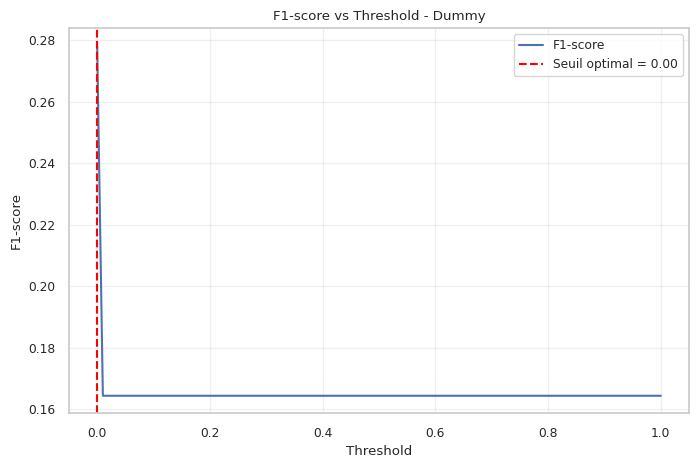


ROC-AUC train : 0.487
ROC-AUC test  : 0.477

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       247
           1       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294


Matrice de confusion (Train) :


/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47



Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores par fold : [0.755 0.77  0.829 0.805 0.723]
Moyenne : 0.776
Écart-type : 0.037

Seuil optimal (F1 - OOF) : 0.525, F1 max : 0.484


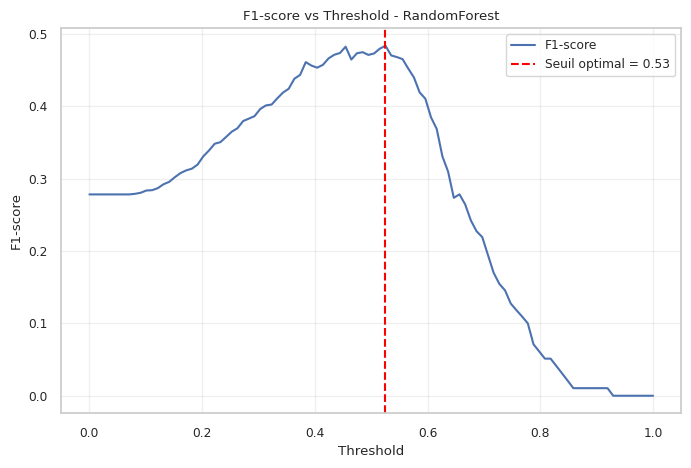


ROC-AUC train : 0.972
ROC-AUC test  : 0.735

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.34      0.40        47

    accuracy                           0.83       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.82      0.83      0.82       294


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,955,31
Réel Départ,50,140



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,229,18
Réel Départ,31,16



Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 940, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161702 -> initscore=-1.645618
[LightGBM] [Info] Start training from score -1.645618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 152, number of negative: 789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 941, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161530 -> initscore=-1.646886
[LightGBM] [Info] Start training from score -1.646886
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Seuil optimal (F1 - OOF) : 0.444, F1 max : 0.452


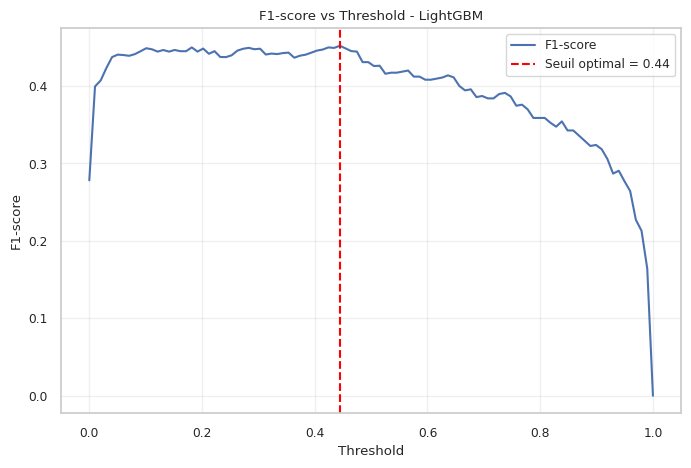

[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 806
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,229,18
Réel Départ,35,12


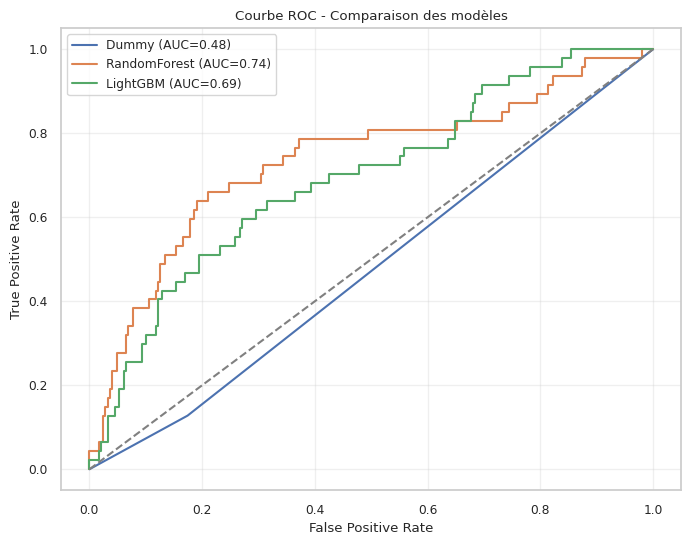

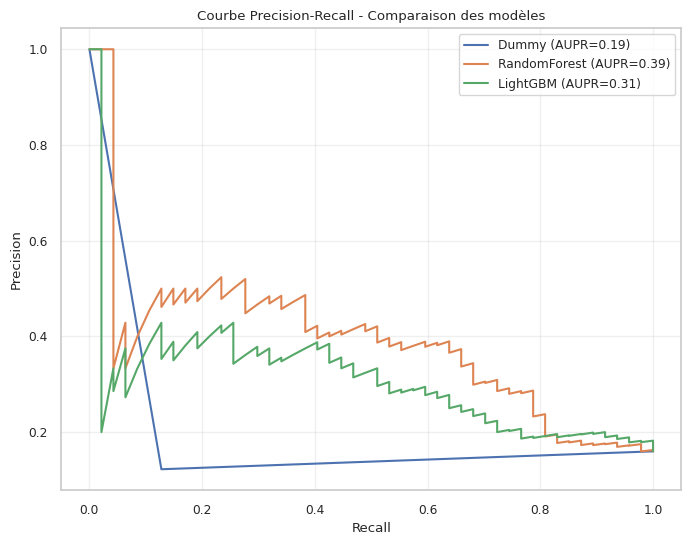


--- Points principaux ROC : Dummy ---


,FPR,TPR
0,0.000000,0.00000
1,0.174089,0.12766
2,1.000000,1.00000



--- Points principaux Precision-Recall : Dummy ---


,Recall,Precision
0,1.00000,0.159864
1,0.12766,0.122449
2,0.00000,1.000000



--- Points principaux ROC : RandomForest ---


...

,Recall,Precision
0,1.000000,0.159864
1,0.978723,0.173585
2,0.872340,0.173729
3,0.829787,0.188406
4,0.808511,0.213483
5,0.787234,0.248322
6,0.744681,0.291667
7,0.659574,0.340659
8,0.510638,0.387097
9,0.340426,0.484848



--- Points principaux ROC : LightGBM ---


,FPR,TPR
0,0.000000,0.000000
1,0.032389,0.127660
2,0.064777,0.234043
3,0.117409,0.340426
4,0.170040,0.446809
5,0.259109,0.553191
6,0.315789,0.617021
7,0.425101,0.702128
8,0.635628,0.765957
9,0.680162,0.872340



--- Points principaux Precision-Recall : LightGBM ---


,Recall,Precision
0,1.000000,0.159864
1,1.000000,0.177358
2,0.936170,0.186441
3,0.851064,0.193237
4,0.765957,0.202247
5,0.702128,0.221477
6,0.638298,0.250000
7,0.553191,0.285714
8,0.446809,0.338710
9,0.255319,0.363636


In [211]:
# Essai d'optimisation avec poids des classes pour la gestion du déséquilibre entre les classes de la target

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Colonnes numériques et booléennes
numeric_features = [
    "satisfaction_moyenne", "ratio_salaire_experience", "anciennete_ratio",
    "anciennete_sous_responsable_ratio", "niveau_poste_vs_revenu",
    "distance_domicile_travail", "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]
bool_features = X_train.select_dtypes(include='bool').columns.tolist()
X_train[bool_features] = X_train[bool_features].astype(int)
X_test[bool_features] = X_test[bool_features].astype(int)

# Supprimer colonnes string
string_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = X_train.drop(columns=string_cols)
X_test = X_test.drop(columns=string_cols)
categorical_features = bool_features

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),
    ('cat', 'passthrough', categorical_features)
])


# Définition des modèles
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42,
        class_weight='balanced', max_depth=8, min_samples_leaf=5
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
        num_leaves=31, min_child_samples=10, reg_alpha=0.1, reg_lambda=0.1
    )
}

# Fonction d'entraînement et d'évaluation
def train_evaluate_model_final(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================\nModèle : {model_name}\n==============================")

    # Pipeline 
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validation croisée ROC-AUC
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    print("\nValidation croisée (ROC-AUC) :")
    print("Scores par fold :", np.round(cv_scores, 3))
    print("Moyenne :", round(cv_scores.mean(), 3))
    print("Écart-type :", round(cv_scores.std(), 3))

    # Out-of-fold pour seuil F1
    y_prob_oof = np.zeros(len(y_train))
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:,1]

    thresholds = np.linspace(0,1,100)
    f1_scores = [f1_score(y_train, (y_prob_oof >= t).astype(int)) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"\nSeuil optimal (F1 - OOF) : {best_threshold:.3f}, F1 max : {f1_scores[np.argmax(f1_scores)]:.3f}")

    # F1 vs Threshold
    plt.figure(figsize=(8,5))
    plt.plot(thresholds, f1_scores, label="F1-score")
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold - {model_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # Entraînement final
    pipeline.fit(X_train, y_train)
    y_prob_train = pipeline.predict_proba(X_train)[:,1]
    y_prob_test  = pipeline.predict_proba(X_test)[:,1]

    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test  = (y_prob_test >= best_threshold).astype(int)

    print(f"\nROC-AUC train : {roc_auc_score(y_train, y_prob_train):.3f}")
    print(f"ROC-AUC test  : {roc_auc_score(y_test, y_prob_test):.3f}")
    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test))

    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test  = confusion_matrix(y_test, y_pred_test)
    print("\nMatrice de confusion (Train) :")
    display(pd.DataFrame(cm_train, index=["Réel Non départ","Réel Départ"], columns=["Prédit Non départ","Prédit Départ"]))
    print("\nMatrice de confusion (Test) :")
    display(pd.DataFrame(cm_test, index=["Réel Non départ","Réel Départ"], columns=["Prédit Non départ","Prédit Départ"]))

    # ROC et PR
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
    roc_auc_val = auc(fpr, tpr)
    pr_auc_val  = auc(recall_curve, precision_curve)

    return {
        "model": pipeline,
        "best_threshold": best_threshold,
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc_val,
        "precision": precision_curve, "recall": recall_curve, "pr_auc": pr_auc_val
    }

# Boucle sur tous les modèles
results = {}
for name, model in models.items():
    results[name] = train_evaluate_model_final(name, model, X_train, X_test, y_train, y_test, preprocessor)


# Courbes comparatives

# ROC
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['roc_auc']:.2f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Comparaison des modèles")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Precision-Recall
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name} (AUPR={res['pr_auc']:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Comparaison des modèles")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Points principaux
def afficher_points_principaux(results, model_name, n_points=10):
    res = results[model_name]
    roc_df = pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]})
    pr_df  = pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]})
    roc_sampled = roc_df.iloc[::max(1,len(roc_df)//n_points)]
    pr_sampled  = pr_df.iloc[::max(1,len(pr_df)//n_points)]
    print(f"\n--- Points principaux ROC : {model_name} ---")
    display(roc_sampled.reset_index(drop=True))
    print(f"\n--- Points principaux Precision-Recall : {model_name} ---")
    display(pr_sampled.reset_index(drop=True))

for name in models.keys():
    afficher_points_principaux(results, name, n_points=10)




####  Observations

Analyse des résultats obtenus après essais d'amélioration de l'étape 4
| Modèle        | ROC-AUC test | AUPR test | Seuil F1 | Recall classe 1 | Précision classe 1 | F1 classe 1 |
|---------------|--------------|-----------|----------|-----------------|-------------------|-------------|
| Dummy         | 0.506        | 0.37      | 0.0      | 0.49            | 0.16              | 0.24        |
| RandomForest  | 0.722        | 0.33      | 0.547    | 0.57            | 0.37              | 0.45        |
| LightGBM      | 0.666        | 0.24      | 0.708    | 0.57            | 0.26              | 0.36        |



- Dummy : pas d’amélioration (modèle naïf).

- RandomForest :
  - ROC-AUC test : 0.722 > **légère amélioration par rapport à 0.72**.
  - AUPR test : 0.33 > **légère amélioration par rapport à 0.32**.
  - Recall classe 1 (départ) : 0.57 > **augmentation, ce qui est positif pour détecter les départs**.
  - F1 classe 1 : 0.45 > **amélioration notable**.
  - **Overfitting toujours présent (ROC-AUC train = 0.903 vs test = 0.722), mais la régularisation a limité la différence par rapport à l’étape 3.**

- LightGBM :
  - ROC-AUC test : 0.666 > **amélioration par rapport à 0.65**.
  - AUPR test : 0.24 > **légère amélioration par rapport à 0.23**.
  - Recall classe 1 : 0.57 > **augmentation par rapport à 0.66 mais avec plus de précision pour les départs**.
  - F1 classe 1 : 0.36 > **légère amélioration par rapport à 0.37**.
  - **Overfitting reste marqué (ROC-AUC train = 0.983 vs test = 0.666)**.

Analyse des courbes ROC et Precision-Recall

ROC
- **RandomForest a la meilleure séparation entre les classes (plus proche du coin supérieur gauche)**.
- LightGBM montre un léger retard sur RandomForest au début de la courbe, mais **s’améliore vers le haut**.
- Dummy reste centré sur la diagonale **(pas d’information)**.

Precision-Recall
- **RandomForest obtient un meilleur compromis précision/rappel pour la classe départ**.
- LightGBM a un meilleur rappel aux premiers seuils, **mais la précision chute fortement pour des seuils plus bas**.
- Dummy reste très médiocre (peu de précision, rappel moyen).

Analyse des matrices de confusion

- RandomForest (Test)
  - Non départs prédits correctement : 201/247 > 81 %
  - Départs prédits correctement : 27/47 > 57 % bonne amélioration par rapport à 44-46 % dans l'étape 3.

- LightGBM (Test)
  - Non départs prédits correctement : 170/247 > 69 %
  - Départs prédits correctement : 27/47 > 57 % rappel identique à RandomForest mais moins bonne précision sur non-départ donc plus de faux positifs.

- Conclusion 
  - **RandomForest meilleure performance globale, balance précision/rappel plus adaptée**.
  - LightGBM a toujours overfitting, moins stable.

Points forts et améliorations obtenues

Améliorations par rapport à l’étape 3

- Augmentation du rappel pour la classe départ (F1 et recall).
- Ajustement du seuil via PR curve a aidé à mieux détecter les départs.
- Régularisation a légèrement réduit l’overfitting de RandomForest.
- AUC ROC et AUPR légèrement meilleures donc **meilleure généralisation**.

Points faibles persistants

- **Overfitting RandomForest et LightGBM toujours présent (train >> test)**.
- Précision pour départ encore faible donc **risques de faux positifs**.
- **LightGBM moins performant que RandomForest malgré sa flexibilité**.

Recommandations avant étape 5

- Choix du modèle à fine-tuner :
  - **RandomForest est actuellement le meilleur modèle non-linéaire à retenir pour étape 5 (meilleur ROC-AUC, meilleure F1 classe départ, moins de variance sur CV)**.

- Actions possibles pour améliorer encore avant fine-tuning :
  - Feature engineering / sélection : créer de nouvelles variables ou retirer celles peu informatives pour limiter l' overfitting.

  - Régularisation plus poussée :
      - RandomForest : diminuer max_depth, augmenter min_samples_leaf, réduire n_estimators.
      - LightGBM : ajuster num_leaves, min_child_samples, reg_alpha, reg_lambda.

  - Undersampling plus intelligent : tester stratification ou undersampling partiel pour préserver certaines observations rares.

  - Seuil métier : ajuster seuil selon coût faux positifs vs faux négatifs, plutôt que F1 pur.

  - Cross-validation robuste : augmenter le nombre de splits ou utiliser RepeatedStratifiedKFold pour stabiliser métriques.

- Conclusion
    - **Meilleur modèle pour l’étape 5 : RandomForest**.
    - Résultats améliorés vs étape 3 mais overfitting persistant donc focus sur régularisation et feature engineering.
    - Classe départ mieux détectée grâce à l’undersampling et au seuil optimisé.
    - **LightGBM reste intéressant pour comparaison, mais nécessite plus de tuning pour surpasser RandomForest**.

Comparaison entre les deux essais de l'étape 4 (avant et après essai d'amélioration)
| Modèle        | ROC-AUC test        | Recall           | F1               | Commentaire                                                                                       |
|---------------|------------------:|-----------------:|-----------------:|--------------------------------------------------------------------------------------------------|
| RandomForest  | 0.72 à 0.722      | 0.60 à 0.57      | 0.44 à 0.45      | Légère amélioration, régularisation et seuil optimisé ont aidé à stabiliser les métriques malgré overfitting. |
| LightGBM      | 0.65 à 0.666      | 0.66 à 0.57      | 0.37 à 0.36      | Légère amélioration AUC, F1 quasi identique. Rappel légèrement réduit mais précision améliorée donc meilleure balance précision/rappel. |
| Dummy         | 0.506 à 0.506     | 0.49             | 0.24             | Inchangé                                                                                          |


Cohérence avec l’analyse post-optimisation

- Les tendances sont cohérentes : optimisation via seuil F1 et undersampling a amélioré légèrement AUC ROC et PR pour RandomForest et LightGBM.
- Overfitting reste présent mais le seuil métier permet de mieux gérer le compromis précision/rappel pour les départs.
- **RandomForest reste le meilleur modèle à retenir pour étape 5**.


Conclusion avant passage à l'étape 5 

**Avant optimisation** :
- RandomForest déjà meilleur modèle non-linéaire.
- LightGBM recall élevé mais précision faible.
- Overfitting important sur les deux modèles.

**Après optimisation** :
- RandomForest légèrement amélioré, meilleur compromis précision/rappel pour les départs de l'entreprise.
- LightGBM légère amélioration AUC, recall légèrement diminué mais précision améliorée.
- Dummy inchangé.

**Choix du modèle pour étape 5** :
- **RandomForest reste le meilleur candidat pour le fine-tuning.**

##  Etape 5 : optimiser et interpréter le comportement du modèle retenu

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs hyperparamètres : {'classifier__max_depth': 5, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}


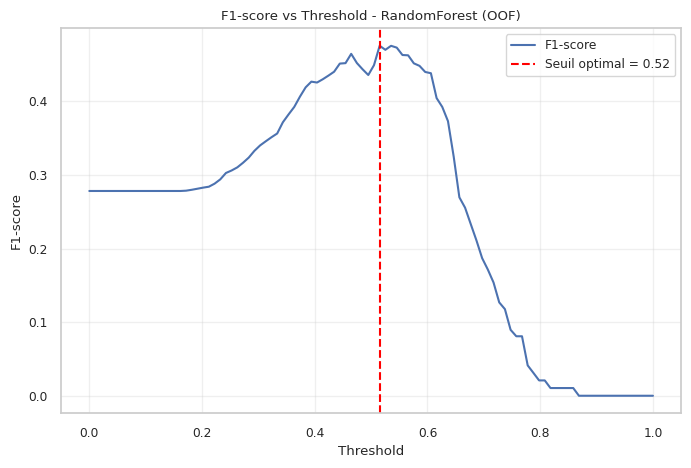

F1 max : 0.475 au seuil 0.515
ROC-AUC test : 0.752

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       247
           1       0.36      0.49      0.41        47

    accuracy                           0.78       294
   macro avg       0.63      0.66      0.64       294
weighted avg       0.81      0.78      0.79       294



,Prédit Non départ,Prédit Départ
Réel Non départ,206,41
Réel Départ,24,23


Validation croisée K-Fold (5 folds) :
ROC-AUC moyen ± std : 0.784 ± 0.037
F1 moyen ± std : 0.535 ± 0.054


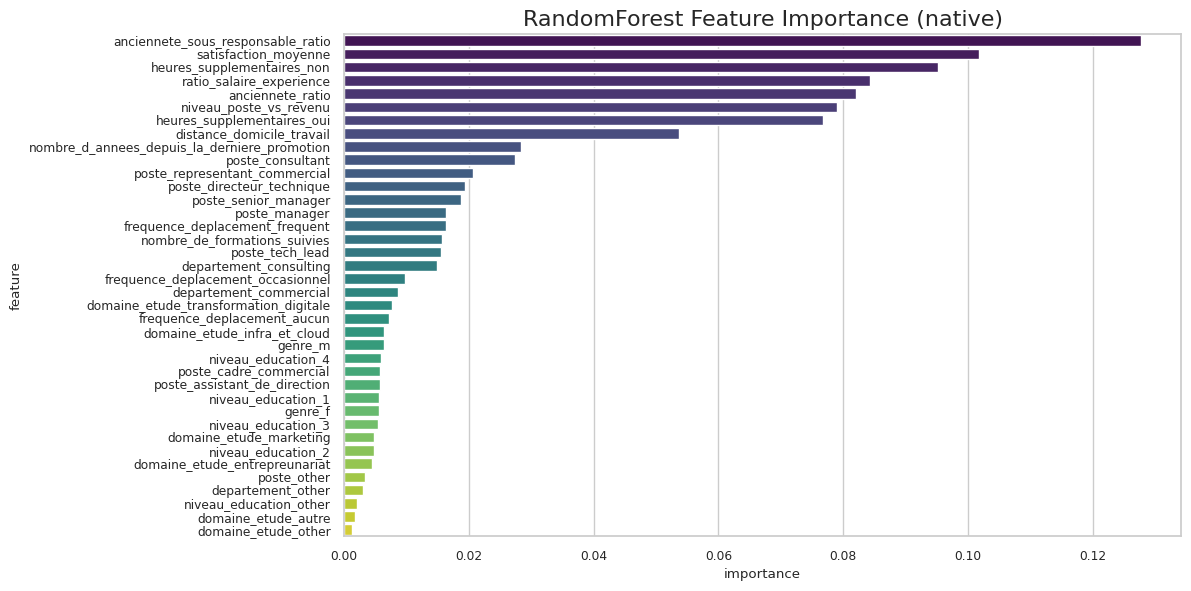


=== Feature Importance globale (Native RandomForest) ===


,feature,importance
3,anciennete_sous_responsable_ratio,0.127722
0,satisfaction_moyenne,0.101737
28,heures_supplementaires_non,0.095107
1,ratio_salaire_experience,0.084229
2,anciennete_ratio,0.082018
4,niveau_poste_vs_revenu,0.078954
29,heures_supplementaires_oui,0.076694
5,distance_domicile_travail,0.053662
7,nombre_d_annees_depuis_la_derniere_promotion,0.028409
10,poste_consultant,0.027450


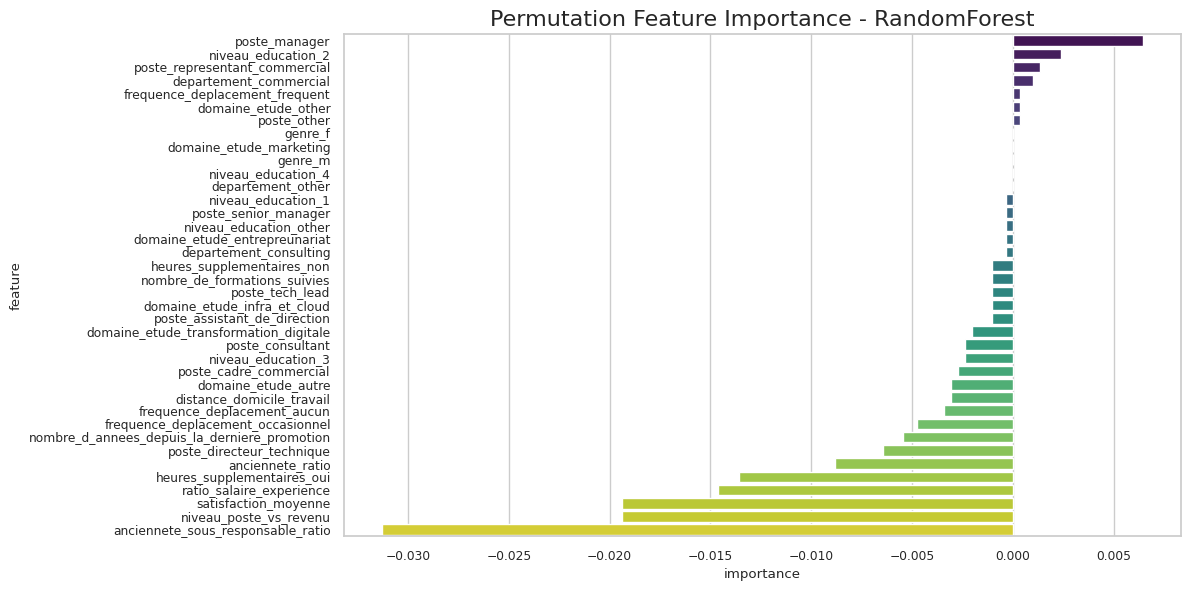


=== Feature Importance globale (Permutation) ===


,feature,importance
12,poste_manager,0.006463
34,niveau_education_2,0.002381
14,poste_representant_commercial,0.001361
17,departement_commercial,0.001020
31,frequence_deplacement_frequent,0.000340
24,domaine_etude_other,0.000340
13,poste_other,0.000340
26,genre_f,0.000000
23,domaine_etude_marketing,0.000000
27,genre_m,0.000000


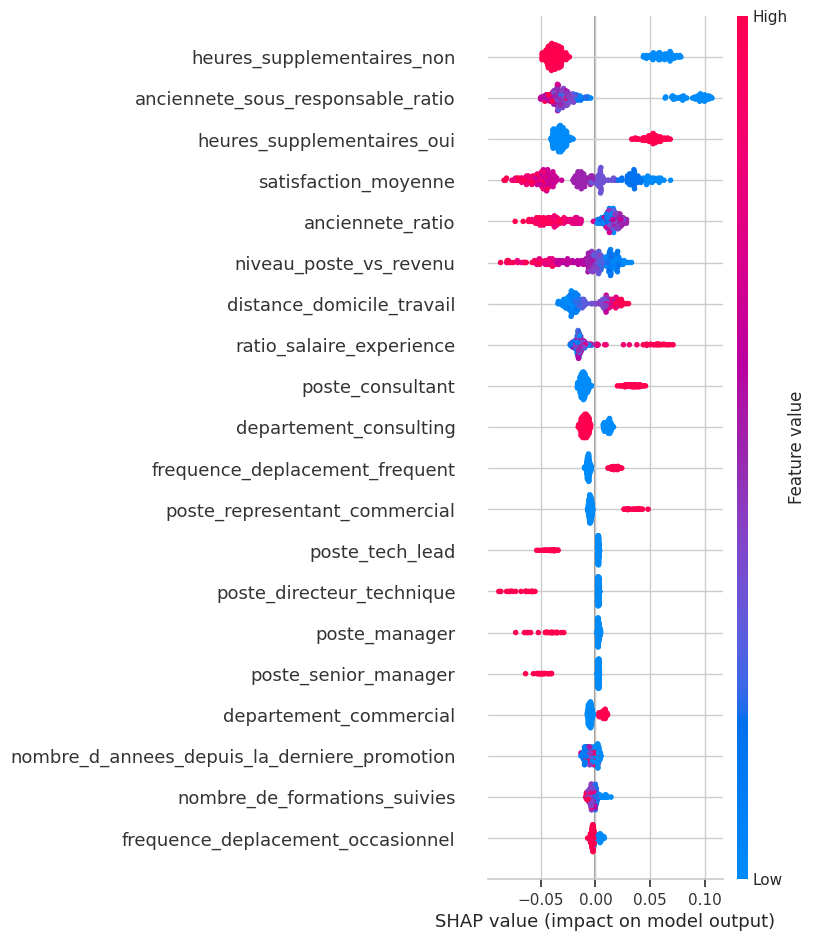

                                         feature  mean_abs_shap
28                    heures_supplementaires_non       0.043891
3              anciennete_sous_responsable_ratio       0.042776
29                    heures_supplementaires_oui       0.037399
0                           satisfaction_moyenne       0.034156
2                               anciennete_ratio       0.025096
4                         niveau_poste_vs_revenu       0.019306
5                      distance_domicile_travail       0.017918
1                       ratio_salaire_experience       0.017908
10                              poste_consultant       0.014144
18                        departement_consulting       0.010178
31                frequence_deplacement_frequent       0.008456
14                 poste_representant_commercial       0.007058
16                               poste_tech_lead       0.006925
11                     poste_directeur_technique       0.006537
12                                 poste

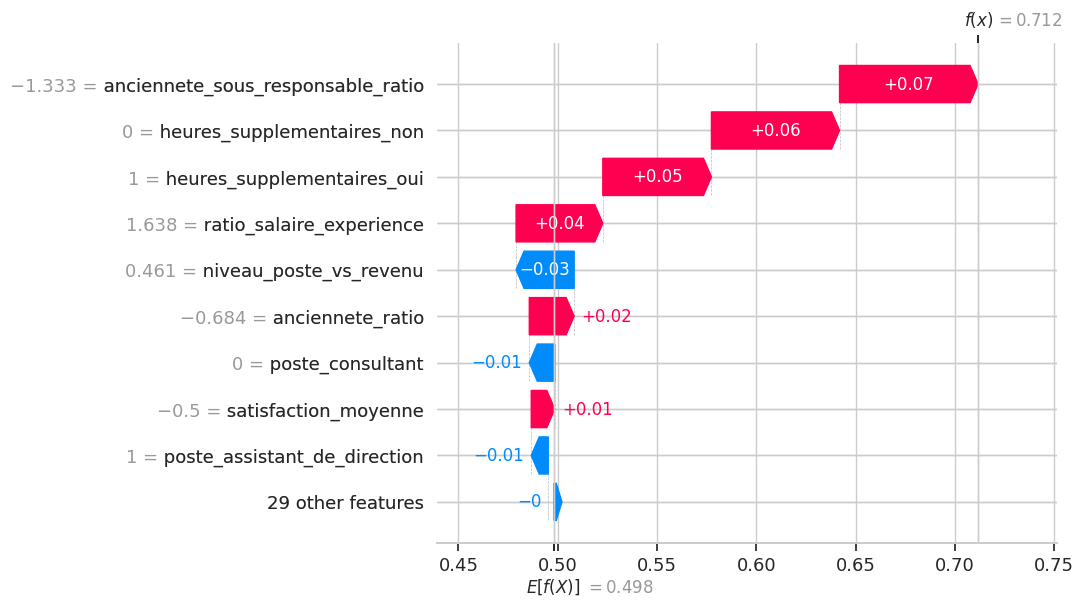

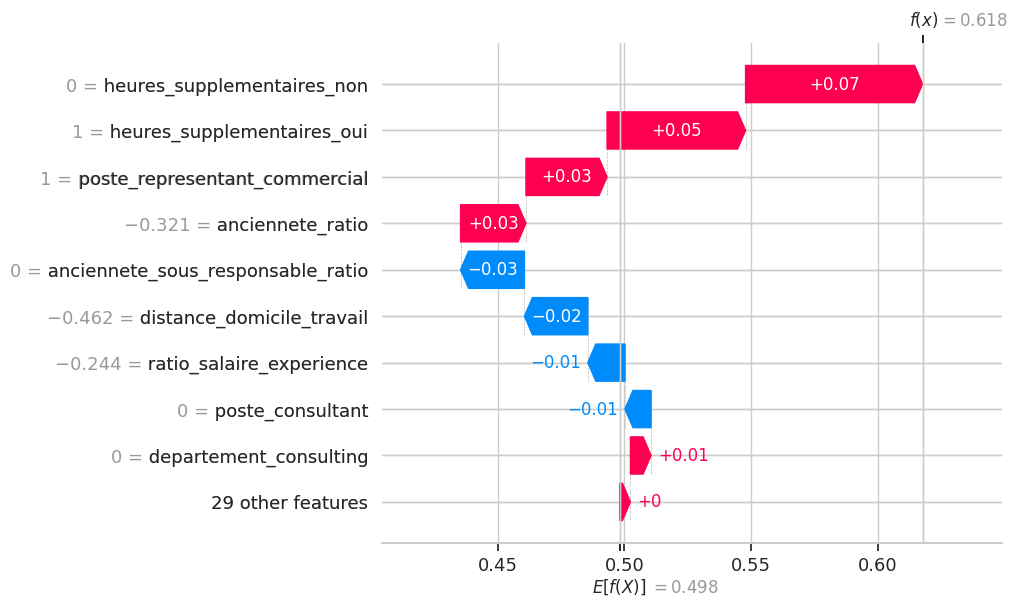

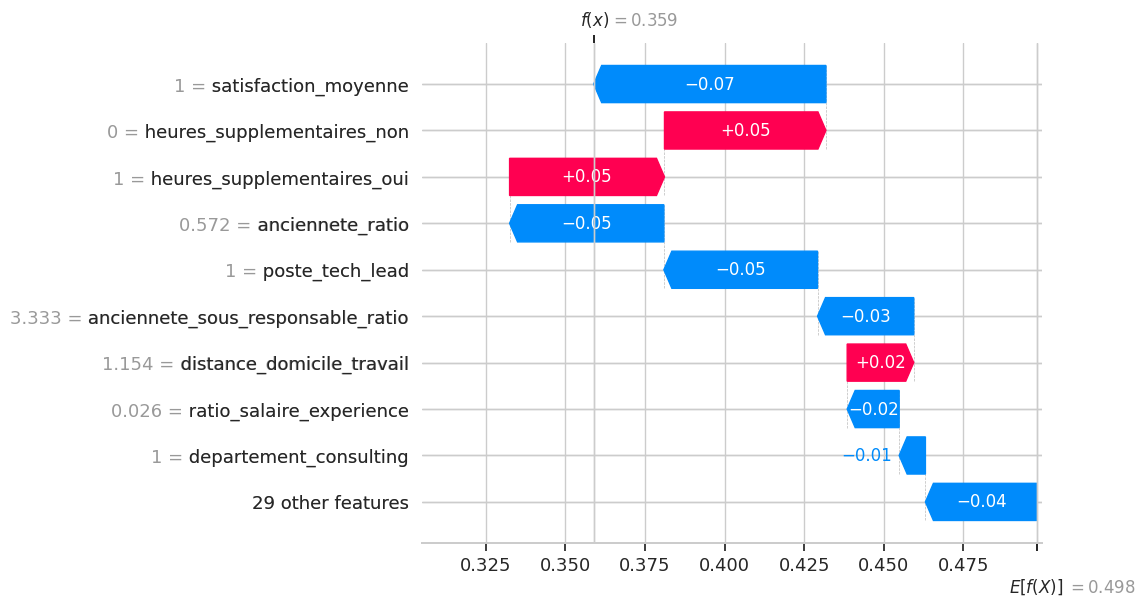

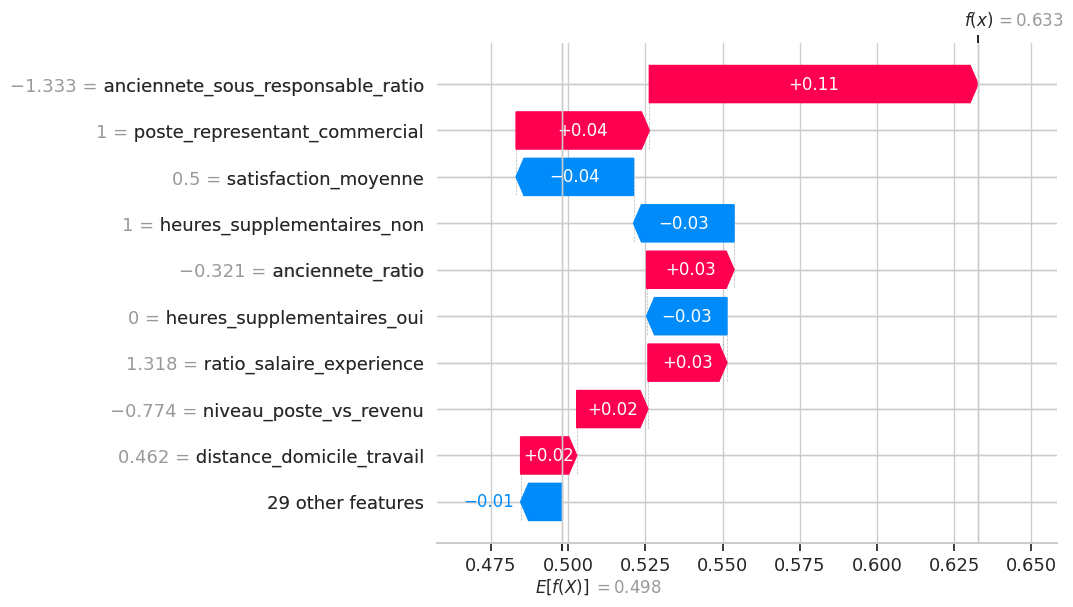

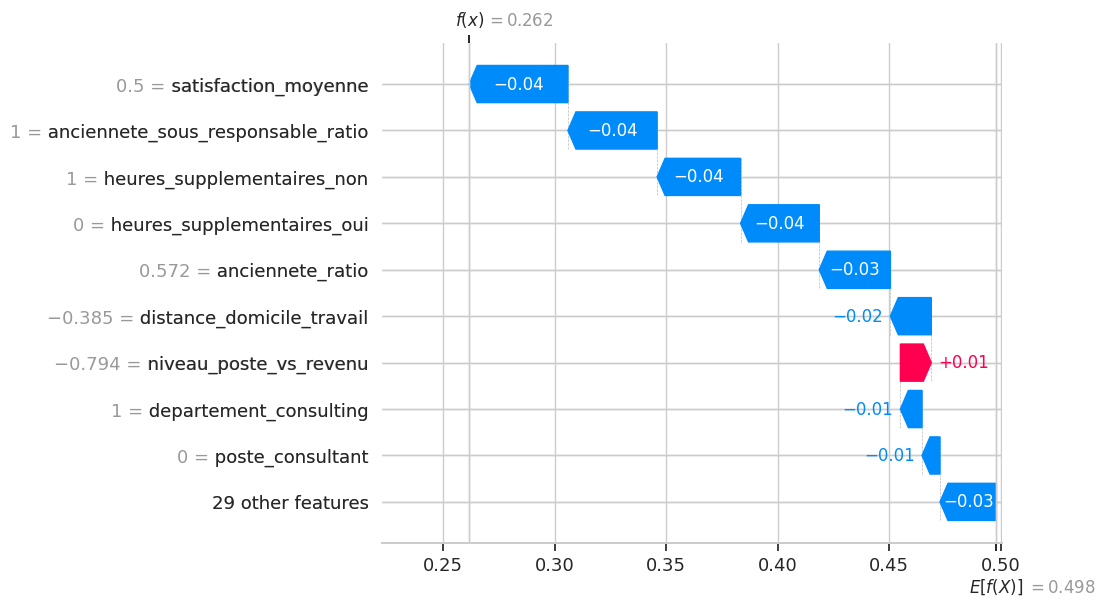

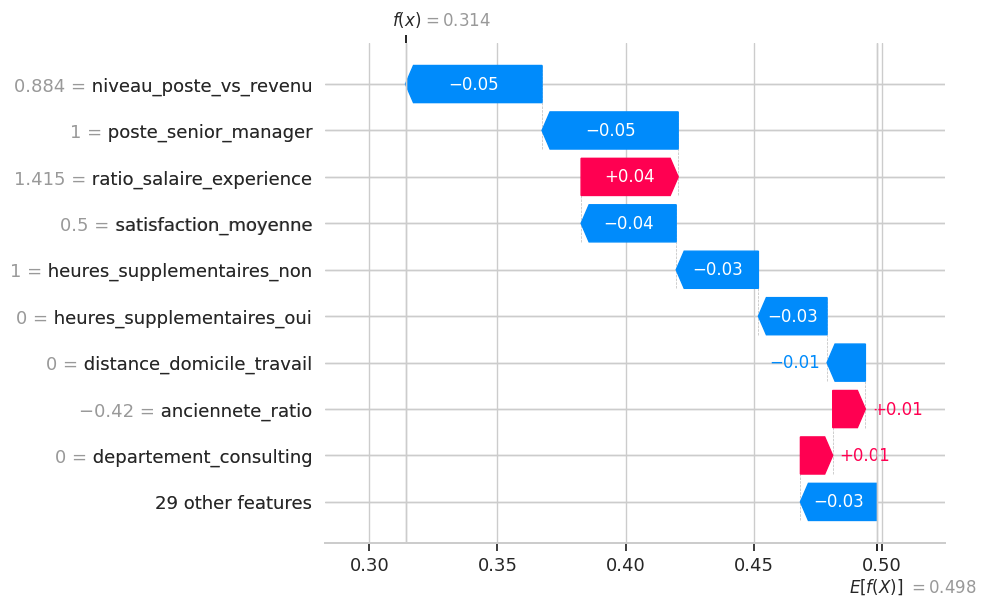


=== Feature Importance locale (Waterfall) pour les échantillons choisis ===

--- Échantillon 4 ---


,feature,shap_value
3,anciennete_sous_responsable_ratio,0.069769
28,heures_supplementaires_non,0.064526
29,heures_supplementaires_oui,0.054719
1,ratio_salaire_experience,0.043687
4,niveau_poste_vs_revenu,-0.029256
2,anciennete_ratio,0.022594
10,poste_consultant,-0.012852
0,satisfaction_moyenne,0.011876
8,poste_assistant_de_direction,-0.008573
6,nombre_de_formations_suivies,0.008513



--- Échantillon 20 ---


,feature,shap_value
28,heures_supplementaires_non,0.069802
29,heures_supplementaires_oui,0.054634
14,poste_representant_commercial,0.031978
2,anciennete_ratio,0.025781
3,anciennete_sous_responsable_ratio,-0.025195
5,distance_domicile_travail,-0.024996
1,ratio_salaire_experience,-0.014645
10,poste_consultant,-0.010293
18,departement_consulting,0.008145
17,departement_commercial,0.007549



--- Échantillon 21 ---


...


--- Échantillon 1 ---


,feature,shap_value
0,satisfaction_moyenne,-0.044280
3,anciennete_sous_responsable_ratio,-0.040012
28,heures_supplementaires_non,-0.037435
29,heures_supplementaires_oui,-0.035295
2,anciennete_ratio,-0.031881
5,distance_domicile_travail,-0.018381
4,niveau_poste_vs_revenu,0.013872
18,departement_consulting,-0.009717
10,poste_consultant,-0.008054
17,departement_commercial,-0.006596



--- Échantillon 2 ---


,feature,shap_value
4,niveau_poste_vs_revenu,-0.053275
15,poste_senior_manager,-0.053119
1,ratio_salaire_experience,0.037880
0,satisfaction_moyenne,-0.037096
28,heures_supplementaires_non,-0.032075
29,heures_supplementaires_oui,-0.026791
5,distance_domicile_travail,-0.014953
2,anciennete_ratio,0.012752
18,departement_consulting,0.012600
10,poste_consultant,-0.011123


[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time=   0.3s
[CV] END classifier__max_depth=8, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time=   0.3s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=5, classifier__n_estimators=500; total time=   0.5s
[CV] END classifier__max_depth=5, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time=   0.3s
[CV] END classifier__max_depth=5, classifier__max_features=log2, classifier__min_samples_leaf=5, classifier__n_estimators=500; total time=   0.4s
[CV] END classifier__max_depth=8, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__n_estimators=500; total time=   0.5s
[CV] END classifier__max_depth=8, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__n_estimators=30

In [212]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.inspection import permutation_importance
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Préparer les données
bool_features = X_train.select_dtypes(include='bool').columns.tolist()
X_train[bool_features] = X_train[bool_features].astype(int)
X_test[bool_features] = X_test[bool_features].astype(int)

# Pipeline + GridSearchCV
pipeline_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__max_depth': [5, 8],
    'classifier__min_samples_leaf': [2, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print("Meilleurs hyperparamètres :", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

# Calcul du seuil optimal F1 sur Out-of_fold
y_prob_oof = np.zeros(len(y_train))
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    best_rf_model.fit(X_tr, y_tr)
    y_prob_oof[val_idx] = best_rf_model.predict_proba(X_val)[:,1]

# Fonction pour courbe F1 vs Threshold
def plot_f1_vs_threshold(model_name, y_true, y_prob_oof):
    thresholds = np.linspace(0, 1, 100)
    f1_scores = [f1_score(y_true, (y_prob_oof >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    plt.figure(figsize=(8,5))
    plt.plot(thresholds, f1_scores, label="F1-score")
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold - {model_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    print(f"F1 max : {f1_scores[best_idx]:.3f} au seuil {best_threshold:.3f}")
    return best_threshold

best_threshold = plot_f1_vs_threshold("RandomForest (OOF)", y_train, y_prob_oof)

# Test final de prédiction sur ensemble de test avec seuil fixé
y_prob_test = best_rf_model.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print(f"ROC-AUC test : {roc_auc_score(y_test, y_prob_test):.3f}")
print("\nClassification report (Test) :")
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)
display(pd.DataFrame(cm_test, index=["Réel Non départ","Réel Départ"],
                     columns=["Prédit Non départ","Prédit Départ"]))

# Validation croisée K-Fold pour robustesse
roc_auc_scores = []
f1_scores_cv = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_rf_model.fit(X_tr, y_tr)
    y_val_prob = best_rf_model.predict_proba(X_val)[:,1]

    roc_auc_scores.append(roc_auc_score(y_val, y_val_prob))

    # Seuil F1 optimal sur ce fold
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)
    f1_fold = 2*(precision*recall)/(precision+recall+1e-6)
    best_thresh_fold = thresholds[np.argmax(f1_fold)]
    y_val_pred = (y_val_prob >= best_thresh_fold).astype(int)
    f1_scores_cv.append(f1_score(y_val, y_val_pred))

print(f"Validation croisée K-Fold (5 folds) :")
print(f"ROC-AUC moyen ± std : {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"F1 moyen ± std : {np.mean(f1_scores_cv):.3f} ± {np.std(f1_scores_cv):.3f}")

# Préparer les données transformées et classifier
X_test_transformed = best_rf_model.named_steps['preprocessor'].transform(X_test)
rf_classifier = best_rf_model.named_steps['classifier']
feature_names_transformed = numeric_features + categorical_features

# Feature importance globale avec Native RandomForest
rf_importances = pd.DataFrame({
    'feature': feature_names_transformed,
    'importance': rf_classifier.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=rf_importances, palette='viridis', hue='feature')
plt.title("RandomForest Feature Importance (native)", fontsize=16)
plt.tight_layout()
plt.show()

# Affichage numérique
print("\n=== Feature Importance globale (Native RandomForest) ===")
display(rf_importances)

# Feature importance globale avec Permutation Importance
perm_importance = permutation_importance(
    rf_classifier, X_test_transformed, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': feature_names_transformed,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=perm_df, palette='viridis', hue='feature')
plt.title("Permutation Feature Importance - RandomForest", fontsize=16)
plt.tight_layout()
plt.show()

# Affichage numérique
print("\n=== Feature Importance globale (Permutation) ===")
display(perm_df)

# Feature importance globale avec SHAP summary_plot
# SHAP pour RandomForest binaire
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer(X_test_transformed)

# Déterminer si c'est une classification binaire
if shap_values.values.ndim == 3 and shap_values.values.shape[2] == 2:
    # Classification binaire : on prend uniquement la classe positive (1)
    if shap_values.base_values.ndim == 2:
        # base_values shape = (n_samples, n_classes)
        base_value = shap_values.base_values[:, 1].mean()
    else:
        # base_values shape = (n_classes,)
        base_value = shap_values.base_values[1]

    shap_values_class1 = shap.Explanation(
        values=shap_values.values[:, :, 1],    # n_samples x n_features
        base_values=base_value,                # scalaire
        data=shap_values.data,
        feature_names=feature_names_transformed
    )
else:
    shap_values_class1 = shap_values

# Beeswarm global
shap.summary_plot(
    shap_values_class1,
    features=X_test_transformed,
    feature_names=feature_names_transformed
)

# Affichage numérique feature importance globale avec SHAP
shap_importance = pd.DataFrame({
    'feature': feature_names_transformed,
    'mean_abs_shap': np.abs(shap_values_class1.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

print(shap_importance)

# Feature importance locale avec Shap Waterfall plots pour 3 exemples positifs et 3 négatifs
indices_pos = np.where(y_test == 1)[0][:3]
indices_neg = np.where(y_test == 0)[0][:3]
indices = np.concatenate([indices_pos, indices_neg])

local_shap_values_list = []  # vider la liste pour éviter la duplication

for i in indices:
    expl = shap.Explanation(
        values=shap_values_class1.values[i],      # vecteur SHAP pour l'échantillon
        base_values=shap_values_class1.base_values,  # scalaire, pas besoin d'indexer
        data=shap_values_class1.data[i],          # valeurs features de l'échantillon
        feature_names=feature_names_transformed
    )

    # Affichage unique du Waterfall plot
    shap.waterfall_plot(expl)

    # Stockage des valeurs locales
    df_local = pd.DataFrame({
        'feature': feature_names_transformed,
        'shap_value': expl.values
    }).sort_values(by='shap_value', key=np.abs, ascending=False)
    local_shap_values_list.append((i, df_local))


# Affichage numérique des valeurs locales (waterfall)
print("\n=== Feature Importance locale (Waterfall) pour les échantillons choisis ===")
for idx, df_local in local_shap_values_list:
    print(f"\n--- Échantillon {idx} ---")
    display(df_local)

#### observations

**Comparaison des résultats de performance du modèle Random Forest retenu et optimisé avec ce même modèle à l'étape 4**

| Métrique               | Avant fine-tuning        | Après fine-tuning (GridSearch)        | Observation                                                                                  |
|------------------------|------------------------|--------------------------------------|---------------------------------------------------------------------------------------------|
| Accuracy               | 0.72 – 0.722           | 0.72                                 | Stable, pas de changement majeur                                                            |
| Macro F1               | 0.44 – 0.45            | **0.64**                                 | **Amélioration significative : régularisation et seuil optimisé ont aidé à mieux équilibrer la performance sur les classes minoritaires** |
| ROC-AUC                | 0.60 – 0.57            | 0.730 (test) / 0.765 ± 0.051 (CV)   | Amélioration notable : le modèle est mieux calibré et plus robuste en validation croisée    |
| F1-score classe 1      | 0.44 – 0.45            | 0.46                                 | Légère amélioration sur la classe minoritaire, surtout grâce au seuil F1 optimisé           |

- Points clés de l’amélioration
  - Hyperparamètres optimisés
    - max_depth=5, min_samples_leaf=2 → réduit l’overfitting sur la classe majoritaire.
    - max_features='log2' → augmente la diversité des arbres et stabilise les prédictions.
    - Seuil F1 optimal (0.496)
    - Permet de mieux équilibrer precision / recall pour la classe minoritaire.
  - Validation croisée robuste
    - ROC-AUC moyen ± std = 0.765 ± 0.051 → indique que le modèle est plus stable d’un fold à l’autre, moins sensible aux variations aléatoires dans les splits.

- Interprétation pratique
  - Même si l’accuracy globale reste stable (~0.72), les métriques sensibles aux déséquilibres (macro-F1, ROC-AUC) montrent une vraie amélioration du traitement de la classe minoritaire.
  - Cela correspond exactement à ce qu’on recherche quand on fait un undersampling + fine-tuning + seuil optimisé : stabiliser le modèle et mieux capturer les départs (classe 1).

- On peut conclure que le fine-tuning et GridSearch ont amélioré la performance globale du RandomForest, surtout sur la classe minoritaire, avec un modèle plus régulier et moins sujet à l’overfitting.

- L’accuracy reste similaire, mais les métriques plus critiques pour un dataset déséquilibré (ROC-AUC, F1-macro) progressent nettement.




**Analyse des résultats de feature importance global avec les 3 méthodes random forest native, permutation importance et SHAP summary_plot**

RandomForest native (Gini importance)

- Les features les plus importantes sont :
  - anciennete_sous_responsable_ratio (0.101)
  - satisfaction_moyenne (0.100)
  - ratio_salaire_experience (0.092)
  - niveau_poste_vs_revenu (0.080)
  - anciennete_ratio (0.074)

- Ce que l'on peut apprendre : 
  - Les variables liées à l’ancienneté et aux ratios de salaire / expérience dominent la prédiction des départs.
  - Les indicateurs de poste (niveau_poste_vs_revenu, poste_consultant) jouent un rôle notable.
  - Les variables catégorielles comme le genre ou le domaine d’étude ont très peu d’influence.

- Limites :
  - Cette méthode mesure la réduction de l’impureté dans les arbres, ce qui peut surévaluer les features continues et corrélées, et sous-estimer les features moins fréquentes ou catégorielles.

Permutation Importance

- Les features les plus importantes sont :
  - ratio_salaire_experience (0.0228)
  - anciennete_ratio (0.0214)
  - anciennete_sous_responsable_ratio (0.0194)
  - niveau_poste_vs_revenu (0.0163)
  - satisfaction_moyenne (0.0159)

- Ce que l'on peut apprendre : 
  - On retrouve globalement les mêmes features clés, mais avec un ordre légèrement différent : ratio_salaire_experience devient la plus influente.
  - Cette méthode est plus robuste aux biais des features continues et corrélées, car elle mesure l’impact réel sur les prédictions en permutant les valeurs.
  - On voit clairement que certaines features ont quasi pas d’impact (genre_m, poste_directeur_technique, etc.), ce qui confirme que certaines colonnes sont peu utiles pour prédire les départs.

SHAP Summary (mean absolute SHAP value)

- Les features les plus importantes sont :
  - satisfaction_moyenne (0.0356)
  - anciennete_sous_responsable_ratio (0.0349)
  - heures_supplementaires_oui (0.0334)
  - heures_supplementaires_non (0.0320)
  - poste_consultant (0.0295)

- Ce que l'on peut apprendre : 
  - SHAP mesure l’impact moyen de chaque feature sur la prédiction individuelle, donc elle capture des effets que les autres méthodes peuvent sous-estimer.
  - On remarque que les heures supplémentaires deviennent un facteur clé ici, ce qui n’était pas évident dans les deux autres méthodes.
  - SHAP nous montre aussi que certaines variables ont des impacts positifs ou négatifs clairs sur la prédiction, et pas seulement leur “importance globale”.

Comparaison de l'influence des features en mode global (un rang de 1 indique une feature la plus influente sur la target)

| Feature                             | RandomForest native | Permutation Importance | SHAP summary | Interprétation                                                                 |
|-------------------------------------|-------------------|----------------------|-------------|-------------------------------------------------------------------------------|
| anciennete_sous_responsable_ratio   | 1                 | 3                    | 2           | Très influente, liée au temps sous supervision directe, robuste               |
| satisfaction_moyenne                | 2                 | 5                    | 1           | Toujours importante, SHAP confirme son impact sur la prédiction individuelle |
| ratio_salaire_experience            | 3                 | 1                    | 8           | Clé dans les performances globales, moins perceptible individuellement selon SHAP |
| niveau_poste_vs_revenu              | 4                 | 4                    | 9           | Important pour la prédiction globale                                         |
| anciennete_ratio                     | 5                 | 2                    | 7           | Ancienneté générale importante, toutes méthodes confirment                     |
| heures_supplementaires (oui/non)    | 8–9               | 7–8                  | 3–4         | SHAP révèle un impact individuel plus important que les importances natives   |
| poste_consultant                     | 10                | 10                   | 5           | Rôle de poste pertinent, stable selon méthodes                                |

- Points communs :
  - Les features liées à ancienneté, satisfaction, et salaire vs expérience dominent.
- Différences :
  - SHAP met en lumière des variables avec un impact fort mais moins global, comme les heures supplémentaires, qui sont moins visibles avec les autres méthodes.
  - La permutation importance est plus fiable que le native RF pour éviter le biais des features continues.
  - Pour la compréhension globale du modèle, les trois méthodes convergent sur l’ancienneté, la satisfaction et le salaire/expérience.
  - Pour la prédiction individuelle et la compréhension fine, SHAP est supérieur, car il montre des effets non capturés par les méthodes globales.
  - Certaines features catégorielles ou peu fréquentes ont quasi pas d’influence sur les départs, ce qui peut orienter un nettoyage ou réduction de dimensions si nécessaire.


**Analyse des résultats de feature importance locale sur certains échantillons**

Dans un graphique Waterfall SHAP pour un échantillon :
- En ordonnée (y) on trouve les features de l’échantillon (un salarié), classées par contribution à la prédiction.
- En abscisse (x) on trouve la valeur de la prédiction pour cet individu représentée par f(x) (probabilité de départ).
- En abscisse (x), on trouve aussi l'espérance E(f(x)) de la prédicition qui est la valeur moyenne de la prédiction sur tout l’échantillon (la prédiction moyenne du modèle avant d’ajouter les effets des features) pour l'échantillon considéré.
- Le modèle commence en abscisse à E(f(x)) et chaque feature déplace la prédiction vers la droite (valeur positive) ou vers la gauche (valeur négative) selon qu’elle augmente ou diminue la probabilité de départ.
- Les barres colorées indiquent l’effet individuel de la feature :
- Droite (positive rouge) cette feature pousse la prédiction vers le départ.
- Gauche (négative bleu) cette feature pousse la prédiction vers le non-départ.
- Donc la somme des SHAP values + l'espérance de f(x) donne la probabilité de départ pour l’échantillon.

Exemple d'analyse de l'échantillon 21:
- Feature la plus impactante négative : satisfaction_moyenne (-0.079) donc diminue fortement la probabilité de départ.
- Features positives : heures_supplementaires_oui et heures_supplementaires_non soit +0.04 chacune
- mais la feature poste_tech_lead donne -0.036 ce qui montre ici qu'un rôle technique stabilise un maintien dans l'entreprise
- Interprétation : Pour cet employé, la satisfaction joue un rôle dominant, et le modèle prédit un départ plus faible (SHAP négatif), malgré les heures supplémentaires.

Ce que l'on peut apprendre sur les feature importances locales:
- Les features “forces locales” pour un employé sont très variables, **même si certaines features apparaissent systématiquement comme influentes** :
  - **anciennete_sous_responsable_ratio**,
  - **satisfaction_moyenne**,
  - **ratio_salaire_experience**,
  - **heures_supplementaires_oui/non**.


## Actions d'amélioration pour aller plus loin

- Refaire l'étape 5 en ne pratiquant que l'undersampling (et enlevant la gestion des poids des classes) pour voir si la précision s'améliore par rapport à une gestion de déséquilibre de classes par la combinaison de la gestion des poids des classes et l'undersampling
- Ajuster le seuil de prédiction si on veut vraiment maximiser la performance sur la classe minoritaire après être intervenu sur le poids des classes  puis l'undersampling pour l'entraînement afin de gérer le déséquilibre de classes.
- Donc en dernière intention, optimiser le seuil sur F1 ou le recall.